
# RonaAir — Computer Vision Final Colab Pipeline

Notebook ini mempertahankan arsitektur dan scientific guardrails dari pipeline Codex sebelumnya, tetapi dibuat **self-contained** agar dapat dijalankan sebagai satu file `.ipynb` di Google Colab tanpa bergantung pada folder `03_src` atau modul `.py` eksternal.

**Pipeline:**

`Google Drive ZIP → safe download → safe extraction → inventory → label audit → image quality → RonaCard/color calibration → water ROI → OpenCV color/texture → MobileNetV3-Small → split/evaluation → optional supervised fine-tuning → TFLite/export → integrity check`

**Batasan ilmiah:** foto air bukan pengukuran kimia langsung; warna bukan bukti cyanobacteria/cyanotoxin; empat status `NORMAL/WASPADA/SIAGA/DARURAT` tidak dilatih dari foto kecuali tersedia label evidence-based yang telah diaudit.

> **Penting:** dua dataset Google Drive dimasukkan sebagai URL pada Cell 3. Notebook akan menangani keduanya sebagai dataset terpisah terlebih dahulu, bukan langsung menggabungkannya secara buta.

---

**Versi ini adalah EXTEND / ADD-ON dari notebook baseline, bukan notebook baru.**
Struktur section, urutan pipeline, nama fungsi/variabel, model utama (MobileNetV3-Small),
Grad-CAM, dan guardrail ilmiah dipertahankan. Yang ditambahkan:

* fitur warna eksplisit **RGB, normalized RGB (r,g,b), HSV, CIELAB (L\*, a\*, b\*)**, percentile dan histogram ROI air;
* **RonaCard color calibration** (sudah ada di baseline) dipertahankan, ROI RonaCard di-*mask out* dari fitur air;
* **Visual Score 0–100** deterministik dengan formula yang dicetak di notebook;
* metrik klasifikasi lengkap: **Accuracy, Precision, Recall, Macro F1, Weighted F1, Confusion Matrix, Classification Report**;
* **Silhouette Score** sebagai metrik *separasi fitur/embedding* — bukan accuracy;
* **data leakage check**, audit **class imbalance** + class weight, **ablation** A/B/C/D;
* **Grad-CAM** + pengukuran fokus heatmap di dalam ROI air;
* **INT8 TFLite** dan laporan **Deployment Readiness** (input size, model size, inference time, offline);
* laporan akhir 5 section dan ringkasan perubahan cell-by-cell di akhir notebook.

Semua angka pada notebook ini berasal dari eksekusi aktual. Metrik yang tidak dapat dihitung
dilaporkan sebagai **"Not available"** beserta alasannya — tidak ada hasil yang dikarang.

In [2]:

# CELL 2 — Environment, dependencies, configuration, and self-contained core functions

import os, sys, json, zipfile, hashlib, random, platform, subprocess, warnings, re, math, time
from pathlib import Path
from collections import Counter

# Install only lightweight packages that may be missing in a fresh Colab runtime.
# TensorFlow is normally preinstalled in Colab; do not force-reinstall it.
subprocess.run([sys.executable, "-m", "pip", "-q", "install", "gdown", "scikit-learn", "pillow", "opencv-python-headless"], check=True)

import numpy as np
import pandas as pd
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from IPython.display import display

import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report, silhouette_score
from sklearn.cluster import KMeans

warnings.filterwarnings("ignore", category=FutureWarning)

# -----------------------------
# Global reproducibility
# -----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# -----------------------------
# Project paths
# -----------------------------
PROJECT_ROOT = Path("/content/RonaAir_CV")
DATA_DIR = PROJECT_ROOT / "01_data"
EXTRACT_DIR = DATA_DIR / "extracted"
OUTPUT_DIR = PROJECT_ROOT / "05_outputs"
MODEL_DIR = PROJECT_ROOT / "04_models"
CONFIG_DIR = PROJECT_ROOT / "06_configs"
for p in [PROJECT_ROOT, DATA_DIR, EXTRACT_DIR, OUTPUT_DIR, MODEL_DIR, CONFIG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# -----------------------------
# Runtime info
# -----------------------------
GPU_AVAILABLE = len(tf.config.list_physical_devices("GPU")) > 0
print("Python:", platform.python_version())
print("TensorFlow:", tf.__version__)
print("OpenCV:", cv2.__version__)
print("GPU_AVAILABLE:", GPU_AVAILABLE)
if GPU_AVAILABLE:
    print("GPU:", tf.config.list_physical_devices("GPU"))

# -----------------------------
# Config
# -----------------------------
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32 if GPU_AVAILABLE else 16
EMBEDDING_BATCH_SIZE = 64 if GPU_AVAILABLE else 16
NUM_PARALLEL_CALLS = tf.data.AUTOTUNE

# Quality thresholds are image-QC thresholds, NOT biological thresholds.
QUALITY = {
    "min_width": 96,
    "min_height": 96,
    "blur_laplacian_min": 12.0,
    "mean_gray_min": 20.0,
    "mean_gray_max": 245.0,
    "bright_ratio_max": 0.70,
    "dark_ratio_max": 0.70,
}

# MobileNet configuration
MOBILENET_WEIGHTS = "imagenet"
MOBILENET_DROPOUT = 0.25

# -----------------------------
# Helper utilities
# -----------------------------
def sha256_file(path, chunk_size=1024*1024):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        while True:
            b = f.read(chunk_size)
            if not b:
                break
            h.update(b)
    return h.hexdigest()


def safe_extract_zip(zip_path, extract_to):
    zip_path = Path(zip_path)
    extract_to = Path(extract_to)
    extract_to.mkdir(parents=True, exist_ok=True)
    root = extract_to.resolve()
    members = []
    with zipfile.ZipFile(zip_path, "r") as z:
        for m in z.infolist():
            target = (extract_to / m.filename).resolve()
            if not str(target).startswith(str(root)):
                raise RuntimeError(f"Unsafe ZIP member rejected: {m.filename}")
            members.append(m.filename)
        z.extractall(extract_to)
    return {"zip": str(zip_path), "extract_to": str(extract_to), "members": len(members)}


def image_paths(root):
    root = Path(root)
    if not root.exists():
        return []
    return [p for p in root.rglob("*") if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS]


def candidate_metadata_files(root):
    exts = {".csv", ".json", ".xlsx", ".xls", ".txt"}
    return [p for p in Path(root).rglob("*") if p.is_file() and p.suffix.lower() in exts]


def infer_candidate_label(path, dataset_root):
    """Infer only a CANDIDATE label from the immediate parent folder.
    It is NOT considered validated ground truth automatically.
    """
    rel = Path(path).relative_to(Path(dataset_root))
    parts = rel.parts
    if len(parts) >= 2:
        return parts[-2]
    return ""


def build_dataset_inventory(dataset_specs):
    rows=[]
    for spec in dataset_specs:
        root = Path(spec["root"])
        source_name = spec["name"]
        for p in image_paths(root):
            rec={"image_path": str(p), "source_dataset": source_name,
                 "relative_path": str(p.relative_to(root)),
                 "file_name": p.name, "file_ext": p.suffix.lower(),
                 "file_size_bytes": p.stat().st_size,
                 "candidate_label": infer_candidate_label(p, root)}
            try:
                img = cv2.imread(str(p), cv2.IMREAD_COLOR)
                if img is None:
                    rec.update({"corrupted": True, "width": np.nan, "height": np.nan, "channels": 0})
                else:
                    h,w,c = img.shape
                    rec.update({"corrupted": False, "width": int(w), "height": int(h), "channels": int(c)})
            except Exception as e:
                rec.update({"corrupted": True, "width": np.nan, "height": np.nan, "channels": 0})
            rows.append(rec)
    df=pd.DataFrame(rows)
    if df.empty:
        return df
    # Hash only readable files; this is intentionally sequential to avoid RAM spikes.
    hashes=[]
    for p, corrupted in zip(df["image_path"], df["corrupted"]):
        hashes.append(sha256_file(p) if not corrupted else "")
    df["sha256"] = hashes
    df["duplicate_sha256"] = df["sha256"].duplicated(keep=False) & df["sha256"].ne("")
    return df


def summarize_inventory(df):
    if df.empty:
        return {"n_images":0}
    return {
        "n_images": int(len(df)),
        "corrupted": int(df["corrupted"].sum()),
        "duplicate_sha256_rows": int(df["duplicate_sha256"].sum()),
        "datasets": int(df["source_dataset"].nunique()),
        "candidate_labels": int(df["candidate_label"].nunique()),
        "min_width": float(df["width"].min()),
        "max_width": float(df["width"].max()),
        "min_height": float(df["height"].min()),
        "max_height": float(df["height"].max()),
    }


def audit_quality_for_paths(paths, out_csv):
    rows=[]
    for p in paths:
        rec={"image_path": p}
        try:
            img=cv2.imread(p, cv2.IMREAD_COLOR)
            if img is None:
                rec.update({"quality_status":"REJECT_CORRUPTED"})
            else:
                gray=cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                mean_gray=float(gray.mean())
                blur=float(cv2.Laplacian(gray, cv2.CV_64F).var())
                bright=float((gray>=245).mean())
                dark=float((gray<=20).mean())
                h,w=gray.shape[:2]
                reasons=[]
                if w<QUALITY["min_width"] or h<QUALITY["min_height"]: reasons.append("low_resolution")
                if blur<QUALITY["blur_laplacian_min"]: reasons.append("blur")
                if mean_gray<QUALITY["mean_gray_min"]: reasons.append("dark")
                if mean_gray>QUALITY["mean_gray_max"]: reasons.append("bright")
                if bright>QUALITY["bright_ratio_max"]: reasons.append("overexposure")
                if dark>QUALITY["dark_ratio_max"]: reasons.append("underexposure")
                rec.update({"width":w,"height":h,"mean_gray":mean_gray,"laplacian_var":blur,
                            "bright_ratio":bright,"dark_ratio":dark,
                            "quality_status":"USABLE" if not reasons else "REVIEW",
                            "quality_reason":";".join(reasons)})
        except Exception as e:
            rec.update({"quality_status":"REJECT_ERROR","quality_reason":repr(e)})
        rows.append(rec)
    out=pd.DataFrame(rows)
    out.to_csv(out_csv,index=False)
    return out

# -----------------------------
# Conservative RonaCard heuristics
# -----------------------------
def detect_ronacard(image_bgr):
    """Conservative heuristic: finds a large neutral, rectangular region.
    Returns detected=False when confidence is insufficient.
    This is intentionally a fallback, not a claim of perfect RonaCard detection.
    """
    if image_bgr is None or image_bgr.size==0:
        return {"detected":False}
    h,w=image_bgr.shape[:2]
    hsv=cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
    # Low saturation + mid/high value; exclude tiny components.
    mask=((hsv[:,:,1] < 35) & (hsv[:,:,2] > 70) & (hsv[:,:,2] < 245)).astype(np.uint8)*255
    kernel=np.ones((5,5),np.uint8)
    mask=cv2.morphologyEx(mask,cv2.MORPH_CLOSE,kernel)
    mask=cv2.morphologyEx(mask,cv2.MORPH_OPEN,kernel)
    contours,_=cv2.findContours(mask,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
    best=None; best_score=0
    for c in contours:
        x,y,cw,ch=cv2.boundingRect(c)
        area=cw*ch
        if cw<0.08*w or ch<0.05*h:
            continue
        aspect=cw/max(ch,1)
        if aspect<0.5 or aspect>4.0:
            continue
        frac=area/(w*h)
        score=frac*(1-abs(aspect-1.8)/3)
        if score>best_score:
            best_score=score; best=(x,y,cw,ch)
    if best is None or best_score<0.002:
        return {"detected":False, "score":float(best_score)}
    x,y,cw,ch=best
    return {"detected":True,"bbox":[int(x),int(y),int(cw),int(ch)],"score":float(best_score)}


def calibrate_with_ronacard(image_bgr, detection):
    if image_bgr is None:
        return image_bgr, {"calibrated":False,"reason":"empty_image"}
    if not detection.get("detected",False):
        return image_bgr.copy(), {"calibrated":False,"reason":"RonaCard not detected"}
    x,y,w,h=detection["bbox"]
    patch=image_bgr[y:y+h,x:x+w]
    if patch.size==0:
        return image_bgr.copy(), {"calibrated":False,"reason":"empty_patch"}
    # Use robust median RGB/BGR luminance scaling based on a neutral reference patch.
    med=np.median(patch.reshape(-1,3),axis=0).astype(np.float32)
    target=float(np.mean(med))
    scales=target/np.maximum(med,1.0)
    calibrated=np.clip(image_bgr.astype(np.float32)*scales.reshape(1,1,3),0,255).astype(np.uint8)
    return calibrated, {"calibrated":True,"bbox":[x,y,w,h],"channel_medians":med.tolist(),"scales":scales.tolist()}


def extract_water_roi(image_bgr,detection):
    h,w=image_bgr.shape[:2]
    mask=np.ones((h,w),dtype=np.uint8)*255
    # Conservative central crop to reduce sky/edge contamination.
    y0=int(0.08*h); y1=int(0.92*h); x0=int(0.05*w); x1=int(0.95*w)
    mask[:y0]=0; mask[y1:]=0; mask[:,:x0]=0; mask[:,x1:]=0
    if detection.get("detected",False):
        x,y,cw,ch=detection["bbox"]
        pad=8
        xa=max(0,x-pad); ya=max(0,y-pad); xb=min(w,x+cw+pad); yb=min(h,y+ch+pad)
        mask[ya:yb,xa:xb]=0
    roi_bgr=image_bgr.copy()
    roi_bgr[mask==0]=0
    return {"roi_mask":mask,"roi_bgr":roi_bgr,"coverage":float((mask>0).mean())}


def roi_pixels(roi_bgr, mask):
    pix=roi_bgr[mask>0]
    if len(pix)==0:
        return np.zeros((1,3),dtype=np.uint8)
    return pix


def extract_visual_features(path, config=None):
    """KEPT from baseline + EXTENDED with explicit RGB / normalized RGB / HSV / CIELAB features.

    All color features are computed ONLY inside the water ROI mask
    (background, hand, container, text and the RonaCard bbox are excluded).
    """
    img=cv2.imread(path,cv2.IMREAD_COLOR)
    if img is None:
        raise ValueError(f"Unreadable image: {path}")
    det=detect_ronacard(img)
    cal,cal_meta=calibrate_with_ronacard(img,det)
    roi=extract_water_roi(cal,det)
    pix=roi_pixels(roi["roi_bgr"],roi["roi_mask"])
    # OpenCV color spaces (computed on the CALIBRATED image, sampled inside ROI only)
    hsv=cv2.cvtColor(cal,cv2.COLOR_BGR2HSV)
    lab=cv2.cvtColor(cal,cv2.COLOR_BGR2LAB)
    gray=cv2.cvtColor(cal,cv2.COLOR_BGR2GRAY)
    hp=hsv[roi["roi_mask"]>0]
    lp=lab[roi["roi_mask"]>0]
    gp=gray[roi["roi_mask"]>0]
    # Texture / edges in ROI
    edge=cv2.Canny(roi["roi_bgr"],50,150)
    edge_roi=edge[roi["roi_mask"]>0]
    gradx=cv2.Sobel(gray,cv2.CV_32F,1,0,ksize=3)
    grady=cv2.Sobel(gray,cv2.CV_32F,0,1,ksize=3)
    grad=np.sqrt(gradx**2+grady**2)
    gradp=grad[roi["roi_mask"]>0]
    # Green/brown proxy ratios are descriptive color ratios only.
    green=((hp[:,0] >= 35) & (hp[:,0] <= 95) & (hp[:,1] > 40)).mean() if len(hp) else 0.0
    brown=((hp[:,0] >= 5) & (hp[:,0] <= 35) & (hp[:,1] > 40)).mean() if len(hp) else 0.0

    feat={
        "image_path":path,
        "ronacard_detected":bool(det.get("detected",False)),
        "ronacard_score":float(det.get("score",0.0)),
        "ronacard_calibrated":bool(cal_meta.get("calibrated",False)),
        "roi_coverage":float(roi["coverage"]),
        "roi_pixel_count":int(len(pix)),
        "hsv_h_mean":float(hp[:,0].mean()),"hsv_h_median":float(np.median(hp[:,0])),"hsv_h_std":float(hp[:,0].std()),
        "hsv_s_mean":float(hp[:,1].mean()),"hsv_s_std":float(hp[:,1].std()),
        "hsv_v_mean":float(hp[:,2].mean()),"hsv_v_std":float(hp[:,2].std()),
        "lab_l_mean":float(lp[:,0].mean()),"lab_l_std":float(lp[:,0].std()),
        "lab_a_mean":float(lp[:,1].mean()),"lab_a_std":float(lp[:,1].std()),
        "lab_b_mean":float(lp[:,2].mean()),"lab_b_std":float(lp[:,2].std()),
        "green_pixel_ratio":float(green),"brown_pixel_ratio":float(brown),
        "gray_variance":float(np.var(gp)),"edge_density":float((edge_roi>0).mean()),
        "gradient_mean":float(np.mean(gradp)),"gradient_std":float(np.std(gradp)),
        "roi_mean_b":float(pix[:,0].mean()),"roi_mean_g":float(pix[:,1].mean()),"roi_mean_r":float(pix[:,2].mean()),
    }

    # ---------------- ADD-ON: explicit RGB block (0-255, ROI only) ----------------
    B=pix[:,0].astype(np.float32); G=pix[:,1].astype(np.float32); R=pix[:,2].astype(np.float32)
    for ch_name,arr in (("r",R),("g",G),("b",B)):
        feat[f"rgb_mean_{ch_name}"]=float(arr.mean())
        feat[f"rgb_median_{ch_name}"]=float(np.median(arr))
        feat[f"rgb_std_{ch_name}"]=float(arr.std())
        feat[f"rgb_p05_{ch_name}"]=float(np.percentile(arr,5))
        feat[f"rgb_p25_{ch_name}"]=float(np.percentile(arr,25))
        feat[f"rgb_p75_{ch_name}"]=float(np.percentile(arr,75))
        feat[f"rgb_p95_{ch_name}"]=float(np.percentile(arr,95))

    # Normalized RGB (chromaticity): r=R/(R+G+B), g=G/(R+G+B), b=B/(R+G+B)
    total=np.maximum(R+G+B,1e-6)
    feat["norm_r"]=float(np.mean(R/total))
    feat["norm_g"]=float(np.mean(G/total))
    feat["norm_b"]=float(np.mean(B/total))
    feat["norm_g_minus_r"]=float(feat["norm_g"]-feat["norm_r"])
    feat["rgb_intensity_mean"]=float(np.mean(total)/3.0)

    # ---------------- ADD-ON: HSV in interpretable units ----------------
    # OpenCV 8-bit HSV: H in [0,179] -> degrees, S/V in [0,255] -> [0,1]
    feat["hsv_h_deg_mean"]=float(feat["hsv_h_mean"]*2.0)
    feat["hsv_h_deg_median"]=float(feat["hsv_h_median"]*2.0)
    feat["hsv_s_norm_mean"]=float(feat["hsv_s_mean"]/255.0)
    feat["hsv_v_norm_mean"]=float(feat["hsv_v_mean"]/255.0)
    feat["hsv_s_norm_std"]=float(feat["hsv_s_std"]/255.0)
    feat["hsv_v_norm_std"]=float(feat["hsv_v_std"]/255.0)

    # ---------------- ADD-ON: CIELAB in interpretable units ----------------
    # OpenCV 8-bit LAB: L = L*x255/100 ; a = a*+128 ; b = b*+128
    feat["lab_L_star_mean"]=float(feat["lab_l_mean"]*100.0/255.0)
    feat["lab_a_star_mean"]=float(feat["lab_a_mean"]-128.0)
    feat["lab_b_star_mean"]=float(feat["lab_b_mean"]-128.0)
    feat["lab_L_star_std"]=float(feat["lab_l_std"]*100.0/255.0)
    feat["lab_a_star_std"]=float(feat["lab_a_std"])
    feat["lab_b_star_std"]=float(feat["lab_b_std"])
    feat["lab_chroma_ab"]=float(math.sqrt(feat["lab_a_star_mean"]**2+feat["lab_b_star_mean"]**2))
    feat["lab_hue_ab_deg"]=float((math.degrees(math.atan2(feat["lab_b_star_mean"],feat["lab_a_star_mean"]))+360.0)%360.0)

    # ---------------- ADD-ON: coarse ROI histograms (optional, RGB_HIST_BINS bins) ----------------
    if RGB_HIST_BINS and RGB_HIST_BINS > 0:
        for ch_name,arr in (("r",R),("g",G),("b",B)):
            hist,_=np.histogram(arr,bins=RGB_HIST_BINS,range=(0,255))
            hist=hist.astype(np.float32)/max(float(hist.sum()),1.0)
            for i,v in enumerate(hist):
                feat[f"hist_{ch_name}_{i}"]=float(v)
        h_hist,_=np.histogram(hp[:,0].astype(np.float32)*2.0,bins=RGB_HIST_BINS,range=(0,360))
        h_hist=h_hist.astype(np.float32)/max(float(h_hist.sum()),1.0)
        for i,v in enumerate(h_hist):
            feat[f"hist_hue_{i}"]=float(v)

    # ---------------- ADD-ON: deterministic Visual Score (0-100) ----------------
    feat["visual_score"]=compute_visual_score(feat)
    return feat


def build_visual_feature_table(df_inventory, quality_df, out_csv):
    usable=set(quality_df.loc[quality_df["quality_status"].isin(["USABLE","REVIEW"]),"image_path"].tolist())
    rows=[]
    for _,r in df_inventory.iterrows():
        p=r["image_path"]
        if p not in usable or bool(r["corrupted"]):
            continue
        try:
            feat=extract_visual_features(p)
            feat.update({"source_dataset":r["source_dataset"],"candidate_label":r["candidate_label"],
                         "file_name":r["file_name"],"sha256":r["sha256"]})
            rows.append(feat)
        except Exception as e:
            continue
    out=pd.DataFrame(rows)
    out.to_csv(out_csv,index=False)
    return out


def create_mobilenet_feature_extractor():
    base=tf.keras.applications.MobileNetV3Small(include_top=False,weights=MOBILENET_WEIGHTS,pooling="avg",input_shape=(224,224,3))
    base.trainable=False
    inp=tf.keras.Input(shape=(224,224,3),name="image")
    x=tf.keras.applications.mobilenet_v3.preprocess_input(inp)
    emb=base(x,training=False)
    model=tf.keras.Model(inp,emb,name="RonaAir_MobileNetV3Small_FeatureExtractor")
    return model


def load_image_tensor(path):
    b=tf.io.read_file(path)
    x=tf.io.decode_image(b,channels=3,expand_animations=False)
    x=tf.image.resize(x,[224,224],antialias=True)
    x=tf.cast(x,tf.float32)
    return x


def embedding_dataset(paths,batch_size):
    ds=tf.data.Dataset.from_tensor_slices(paths)
    ds=ds.map(load_image_tensor,num_parallel_calls=NUM_PARALLEL_CALLS)
    ds=ds.batch(batch_size).prefetch(NUM_PARALLEL_CALLS)
    return ds


def extract_embeddings_memmap(paths, feature_model, out_dir):
    out_dir=Path(out_dir); out_dir.mkdir(parents=True,exist_ok=True)
    n=len(paths)
    dim=int(feature_model.output_shape[-1])
    mm_path=out_dir/"embeddings.float32.memmap"
    meta_path=out_dir/"embedding_metadata.csv"
    mmap=np.memmap(mm_path,dtype="float32",mode="w+",shape=(n,dim))
    rows=[]; offset=0
    ds=embedding_dataset(paths,EMBEDDING_BATCH_SIZE)
    for batch in ds:
        e=feature_model(batch,training=False).numpy().astype("float32")
        k=e.shape[0]
        mmap[offset:offset+k]=e
        rows.extend(paths[offset:offset+k])
        offset+=k
    mmap.flush()
    meta=pd.DataFrame({"image_path":rows,"embedding_index":np.arange(n,dtype=int)})
    meta.to_csv(meta_path,index=False)
    return {"memmap":str(mm_path),"metadata_csv":str(meta_path),"n":n,"dim":dim}


def feature_columns_by_group(df):
    color=[c for c in df.columns if c.startswith("hsv_") or c.startswith("lab_") or c.endswith("pixel_ratio") or c.startswith("roi_mean_")]
    texture=[c for c in ["gray_variance","edge_density","gradient_mean","gradient_std","roi_coverage"] if c in df.columns]
    return {"B_color_texture":color+texture,"color":color,"texture":texture}


def save_json(obj,path):
    with open(path,"w",encoding="utf-8") as f:
        json.dump(obj,f,ensure_ascii=False,indent=2,default=str)


def summarize_label_semantics(inventory_df):
    if inventory_df.empty:
        return {"status":"NO_IMAGES","validated":False,"reason":"No images found"}
    labels=inventory_df["candidate_label"].fillna("").astype(str)
    nonblank=labels[labels.str.len()>0]
    if len(nonblank)==0:
        return {"status":"NO_LABELS","validated":False,"reason":"No candidate folder labels"}
    counts=nonblank.value_counts().to_dict()
    return {"status":"CANDIDATE_FOLDER_LABELS","validated":False,"reason":"Folder labels are unverified and are not ground truth", "candidate_label_counts":counts}


def create_data_split(features_df, label_col="", seed=42):
    df=features_df.copy()
    if df.empty:
        return df,{"split_strategy":"empty"}
    rng=np.random.RandomState(seed)
    df["split"]="train"
    if label_col and label_col in df.columns:
        # Stratified split; used only after manual label validation.
        idx=np.arange(len(df)); y=df[label_col].astype(str).values
        train_idx=[]; val_idx=[]; test_idx=[]
        for cls in sorted(np.unique(y)):
            cls_idx=idx[y==cls]
            rng.shuffle(cls_idx)
            n=len(cls_idx)
            n_test=max(1,int(round(0.15*n))) if n>=3 else 0
            n_val=max(1,int(round(0.15*n))) if n>=5 else 0
            test_idx.extend(cls_idx[:n_test]); val_idx.extend(cls_idx[n_test:n_test+n_val]); train_idx.extend(cls_idx[n_test+n_val:])
        df.loc[val_idx,"split"]="val"; df.loc[test_idx,"split"]="test"
        strategy="stratified_label_split"
    else:
        idx=np.arange(len(df)); rng.shuffle(idx)
        n_test=int(0.15*len(df)); n_val=int(0.15*len(df))
        df.loc[idx[:n_test],"split"]="test"; df.loc[idx[n_test:n_test+n_val],"split"]="val"
        strategy="random_fallback_no_validated_label"
    return df,{"split_strategy":strategy,"train":int((df.split=="train").sum()),"val":int((df.split=="val").sum()),"test":int((df.split=="test").sum())}


def classical_experiments(split_df,label_col,feature_cols,output_csv):
    if not label_col or label_col not in split_df.columns:
        return {"status":"SKIPPED","reason":"No validated label"}
    use=split_df.dropna(subset=[label_col]).copy()
    if use.empty or use[label_col].nunique()<2:
        return {"status":"SKIPPED","reason":"Less than two classes"}
    # Bound classical baseline size to keep Colab RAM/CPU reasonable.
    max_n=30000
    if len(use)>max_n:
        use=use.sample(max_n,random_state=SEED)
    cols=[c for c in feature_cols if c in use.columns]
    train=use[use.split=="train"]; test=use[use.split=="test"]
    if train.empty or test.empty:
        return {"status":"SKIPPED","reason":"Train/test empty"}
    Xtr=train[cols].replace([np.inf,-np.inf],np.nan); Xte=test[cols].replace([np.inf,-np.inf],np.nan)
    ytr=train[label_col].astype(str); yte=test[label_col].astype(str)
    models={
        "logistic":Pipeline([("imp",SimpleImputer(strategy="median")),("sc",StandardScaler()),("clf",LogisticRegression(max_iter=500,n_jobs=None))]),
        "random_forest":Pipeline([("imp",SimpleImputer(strategy="median")),("clf",RandomForestClassifier(n_estimators=200,random_state=SEED,n_jobs=-1,class_weight="balanced_subsample"))])
    }
    results=[]
    for name,m in models.items():
        m.fit(Xtr,ytr); pred=m.predict(Xte)
        pr,re,f1,_=precision_recall_fscore_support(yte,pred,average="macro",zero_division=0)
        results.append({"model":name,"accuracy":accuracy_score(yte,pred),"macro_precision":pr,"macro_recall":re,"macro_f1":f1})
    pd.DataFrame(results).to_csv(output_csv,index=False)
    return {"status":"OK","results":results}


def clustering_report(features_df,feature_cols,out_csv,n_clusters=3):
    if features_df.empty or len(feature_cols)<2:
        return {"status":"SKIPPED","reason":"Insufficient data/features"}
    X=features_df[feature_cols].replace([np.inf,-np.inf],np.nan).dropna()
    if len(X)<max(20,n_clusters*3):
        return {"status":"SKIPPED","reason":"Too few complete samples"}
    scaler=StandardScaler(); Z=scaler.fit_transform(X)
    km=KMeans(n_clusters=n_clusters,random_state=SEED,n_init=10)
    labels=km.fit_predict(Z)
    sil=float(silhouette_score(Z,labels)) if len(np.unique(labels))>1 else float("nan")
    out=features_df.loc[X.index].copy(); out["cluster"]=labels
    out.to_csv(out_csv,index=False)
    return {"status":"OK","n_clusters":n_clusters,"silhouette_score":sil,"n_samples":len(out)}


def build_classifier(num_classes):
    base=tf.keras.applications.MobileNetV3Small(include_top=False,weights=MOBILENET_WEIGHTS,input_shape=(224,224,3),pooling="avg")
    base.trainable=False
    inp=tf.keras.Input((224,224,3),name="image")
    x=tf.keras.applications.mobilenet_v3.preprocess_input(inp)
    x=base(x,training=False)
    x=tf.keras.layers.Dropout(MOBILENET_DROPOUT)(x)
    out=tf.keras.layers.Dense(num_classes,activation="softmax",name="class_output")(x)
    model=tf.keras.Model(inp,out,name="RonaAir_MobileNetV3Small_Classifier")
    return model,base


def supervised_ds(df,label_col,class_names,shuffle,augment,batch_size):
    labels=df[label_col].astype(str).map({c:i for i,c in enumerate(class_names)}).astype(np.int32).values
    paths=df["image_path"].astype(str).values
    ds=tf.data.Dataset.from_tensor_slices((paths,labels))
    def parse(p,y):
        x=load_image_tensor(p)
        if augment:
            x=tf.image.random_flip_left_right(x,seed=SEED)
            x=tf.image.random_brightness(x,0.08,seed=SEED)
            x=tf.image.random_contrast(x,0.9,1.1,seed=SEED)
        return x,y
    ds=ds.map(parse,num_parallel_calls=NUM_PARALLEL_CALLS)
    if shuffle:
        ds=ds.shuffle(min(len(df),10000),seed=SEED,reshuffle_each_iteration=True)
    return ds.batch(batch_size).prefetch(NUM_PARALLEL_CALLS)


def export_tflite(model,path,quantize="dynamic"):
    converter=tf.lite.TFLiteConverter.from_keras_model(model)
    if quantize=="dynamic":
        converter.optimizations=[tf.lite.Optimize.DEFAULT]
    blob=converter.convert()
    Path(path).write_bytes(blob)
    return {"path":str(path),"bytes":len(blob)}

# =====================================================================
# ADD-ON SECTION (RonaAir RGB + HSV + CIELAB + evaluation extensions)
# Everything above this line is KEPT from the baseline notebook.
# Functions below are ADDED; two baseline helpers are intentionally
# redefined here (feature_columns_by_group, export_tflite) to EXTEND
# them without deleting the original code.
# =====================================================================

RGB_HIST_BINS = 8  # set to 0 to disable ROI histogram columns

# ---------------------------------------------------------------------
# VISUAL SCORE (VS) 0-100
# ---------------------------------------------------------------------
# VS is a TRANSPARENT, DETERMINISTIC weighted color-descriptor score.
# It is NOT a probability, NOT an accuracy, and NOT a biological/toxin
# measurement. It summarises "how far the water color has shifted toward
# a dense green / blue-green appearance" using four bounded components:
#   1. green chromaticity excess  : (norm_g - 1/3) / 0.12
#   2. CIELAB greenness           : (-a*) / 25
#   3. color saturation           : S (0-1)
#   4. visual density/darkness    : (60 - L*) / 40
# Each component is clipped to [0,1] and combined with fixed weights.
VISUAL_SCORE_WEIGHTS = {"green_chroma":0.35, "lab_green":0.25, "saturation":0.20, "density":0.20}


def _clip01(x):
    try:
        x=float(x)
    except Exception:
        return 0.0
    if not np.isfinite(x):
        return 0.0
    return float(min(1.0,max(0.0,x)))


def compute_visual_score(feat):
    """Deterministic Visual Score in [0,100]. See VISUAL_SCORE_WEIGHTS docstring above."""
    green_chroma=_clip01((feat.get("norm_g",1/3)-(1.0/3.0))/0.12)
    lab_green=_clip01((-float(feat.get("lab_a_star_mean",0.0)))/25.0)
    saturation=_clip01(float(feat.get("hsv_s_norm_mean",0.0)))
    density=_clip01((60.0-float(feat.get("lab_L_star_mean",60.0)))/40.0)
    w=VISUAL_SCORE_WEIGHTS
    vs=100.0*(w["green_chroma"]*green_chroma + w["lab_green"]*lab_green +
              w["saturation"]*saturation + w["density"]*density)
    return float(round(vs,2))


def visual_score_components(feat):
    return {
        "green_chroma":_clip01((feat.get("norm_g",1/3)-(1.0/3.0))/0.12),
        "lab_green":_clip01((-float(feat.get("lab_a_star_mean",0.0)))/25.0),
        "saturation":_clip01(float(feat.get("hsv_s_norm_mean",0.0))),
        "density":_clip01((60.0-float(feat.get("lab_L_star_mean",60.0)))/40.0),
    }


# ---------------------------------------------------------------------
# FEATURE GROUPS (EXTENDED version of the baseline helper)
# ---------------------------------------------------------------------
def feature_columns_by_group(df):
    """EXTENDED: adds explicit RGB / normalized-RGB / HSV / LAB groups used by the ablation."""
    rgb=[c for c in df.columns if c.startswith("rgb_") or c.startswith("norm_") or c.startswith("roi_mean_")]
    hsv=[c for c in df.columns if c.startswith("hsv_")]
    lab=[c for c in df.columns if c.startswith("lab_")]
    hist=[c for c in df.columns if c.startswith("hist_")]
    color=[c for c in df.columns if c.startswith("hsv_") or c.startswith("lab_") or c.endswith("pixel_ratio") or c.startswith("roi_mean_")]
    texture=[c for c in ["gray_variance","edge_density","gradient_mean","gradient_std","roi_coverage"] if c in df.columns]
    ratios=[c for c in df.columns if c.endswith("pixel_ratio")]
    return {
        "B_color_texture":color+texture,      # baseline group name preserved
        "color":color,
        "texture":texture,
        "A_rgb":rgb,                          # ablation B: RGB features only
        "hsv":hsv,
        "lab":lab,
        "hist":hist,
        "ratios":ratios,
        "D_rgb_hsv_lab":sorted(set(rgb+hsv+lab+ratios)),   # ablation D
    }


# ---------------------------------------------------------------------
# LABEL MAPPING -> RonaAir color classes
# ---------------------------------------------------------------------
RONA_COLOR_CLASSES = ["Cokelat/Jernih","Hijau Cerah","Hijau Pekat","Biru-Hijau Pekat/Membusuk"]

# Keyword rules are checked IN ORDER. Nothing is invented: a folder label
# that matches no rule is marked UNMAPPED and reported for manual review.
RONA_LABEL_RULES = [
    ("Biru-Hijau Pekat/Membusuk", ["biru","blue","cyano","bga","membusuk","busuk","rotten","bloom","toxic","blue-green","bluegreen","biru_hijau","biru-hijau"]),
    ("Hijau Pekat",               ["hijau_pekat","hijau pekat","pekat","dark_green","dark green","darkgreen","green_dark","tebal","thick","heavy"]),
    ("Hijau Cerah",               ["hijau_cerah","hijau cerah","cerah","light_green","light green","lightgreen","green_light","hijau_muda","muda","bright","hijau","green"]),
    ("Cokelat/Jernih",            ["cokelat","coklat","brown","jernih","bening","clear","normal","keruh_cokelat","turbid_brown","tanah","soil"]),
]

MANUAL_LABEL_MAP = {}   # optional user override: {"raw_folder_name": "RonaAir class"}


def map_to_rona_class(raw_label):
    """Map a raw dataset/folder label to one of the four RonaAir color classes.
    Returns 'UNMAPPED' when no rule matches (never invents a class)."""
    s=str(raw_label or "").strip()
    if not s:
        return "UNMAPPED"
    if s in MANUAL_LABEL_MAP:
        return MANUAL_LABEL_MAP[s]
    low=s.lower().replace("-"," ").replace("_"," ")
    low=re.sub(r"\s+"," ",low)
    for cls,keywords in RONA_LABEL_RULES:
        for kw in keywords:
            k=kw.lower().replace("-"," ").replace("_"," ")
            if k in low:
                return cls
    return "UNMAPPED"


def build_label_mapping_table(raw_labels):
    """Return an auditable mapping table raw_label -> rona_class with counts."""
    counts=pd.Series([str(x) for x in raw_labels]).value_counts()
    rows=[]
    for raw,n in counts.items():
        rows.append({"raw_label":raw,"n_images":int(n),"mapped_rona_class":map_to_rona_class(raw)})
    return pd.DataFrame(rows).sort_values(["mapped_rona_class","n_images"],ascending=[True,False]).reset_index(drop=True)


# ---------------------------------------------------------------------
# LEAKAGE-AWARE GROUPING AND SPLIT
# ---------------------------------------------------------------------
def _name_base(image_path):
    stem=Path(str(image_path)).stem.lower()
    base=re.sub(r"[\s\-_]*(aug|augmented|copy|dup|var|rot|rotate|flip|crop|resize|mirror)?[\s\-_]*\d+$","",stem)
    base=base.strip("_- .")
    return base


def assign_group_ids(df, min_base_len=5, max_base_group=12, _use_name_rule=True):
    """Union-find grouping for leakage control.

    Two images share a group when (a) they have the same sha256 (exact duplicate),
    or (b) their file names share a non-trivial base name (e.g. 'pond12_sampleA_01',
    'pond12_sampleA_02'), which usually means same scene/sample/augmentation family.
    Rule (b) is only applied when the base name is informative (length >= min_base_len)
    and shared by a small number of images (<= max_base_group), so that generic names
    such as '1.jpg', '2.jpg' never collapse an entire class into one group.
    """
    parent={}
    def find(a):
        parent.setdefault(a,a)
        root=a
        while parent[root]!=root:
            root=parent[root]
        while parent[a]!=root:
            parent[a],a=root,parent[a]
        return root
    def union(a,b):
        ra,rb=find(a),find(b)
        if ra!=rb:
            parent[ra]=rb
    bases=[_name_base(p) for p in df["image_path"].tolist()]
    base_counts=Counter([b for b in bases if len(b)>=min_base_len])
    shas=df["sha256"].tolist() if "sha256" in df.columns else [""]*len(df)
    srcs=df["source_dataset"].tolist() if "source_dataset" in df.columns else [""]*len(df)
    nodes=[]
    for i in range(len(df)):
        node=f"img::{i}"
        find(node)
        sha=str(shas[i]) if shas[i] is not None else ""
        if sha and sha!="nan":
            union(node,f"sha::{sha}")
        b=bases[i]
        if _use_name_rule and len(b)>=min_base_len and 2<=base_counts.get(b,0)<=max_base_group:
            union(node,f"name::{srcs[i]}::{b}")
        nodes.append(node)
    roots=[find(n) for n in nodes]
    n_groups=len(set(roots))
    # SAFEGUARD: if the file-name rule collapses the dataset into too few groups
    # (e.g. every file is named "<class>_001.jpg"), it is over-merging. Fall back
    # to exact-duplicate (sha256) grouping only, and say so.
    if _use_name_rule and n_groups < max(10, int(0.2*len(df))):
        print(f"[grouping] name-based rule produced only {n_groups} groups for {len(df)} images "
              f"-> over-merging detected, falling back to sha256-only grouping.")
        return assign_group_ids(df, min_base_len=min_base_len, max_base_group=max_base_group, _use_name_rule=False)
    remap={r:f"group_{i:06d}" for i,r in enumerate(sorted(set(roots)))}
    return [remap[r] for r in roots]


def create_group_aware_split(features_df, label_col="", seed=42, group_col="group_id", test_size=0.15, val_size=0.15):
    """ADD-ON: leakage-aware version of create_data_split().
    Whole groups (duplicate / same-scene families) are kept inside one split."""
    df=features_df.copy()
    if df.empty:
        return df,{"split_strategy":"empty"}
    if group_col not in df.columns:
        df[group_col]=[f"group_{i:06d}" for i in range(len(df))]
    rng=np.random.RandomState(seed)
    df["split"]="train"
    if label_col and label_col in df.columns and df[label_col].astype(str).nunique()>=2:
        grp=df.groupby(group_col)[label_col].agg(lambda s: s.astype(str).value_counts().idxmax())
        assignment={}
        for cls in sorted(grp.astype(str).unique()):
            groups=grp[grp.astype(str)==cls].index.tolist()
            rng.shuffle(groups)
            n=len(groups)
            n_test=max(1,int(round(test_size*n))) if n>=3 else 0
            n_val=max(1,int(round(val_size*n))) if n>=5 else 0
            for g in groups[:n_test]: assignment[g]="test"
            for g in groups[n_test:n_test+n_val]: assignment[g]="val"
            for g in groups[n_test+n_val:]: assignment[g]="train"
        df["split"]=df[group_col].map(assignment).fillna("train")
        strategy="group_aware_stratified_split"
    else:
        groups=sorted(df[group_col].astype(str).unique().tolist())
        rng.shuffle(groups)
        n=len(groups); n_test=int(test_size*n); n_val=int(val_size*n)
        assignment={}
        for i,g in enumerate(groups):
            assignment[g]="test" if i<n_test else ("val" if i<n_test+n_val else "train")
        df["split"]=df[group_col].astype(str).map(assignment).fillna("train")
        strategy="group_aware_random_no_validated_label"
    meta={"split_strategy":strategy,
          "train":int((df.split=="train").sum()),
          "val":int((df.split=="val").sum()),
          "test":int((df.split=="test").sum()),
          "n_groups":int(df[group_col].nunique())}
    return df,meta


def check_split_leakage(split_df, group_col="group_id"):
    """Report groups / sha256 hashes that appear in more than one split."""
    rep={"status":"OK","group_leaks":0,"sha_leaks":0,"leaking_groups":[],"leaking_sha":[]}
    if split_df.empty or "split" not in split_df.columns:
        return {"status":"SKIPPED","reason":"No split column"}
    if group_col in split_df.columns:
        g=split_df.groupby(group_col)["split"].nunique()
        leaks=g[g>1].index.tolist()
        rep["group_leaks"]=int(len(leaks)); rep["leaking_groups"]=[str(x) for x in leaks[:20]]
    if "sha256" in split_df.columns:
        s=split_df[split_df["sha256"].astype(str).str.len()>0].groupby("sha256")["split"].nunique()
        leaks=s[s>1].index.tolist()
        rep["sha_leaks"]=int(len(leaks)); rep["leaking_sha"]=[str(x)[:12] for x in leaks[:20]]
    if rep["group_leaks"]>0 or rep["sha_leaks"]>0:
        rep["status"]="LEAKAGE_DETECTED"
    return rep


def compute_class_weights(y_int, n_classes):
    """Balanced class weights: w_c = N / (K * n_c). Used instead of blind oversampling."""
    y_int=np.asarray(y_int)
    counts=np.array([max(int((y_int==c).sum()),0) for c in range(n_classes)],dtype=np.float64)
    total=float(counts.sum())
    weights={}
    for c in range(n_classes):
        weights[int(c)]=float(total/(n_classes*counts[c])) if counts[c]>0 else 1.0
    return weights


# ---------------------------------------------------------------------
# SILHOUETTE (FEATURE SEPARATION — NOT ACCURACY)
# ---------------------------------------------------------------------
def silhouette_from_matrix(X, labels, max_n=4000, seed=42, standardize=True):
    """Silhouette Score of a labelled feature matrix.
    Range [-1,1]: ~+1 compact & well separated, ~0 overlapping, <0 mostly misplaced.
    This is a CLUSTER/FEATURE SEPARATION metric, never an accuracy."""
    try:
        X=np.asarray(X,dtype=np.float64)
        labels=np.asarray(labels)
        mask=np.isfinite(X).all(axis=1)
        X=X[mask]; labels=labels[mask]
        uniq=pd.unique(labels)
        if len(X)<10 or len(uniq)<2:
            return {"status":"NOT_AVAILABLE","reason":f"n={len(X)}, classes={len(uniq)}"}
        if len(X)>max_n:
            rng=np.random.RandomState(seed)
            idx=rng.choice(len(X),max_n,replace=False)
            X=X[idx]; labels=labels[idx]
            if len(pd.unique(labels))<2:
                return {"status":"NOT_AVAILABLE","reason":"subsample collapsed to one class"}
        if standardize:
            X=StandardScaler().fit_transform(X)
        codes=pd.factorize(pd.Series(labels).astype(str))[0]
        score=float(silhouette_score(X,codes))
        return {"status":"OK","silhouette_score":score,"n_samples":int(len(X)),"n_groups":int(len(pd.unique(codes)))}
    except Exception as e:
        return {"status":"NOT_AVAILABLE","reason":repr(e)}


def interpret_silhouette(score):
    if score is None or (isinstance(score,float) and not np.isfinite(score)):
        return "Not available"
    if score>=0.5: return "separasi kuat (cluster kompak dan terpisah)"
    if score>=0.25: return "separasi sedang"
    if score>=0.0: return "cluster saling overlap"
    return "negatif: banyak sampel lebih dekat ke cluster lain"


def load_embedding_matrix(mobilenet_result):
    """Load the memmap embeddings produced by extract_embeddings_memmap()."""
    try:
        if not mobilenet_result or mobilenet_result.get("status")=="SKIPPED":
            return None,None
        mm=mobilenet_result.get("memmap"); meta=mobilenet_result.get("metadata_csv")
        n=int(mobilenet_result.get("n",0)); dim=int(mobilenet_result.get("dim",0))
        if not mm or not meta or n<=0 or dim<=0:
            return None,None
        arr=np.array(np.memmap(mm,dtype="float32",mode="r",shape=(n,dim)))
        meta_df=pd.read_csv(meta)
        return meta_df["image_path"].astype(str).tolist(),arr
    except Exception as e:
        print("Embedding load failed:",repr(e))
        return None,None


def pca_2d(X, seed=42):
    X=np.asarray(X,dtype=np.float64)
    X=X-X.mean(axis=0,keepdims=True)
    try:
        U,S,Vt=np.linalg.svd(X,full_matrices=False)
        return U[:,:2]*S[:2]
    except Exception:
        return np.zeros((len(X),2))


# ---------------------------------------------------------------------
# GRAD-CAM (works with the nested MobileNetV3-Small backbone)
# ---------------------------------------------------------------------
def build_gradcam_model(model):
    """Return (gradcam_model, last_conv_layer_name) or (None, reason)."""
    try:
        base=None
        for l in model.layers:
            if isinstance(l,tf.keras.Model):
                base=l
        if base is None:
            return None,"backbone submodel not found"
        last_conv=None
        for l in reversed(base.layers):
            try:
                shp=l.output.shape
            except Exception:
                continue
            if len(shp)==4 and (shp[-1] is None or shp[-1]>1):
                last_conv=l.name
                break
        if last_conv is None:
            return None,"no 4D conv layer found"
        inner=tf.keras.Model(base.inputs,[base.get_layer(last_conv).output,base.output],name="gradcam_inner")
        base_index=model.layers.index(base)
        head_layers=model.layers[base_index+1:]
        inp=tf.keras.Input(shape=(224,224,3),name="gradcam_image")
        xp=tf.keras.applications.mobilenet_v3.preprocess_input(inp)
        conv_out,pooled=inner(xp)
        z=pooled
        for l in head_layers:
            z=l(z)
        gm=tf.keras.Model(inp,[conv_out,z],name="RonaAir_GradCAM")
        return gm,last_conv
    except Exception as e:
        return None,repr(e)


def compute_gradcam(gradcam_model, image_bgr, class_index=None):
    """Return (heatmap_HxW_float01, predicted_index, confidence) or (None,None,None)."""
    try:
        rgb=cv2.cvtColor(image_bgr,cv2.COLOR_BGR2RGB)
        resized=cv2.resize(rgb,(224,224),interpolation=cv2.INTER_AREA).astype("float32")
        x=tf.convert_to_tensor(resized[None,...])
        with tf.GradientTape() as tape:
            tape.watch(x)
            conv_out,preds=gradcam_model(x,training=False)
            tape.watch(conv_out)
            idx=int(np.argmax(preds[0].numpy())) if class_index is None else int(class_index)
            channel=preds[:,idx]
        grads=tape.gradient(channel,conv_out)
        if grads is None:
            return None,None,None
        weights=tf.reduce_mean(grads,axis=(0,1,2))
        cam=tf.reduce_sum(conv_out[0]*weights,axis=-1).numpy()
        cam=np.maximum(cam,0.0)
        if cam.max()>0:
            cam=cam/cam.max()
        cam=cv2.resize(cam,(image_bgr.shape[1],image_bgr.shape[0]))
        conf=float(np.max(preds[0].numpy()))
        return cam,idx,conf
    except Exception as e:
        print("Grad-CAM failed:",repr(e))
        return None,None,None


def gradcam_roi_focus(heatmap, roi_mask):
    """Fraction of Grad-CAM energy that falls inside the water ROI (1.0 = fully on water)."""
    try:
        if heatmap is None or roi_mask is None:
            return float("nan")
        m=(roi_mask>0).astype(np.float32)
        total=float(heatmap.sum())
        if total<=0:
            return float("nan")
        return float((heatmap*m).sum()/total)
    except Exception:
        return float("nan")


def overlay_heatmap(image_bgr, heatmap, alpha=0.4):
    hm=np.uint8(255*np.clip(heatmap,0,1))
    hm=cv2.applyColorMap(hm,cv2.COLORMAP_JET)
    return cv2.addWeighted(image_bgr,1-alpha,hm,alpha,0)


# ---------------------------------------------------------------------
# TFLITE EXPORT (EXTENDED: dynamic range + full INT8) AND BENCHMARK
# ---------------------------------------------------------------------
def _representative_dataset_factory(paths, n_samples=100):
    sel=[str(p) for p in paths[:n_samples]]
    def gen():
        for p in sel:
            img=cv2.imread(p,cv2.IMREAD_COLOR)
            if img is None:
                continue
            rgb=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
            rgb=cv2.resize(rgb,(224,224),interpolation=cv2.INTER_AREA).astype("float32")
            yield [rgb[None,...]]
    return gen


def export_tflite(model, path, quantize="dynamic", representative_paths=None, int8_io=False):
    """EXTENDED version of the baseline exporter.
    quantize: 'none' | 'dynamic' | 'int8'. Falls back gracefully and reports what was really produced."""
    path=Path(path)
    attempts=[]
    def _converter(source):
        if source=="saved_model":
            sm_dir=path.parent/(path.stem+"_savedmodel")
            model.export(str(sm_dir))          # Keras 3 / TF SavedModel
            return tf.lite.TFLiteConverter.from_saved_model(str(sm_dir))
        return tf.lite.TFLiteConverter.from_keras_model(model)
    def _convert(mode, io_int8, source="keras"):
        converter=_converter(source)
        if mode=="dynamic":
            converter.optimizations=[tf.lite.Optimize.DEFAULT]
        elif mode=="int8":
            converter.optimizations=[tf.lite.Optimize.DEFAULT]
            converter.representative_dataset=_representative_dataset_factory(representative_paths or [])
            converter.target_spec.supported_ops=[tf.lite.OpsSet.TFLITE_BUILTINS_INT8, tf.lite.OpsSet.TFLITE_BUILTINS]
            if io_int8:
                converter.inference_input_type=tf.int8
                converter.inference_output_type=tf.int8
        return converter.convert()
    plan=[]
    if quantize=="int8" and representative_paths:
        if int8_io:
            plan.append(("int8",True))
        plan.append(("int8",False))
    if quantize in ("int8","dynamic"):
        plan.append(("dynamic",False))
    plan.append(("none",False))
    for mode,io8 in plan:
        for source in ("keras","saved_model"):
            try:
                blob=_convert(mode,io8,source)
                path.write_bytes(blob)
                return {"path":str(path),"bytes":len(blob),"quantization":mode,
                        "int8_io":bool(io8),"converter_source":source,"n_failed_attempts":len(attempts)}
            except Exception as e:
                attempts.append({"mode":mode,"int8_io":bool(io8),"source":source,"error":repr(e)[:200]})
    raise RuntimeError(f"TFLite conversion failed for all strategies: {attempts}")


def benchmark_tflite(tflite_path, n_runs=20, warmup=3):
    """Measure single-image inference latency of the exported TFLite model (CPU)."""
    try:
        interpreter=tf.lite.Interpreter(model_path=str(tflite_path))
        interpreter.allocate_tensors()
        inp=interpreter.get_input_details()[0]
        shape=[1 if (d is None or d<1) else int(d) for d in inp["shape"]]
        dtype=inp["dtype"]
        if np.issubdtype(dtype,np.integer):
            info=np.iinfo(dtype)
            x=np.random.randint(info.min,info.max+1,size=shape).astype(dtype)
        else:
            x=(np.random.rand(*shape)*255.0).astype(dtype)
        for _ in range(warmup):
            interpreter.set_tensor(inp["index"],x); interpreter.invoke()
        times=[]
        for _ in range(n_runs):
            t0=time.perf_counter()
            interpreter.set_tensor(inp["index"],x); interpreter.invoke()
            times.append((time.perf_counter()-t0)*1000.0)
        return {"status":"OK","input_dtype":str(np.dtype(dtype)),"input_shape":shape,
                "mean_ms":float(np.mean(times)),"median_ms":float(np.median(times)),
                "p90_ms":float(np.percentile(times,90)),"n_runs":int(n_runs)}
    except Exception as e:
        return {"status":"NOT_AVAILABLE","reason":repr(e)}


# ---------------------------------------------------------------------
# REPORTING HELPERS
# ---------------------------------------------------------------------
RGB_PROFILE_COLUMNS = [
    ("Mean R","rgb_mean_r"),("Mean G","rgb_mean_g"),("Mean B","rgb_mean_b"),
    ("r","norm_r"),("g","norm_g"),("b","norm_b"),
    ("Hue(deg)","hsv_h_deg_mean"),("Saturation","hsv_s_norm_mean"),("Value","hsv_v_norm_mean"),
    ("L*","lab_L_star_mean"),("a*","lab_a_star_mean"),("b*","lab_b_star_mean"),
    ("Visual Score","visual_score"),
]


def rgb_class_profile_table(df, label_col):
    """Actual per-class color profile table (no invented numbers)."""
    if df.empty or label_col not in df.columns:
        return pd.DataFrame()
    cols=[(disp,col) for disp,col in RGB_PROFILE_COLUMNS if col in df.columns]
    rows=[]
    for cls,g in df.groupby(df[label_col].astype(str)):
        rec={"Class":cls,"n":int(len(g))}
        for disp,col in cols:
            rec[disp]=round(float(pd.to_numeric(g[col],errors="coerce").mean()),4)
        rows.append(rec)
    return pd.DataFrame(rows).sort_values("Class").reset_index(drop=True)


def full_classification_metrics(y_true, y_pred, class_names):
    """Accuracy / macro & weighted precision-recall-F1 / per-class report / confusion matrix."""
    acc=float(accuracy_score(y_true,y_pred))
    mp,mr,mf1,_=precision_recall_fscore_support(y_true,y_pred,average="macro",zero_division=0)
    wp,wr,wf1,_=precision_recall_fscore_support(y_true,y_pred,average="weighted",zero_division=0)
    cm=confusion_matrix(y_true,y_pred,labels=np.arange(len(class_names)))
    report=classification_report(y_true,y_pred,labels=np.arange(len(class_names)),
                                 target_names=class_names,zero_division=0,output_dict=True)
    return {
        "status":"OK","n_test":int(len(y_true)),
        "accuracy":acc,
        "macro_precision":float(mp),"macro_recall":float(mr),"macro_f1":float(mf1),
        "weighted_precision":float(wp),"weighted_recall":float(wr),"weighted_f1":float(wf1),
    },cm,report


def plot_confusion_matrix(cm, class_names, title="Confusion Matrix", normalize=False):
    data=cm.astype(float)
    if normalize:
        rs=data.sum(axis=1,keepdims=True); rs[rs==0]=1.0
        data=data/rs
    fig,ax=plt.subplots(figsize=(6.5,5.5))
    im=ax.imshow(data,cmap="Blues")
    ax.set_title(title)
    ax.set_xticks(range(len(class_names))); ax.set_xticklabels(class_names,rotation=45,ha="right")
    ax.set_yticks(range(len(class_names))); ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            txt=f"{data[i,j]:.2f}" if normalize else f"{int(cm[i,j])}"
            ax.text(j,i,txt,ha="center",va="center",
                    color="white" if data[i,j]>data.max()*0.6 else "black",fontsize=9)
    fig.colorbar(im,ax=ax); plt.tight_layout(); plt.show()


def sklearn_block_experiment(split_df, label_col, feature_cols, extra_matrix=None, extra_index=None, name="block"):
    """Generic train/test experiment on a feature block (used by the ablation study).
    extra_matrix/extra_index allow concatenating MobileNet embeddings by image_path."""
    try:
        use=split_df.dropna(subset=[label_col]).copy()
        use=use[use[label_col].astype(str)!=""]
        if use.empty or use[label_col].astype(str).nunique()<2:
            return {"block":name,"status":"NOT_AVAILABLE","reason":"Less than two classes"}
        train=use[use.split=="train"]; test=use[use.split=="test"]
        if train.empty or test.empty:
            return {"block":name,"status":"NOT_AVAILABLE","reason":"Empty train or test split"}
        def matrix(part):
            blocks=[]
            cols=[c for c in feature_cols if c in part.columns]
            if cols:
                blocks.append(part[cols].replace([np.inf,-np.inf],np.nan).astype(float).values)
            if extra_matrix is not None and extra_index is not None:
                idx=[extra_index.get(p,-1) for p in part["image_path"].astype(str)]
                ok=np.array([i>=0 for i in idx])
                if not ok.all():
                    return None,None
                blocks.append(extra_matrix[np.array(idx)])
            if not blocks:
                return None,None
            return np.concatenate(blocks,axis=1),None
        Xtr,_=matrix(train); Xte,_=matrix(test)
        if Xtr is None or Xte is None:
            return {"block":name,"status":"NOT_AVAILABLE","reason":"Missing embedding rows for some images"}
        ytr=train[label_col].astype(str).values; yte=test[label_col].astype(str).values
        pipe=Pipeline([("imp",SimpleImputer(strategy="median")),("sc",StandardScaler()),
                       ("clf",LogisticRegression(max_iter=1000,class_weight="balanced"))])
        pipe.fit(Xtr,ytr)
        pred=pipe.predict(Xte)
        acc=float(accuracy_score(yte,pred))
        _,_,mf1,_=precision_recall_fscore_support(yte,pred,average="macro",zero_division=0)
        _,_,wf1,_=precision_recall_fscore_support(yte,pred,average="weighted",zero_division=0)
        sil=silhouette_from_matrix(Xte,yte)
        return {"block":name,"status":"OK","n_features":int(Xtr.shape[1]),
                "accuracy":acc,"macro_f1":float(mf1),"weighted_f1":float(wf1),
                "silhouette_score":sil.get("silhouette_score",float("nan"))}
    except Exception as e:
        return {"block":name,"status":"NOT_AVAILABLE","reason":repr(e)[:300]}


def fmt_metric(value, nd=4):
    try:
        v=float(value)
        if not np.isfinite(v):
            return "Not available"
        return f"{v:.{nd}f}"
    except Exception:
        return "Not available"

Python: 3.13.15
TensorFlow: 2.20.0
OpenCV: 5.0.0
GPU_AVAILABLE: True
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]



## CELL 3 — Google Drive dataset configuration

**Tidak perlu upload ZIP ke Colab secara manual.** Notebook akan mendownload kedua file dari Google Drive berdasarkan URL di bawah.

Pastikan kedua file Google Drive dapat diakses oleh akun/runtime Colab (minimal akses viewer/public sesuai kebutuhan `gdown`).

In [3]:
# CELL 3 — INPUT DATASET LINKS + RUN FLAGS
# KEPT from baseline + EXTENDED (RonaAir color-class configuration, INT8 flag, ablation flag)

DATASET_SPECS = [
    {
        "name": "dataset_1",
        "url": "https://drive.google.com/file/d/1glhcSnopkjDHScWk-BPfeN9wgYi3FQW7/view?usp=drive_link",
    },
    {
        "name": "dataset_2",
        "url": "https://drive.google.com/file/d/1a4DHiAhWw4_B6-gIGW1jna_u_-aDVgRk/view?usp=drive_link",
    },
]

# Full run is the default. Set DEBUG_MODE=True only for a smoke test.
DEBUG_MODE = False
DEBUG_SAMPLE_SIZE = 300

# -------------------------------------------------------------------------
# SCIENTIFIC GATE (baseline concept, KEPT)
# -------------------------------------------------------------------------
# The baseline refused to train unless the user confirms that the folder names
# really are the intended COLOR labels. The training stage of this notebook is
# the deliverable, so the gate is now switched ON by default, but it stays an
# explicit, auditable user decision:
#
#   LABEL_VALIDATED = True  ==> "I confirm the folder names of my ZIP datasets
#                                describe the VISUAL COLOR CATEGORY of the water."
#
# CELL 7 prints every raw folder label and its mapping BEFORE any training, so
# the assumption can be rejected immediately if the audit looks wrong.
# Set both flags back to False to reproduce the baseline (unsupervised-only) run.
LABEL_VALIDATED = True
ALLOW_VERIFIED_FOLDER_LABELS = True
LABEL_COLUMN = "candidate_label"

# MobileNet embedding extraction is the core CV path and runs by default.
RUN_MOBILENET = True

# A supervised classifier is trained only when LABEL_VALIDATED=True and the label column is present.
RUN_TF_SUPERVISED = True

# ADD-ON: label mapping mode to the four RonaAir color classes
#   "auto"   -> keyword mapping (RONA_LABEL_RULES), fallback to raw labels if mapping fails
#   "raw"    -> use the raw folder labels as-is (no mapping)
#   "manual" -> use MANUAL_LABEL_MAP only (fill it in CELL 7 before running)
LABEL_MAPPING_MODE = "auto"
# Optional manual override, checked BEFORE the keyword rules. Example:
# MANUAL_LABEL_MAP.update({"kolam_bening":"Cokelat/Jernih", "bloom_berat":"Biru-Hijau Pekat/Membusuk"})
MANUAL_LABEL_MAP.update({})
MIN_MAPPED_FRACTION = 0.50   # if less than this fraction maps, fall back to raw labels
DROP_UNMAPPED = True         # unmapped images are excluded from supervised training (never relabelled)

# ADD-ON: deployment / evaluation switches
RUN_INT8_QUANTIZATION = True
INT8_IO = False              # True forces int8 input/output tensors (smaller, but needs int8 pre/post on Android)
REPRESENTATIVE_SAMPLES = 100
RUN_ABLATION = True
GRADCAM_SAMPLES = 8
GRADCAM_ROI_FOCUS_MIN = 0.60 # heatmap energy inside the water ROI below this -> flagged in error analysis

# Training schedule (full run)
FREEZE_EPOCHS = 5
FINE_TUNE_EPOCHS = 10
LEARNING_RATE_HEAD = 1e-3
LEARNING_RATE_FINE = 1e-5
USE_CLASS_WEIGHTS = True

# Save configuration
ACTIVE_CONFIG = {
    "seed": SEED,
    "debug_mode": DEBUG_MODE,
    "debug_sample_size": DEBUG_SAMPLE_SIZE,
    "label_validated": LABEL_VALIDATED,
    "label_column": LABEL_COLUMN,
    "allow_verified_folder_labels": ALLOW_VERIFIED_FOLDER_LABELS,
    "label_mapping_mode": LABEL_MAPPING_MODE,
    "run_mobilenet": RUN_MOBILENET,
    "run_tf_supervised": RUN_TF_SUPERVISED,
    "run_int8_quantization": RUN_INT8_QUANTIZATION,
    "run_ablation": RUN_ABLATION,
    "use_class_weights": USE_CLASS_WEIGHTS,
    "freeze_epochs": FREEZE_EPOCHS,
    "fine_tune_epochs": FINE_TUNE_EPOCHS,
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "rona_color_classes": RONA_COLOR_CLASSES,
}
save_json(ACTIVE_CONFIG, CONFIG_DIR/"active_config.json")
display(pd.DataFrame([{k:v for k,v in ACTIVE_CONFIG.items() if not isinstance(v,(dict,list))}]))

,seed,debug_mode,debug_sample_size,label_validated,label_column,allow_verified_folder_labels,label_mapping_mode,run_mobilenet,run_tf_supervised,run_int8_quantization,run_ablation,use_class_weights,freeze_epochs,fine_tune_epochs,image_size,batch_size
0,42,False,300,True,candidate_label,True,auto,True,True,True,True,True,5,10,"(224, 224)",32


In [4]:

# CELL 4 — Download the two ZIP files from Google Drive
from urllib.parse import urlparse
import gdown

DOWNLOADS=[]
for spec in DATASET_SPECS:
    name=spec["name"]
    out_path=DATA_DIR/f"{name}.zip"
    print(f"\n=== {name} ===")
    print("URL:", spec["url"])
    try:
        if out_path.exists() and out_path.stat().st_size>0:
            print("Existing ZIP found; reusing:", out_path, f"({out_path.stat().st_size/1024**2:.1f} MB)")
        else:
            result=gdown.download(spec["url"], str(out_path), quiet=False, fuzzy=True)
            if result is None or not out_path.exists() or out_path.stat().st_size==0:
                raise RuntimeError("gdown did not produce a non-empty ZIP file. Check sharing permission/link.")
        # Verify ZIP integrity before extraction.
        with zipfile.ZipFile(out_path,"r") as z:
            bad=z.testzip()
            if bad is not None:
                raise RuntimeError(f"Corrupt ZIP member: {bad}")
            n_members=len(z.infolist())
        DOWNLOADS.append({"name":name,"zip_path":str(out_path),"size_bytes":out_path.stat().st_size,"zip_members":n_members,"sha256":sha256_file(out_path)})
        print("Verified ZIP:", out_path)
    except Exception as e:
        print(f"ERROR downloading {name}: {e}")
        raise

download_df=pd.DataFrame(DOWNLOADS)
download_df.to_csv(OUTPUT_DIR/"download_manifest.csv",index=False)
display(download_df)


=== dataset_1 ===
URL: https://drive.google.com/file/d/1glhcSnopkjDHScWk-BPfeN9wgYi3FQW7/view?usp=drive_link


Downloading...
From (original): https://drive.google.com/uc?id=1glhcSnopkjDHScWk-BPfeN9wgYi3FQW7
From (redirected): https://drive.google.com/uc?id=1glhcSnopkjDHScWk-BPfeN9wgYi3FQW7&confirm=t&uuid=4b5eb718-ad80-4f04-b8b9-ceef4b7b1e2b
To: /content/RonaAir_CV/01_data/dataset_1.zip
100%|██████████| 6.01G/6.01G [04:08<00:00, 24.2MB/s]


Verified ZIP: /content/RonaAir_CV/01_data/dataset_1.zip

=== dataset_2 ===
URL: https://drive.google.com/file/d/1a4DHiAhWw4_B6-gIGW1jna_u_-aDVgRk/view?usp=drive_link


Downloading...
From (original): https://drive.google.com/uc?id=1a4DHiAhWw4_B6-gIGW1jna_u_-aDVgRk
From (redirected): https://drive.google.com/uc?id=1a4DHiAhWw4_B6-gIGW1jna_u_-aDVgRk&confirm=t&uuid=de9420c5-7590-42a9-b203-92749c64dfab
To: /content/RonaAir_CV/01_data/dataset_2.zip
100%|██████████| 352M/352M [00:08<00:00, 40.0MB/s]


Verified ZIP: /content/RonaAir_CV/01_data/dataset_2.zip


,name,zip_path,size_bytes,zip_members,sha256
0,dataset_1,/content/RonaAir_CV/01_data/dataset_1.zip,6005569865,22242,8699e75e39d9521aea157f4710760b10336eaea7db5810...
1,dataset_2,/content/RonaAir_CV/01_data/dataset_2.zip,351600822,177,5947e37146716627f70a1175c73a574fce50de40beae40...


In [5]:

# CELL 5 — Safe extraction + dataset roots
EXTRACTION_RESULTS=[]
DATASET_ROOTS=[]
for row in DOWNLOADS:
    name=row["name"]
    root=EXTRACT_DIR/name
    root.mkdir(parents=True,exist_ok=True)
    # Reuse existing extraction only when it already contains files.
    if len(image_paths(root))==0:
        summary=safe_extract_zip(row["zip_path"],root)
    else:
        summary={"zip":row["zip_path"],"extract_to":str(root),"members":"reused_existing_extraction"}
    summary["name"]=name
    EXTRACTION_RESULTS.append(summary)
    DATASET_ROOTS.append({"name":name,"root":str(root)})

pd.DataFrame(EXTRACTION_RESULTS).to_csv(OUTPUT_DIR/"extraction_manifest.csv",index=False)
display(pd.DataFrame(EXTRACTION_RESULTS))
for ds in DATASET_ROOTS:
    print(ds["name"], "images:", len(image_paths(ds["root"])))

,zip,extract_to,members,name
0,/content/RonaAir_CV/01_data/dataset_1.zip,/content/RonaAir_CV/01_data/extracted/dataset_1,22242,dataset_1
1,/content/RonaAir_CV/01_data/dataset_2.zip,/content/RonaAir_CV/01_data/extracted/dataset_2,177,dataset_2


dataset_1 images: 22231
dataset_2 images: 148


In [6]:

# CELL 6 — Dataset inventory, duplicate audit, and source separation
inventory_df=build_dataset_inventory(DATASET_ROOTS)
inventory_csv=OUTPUT_DIR/"dataset_inventory.csv"
inventory_df.to_csv(inventory_csv,index=False)

print("Inventory summary:")
display(pd.DataFrame([summarize_inventory(inventory_df)]))
print("Images per source:")
display(inventory_df.groupby("source_dataset").size().rename("count").to_frame() if not inventory_df.empty else pd.DataFrame())
print("Candidate folder labels (UNVERIFIED):")
display(inventory_df["candidate_label"].value_counts(dropna=False).head(30).to_frame("count") if not inventory_df.empty else pd.DataFrame())
print("Saved:", inventory_csv)

if inventory_df.empty:
    raise RuntimeError("No supported images were discovered in either extracted dataset. Inspect the ZIP contents and extensions.")

VALID_IMAGE_PATHS=inventory_df.loc[(~inventory_df["corrupted"]) & inventory_df["file_ext"].isin(IMAGE_EXTENSIONS),"image_path"].tolist()
if DEBUG_MODE:
    VALID_IMAGE_PATHS=VALID_IMAGE_PATHS[:DEBUG_SAMPLE_SIZE]
print("VALID_IMAGE_PATHS:", len(VALID_IMAGE_PATHS))

Inventory summary:


,n_images,corrupted,duplicate_sha256_rows,datasets,candidate_labels,min_width,max_width,min_height,max_height
0,22379,0,2820,2,31,256.0,4624.0,256.0,4624.0


Images per source:


,count
source_dataset,
dataset_1,22231
dataset_2,148


Candidate folder labels (UNVERIFIED):


,count
candidate_label,
water_good,14273
water_bad,4515
other,3443
algal_blooms_sweden_2023,49
Algblomning_Branth„ll_S”dehamn_20230903,9
Kommunens_bilder,8
Algblomning_Lill-Renholmsgrundet_Lule†_230714,5
Algbl_Lingar”viken_230814,5
Algblomning_Gullvik_20230620,5


Saved: /content/RonaAir_CV/05_outputs/dataset_inventory.csv
VALID_IMAGE_PATHS: 22379


In [7]:
# CELL 7 — Dataset semantics / label audit  (KEPT + EXTENDED with RonaAir class mapping)
label_semantics=summarize_label_semantics(inventory_df)
label_audit={
    "status":label_semantics.get("status"),
    "validated":bool(LABEL_VALIDATED),
    "label_column":LABEL_COLUMN,
    "allow_verified_folder_labels":bool(ALLOW_VERIFIED_FOLDER_LABELS),
    "reason":label_semantics.get("reason"),
    "candidate_label_counts":label_semantics.get("candidate_label_counts",{})
}

# ---------- 1. RAW LABEL AUDIT (no invention: everything printed comes from the files) ----------
print("=== RAW LABEL AUDIT ===")
raw_labels=inventory_df["candidate_label"].fillna("").astype(str)
print("Label column used        :", LABEL_COLUMN)
print("Unique raw labels        :", int(raw_labels[raw_labels.str.len()>0].nunique()))
print("Images without any label :", int((raw_labels.str.len()==0).sum()))
print("Exact duplicate images   :", int(inventory_df["duplicate_sha256"].sum()))
print("Corrupted images         :", int(inventory_df["corrupted"].sum()))
print("\nRaw class distribution:")
display(raw_labels[raw_labels.str.len()>0].value_counts().to_frame("n_images"))

# ---------- 2. MAPPING TO THE FOUR RonaAir COLOR CLASSES ----------
print("\n=== LABEL MAPPING AUDIT (raw folder label -> RonaAir color class) ===")
mapping_table=build_label_mapping_table(raw_labels[raw_labels.str.len()>0])
display(mapping_table)
mapping_table.to_csv(OUTPUT_DIR/"label_mapping_table.csv",index=False)

if LABEL_MAPPING_MODE=="raw":
    inventory_df["rona_class"]=raw_labels.replace("",np.nan)
    mapping_used="raw_folder_labels"
else:
    inventory_df["rona_class"]=raw_labels.map(map_to_rona_class)
    mapped_frac=float((inventory_df["rona_class"]!="UNMAPPED").mean()) if len(inventory_df) else 0.0
    print(f"Mapped fraction: {mapped_frac:.2%}")
    if mapped_frac < MIN_MAPPED_FRACTION:
        print("WARNING: mapping covered too few images -> falling back to RAW folder labels "
              "(no class is invented; the four RonaAir classes are simply not present in this dataset naming).")
        inventory_df["rona_class"]=raw_labels.replace("",np.nan)
        mapping_used="raw_folder_labels_fallback"
    else:
        if DROP_UNMAPPED:
            inventory_df.loc[inventory_df["rona_class"]=="UNMAPPED","rona_class"]=np.nan
        mapping_used="rona_color_class_mapping"

class_counts=inventory_df["rona_class"].dropna().astype(str).value_counts()
print("\nFinal supervised class distribution:")
display(class_counts.to_frame("n_images"))
n_classes_available=int(class_counts.shape[0])
imbalance_ratio=float(class_counts.max()/max(class_counts.min(),1)) if n_classes_available>0 else float("nan")
print("Classes available :", n_classes_available)
print("Imbalance ratio (max/min):", fmt_metric(imbalance_ratio,2))
print("Images dropped as UNMAPPED / unlabelled:", int(inventory_df["rona_class"].isna().sum()))

# ---------- 3. SUPERVISED LABEL SOURCE DECISION (baseline gate, KEPT) ----------
label_audit.update({
    "mapping_mode":LABEL_MAPPING_MODE,
    "mapping_used":mapping_used,
    "rona_class_counts":{str(k):int(v) for k,v in class_counts.items()},
    "n_classes_available":n_classes_available,
    "imbalance_ratio":imbalance_ratio,
    "n_unlabelled_dropped":int(inventory_df["rona_class"].isna().sum()),
})
save_json(label_audit,OUTPUT_DIR/"label_audit.json")

if LABEL_VALIDATED and ALLOW_VERIFIED_FOLDER_LABELS and n_classes_available>=2:
    features_label_source="rona_class"
elif LABEL_VALIDATED and LABEL_COLUMN in inventory_df.columns and inventory_df[LABEL_COLUMN].astype(str).nunique()>=2:
    features_label_source=LABEL_COLUMN
else:
    features_label_source=""

print("\nSUPERVISED LABEL SOURCE:", features_label_source or "NONE — supervised classifier will be skipped")
if not features_label_source:
    print("The notebook will still run end-to-end and produce visual features, embeddings, "
          "clustering and a feature-extractor model; classification metrics will be reported as 'Not available'.")

=== RAW LABEL AUDIT ===
Label column used        : candidate_label
Unique raw labels        : 31
Images without any label : 0
Exact duplicate images   : 2820
Corrupted images         : 0

Raw class distribution:


,n_images
candidate_label,
water_good,14273
water_bad,4515
other,3443
algal_blooms_sweden_2023,49
Algblomning_Branth„ll_S”dehamn_20230903,9
Kommunens_bilder,8
Algblomning_Lill-Renholmsgrundet_Lule†_230714,5
Algbl_Lingar”viken_230814,5
Algblomning_Gullvik_20230620,5



=== LABEL MAPPING AUDIT (raw folder label -> RonaAir color class) ===


,raw_label,n_images,mapped_rona_class
0,algal_blooms_sweden_2023,49,Biru-Hijau Pekat/Membusuk
1,water_good,14273,UNMAPPED
2,water_bad,4515,UNMAPPED
3,other,3443,UNMAPPED
4,Algblomning_Branth„ll_S”dehamn_20230903,9,UNMAPPED
5,Kommunens_bilder,8,UNMAPPED
6,Algblomning_Lill-Renholmsgrundet_Lule†_230714,5,UNMAPPED
7,Algbl_Lingar”viken_230814,5,UNMAPPED
8,Algblomning_Gullvik_20230620,5,UNMAPPED
9,Algblomning_Skagshamn_™rnsk”ldsvik_20230828,5,UNMAPPED


Mapped fraction: 0.22%

Final supervised class distribution:


,n_images
rona_class,
water_good,14273
water_bad,4515
other,3443
algal_blooms_sweden_2023,49
Algblomning_Branth„ll_S”dehamn_20230903,9
Kommunens_bilder,8
Algblomning_Lill-Renholmsgrundet_Lule†_230714,5
Algbl_Lingar”viken_230814,5
Algblomning_Gullvik_20230620,5


Classes available : 31
Imbalance ratio (max/min): 7136.50
Images dropped as UNMAPPED / unlabelled: 0

SUPERVISED LABEL SOURCE: rona_class


In [8]:

# CELL 8 — Image quality control
quality_csv=OUTPUT_DIR/"quality_report.csv"
quality_df=audit_quality_for_paths(VALID_IMAGE_PATHS,quality_csv)

display(quality_df.head())
display(quality_df["quality_status"].value_counts(dropna=False).to_frame("count"))
print("Saved:",quality_csv)

,image_path,width,height,mean_gray,laplacian_var,bright_ratio,dark_ratio,quality_status,quality_reason
0,/content/RonaAir_CV/01_data/extracted/dataset_...,256,256,119.624084,849.434209,0.019287,0.054138,USABLE,
1,/content/RonaAir_CV/01_data/extracted/dataset_...,256,256,143.588348,513.774908,0.000137,0.000046,USABLE,
2,/content/RonaAir_CV/01_data/extracted/dataset_...,256,256,141.440109,548.639938,0.000168,0.000046,USABLE,
3,/content/RonaAir_CV/01_data/extracted/dataset_...,256,256,199.432190,56.411399,0.069550,0.000000,USABLE,
4,/content/RonaAir_CV/01_data/extracted/dataset_...,256,256,100.164734,42.510970,0.000000,0.000000,USABLE,


,count
quality_status,
USABLE,18102
REVIEW,4277


Saved: /content/RonaAir_CV/05_outputs/quality_report.csv


Detection: {'detected': True, 'bbox': [0, 0, 256, 168], 'score': 0.5958333333333333}
Calibration: {'calibrated': True, 'bbox': [0, 0, 256, 168], 'channel_medians': [96.0, 107.0, 95.0], 'scales': [1.0347222089767456, 0.928348958492279, 1.0456140041351318]}


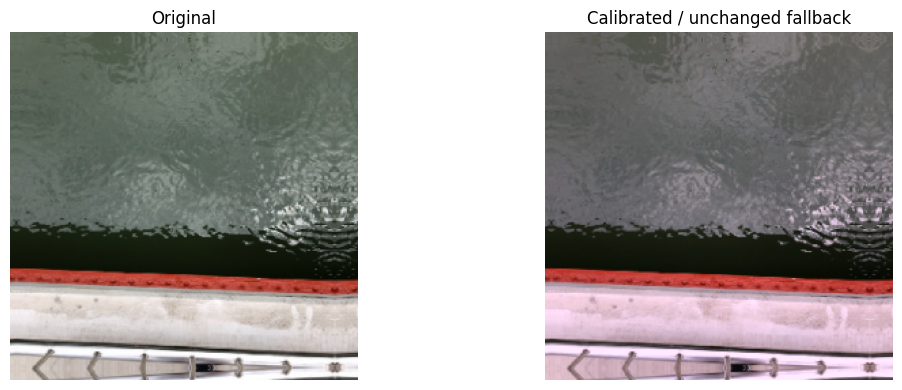

In [9]:

# CELL 9 — RonaCard detection + calibration preview

def show_bgr(ax,img,title):
    if img is None or img.size==0:
        ax.set_title(title); ax.axis("off"); return
    ax.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB)); ax.set_title(title); ax.axis("off")

preview_paths=quality_df.loc[quality_df["quality_status"].isin(["USABLE","REVIEW"]),"image_path"].tolist()
if preview_paths:
    p=preview_paths[0]
    img=cv2.imread(p)
    det=detect_ronacard(img)
    cal,meta=calibrate_with_ronacard(img,det)
    print("Detection:",det)
    print("Calibration:",meta)
    fig,ax=plt.subplots(1,2,figsize=(12,4))
    show_bgr(ax[0],img,"Original")
    show_bgr(ax[1],cal,"Calibrated / unchanged fallback")
    plt.tight_layout(); plt.show()
else:
    print("No preview images available after quality audit.")

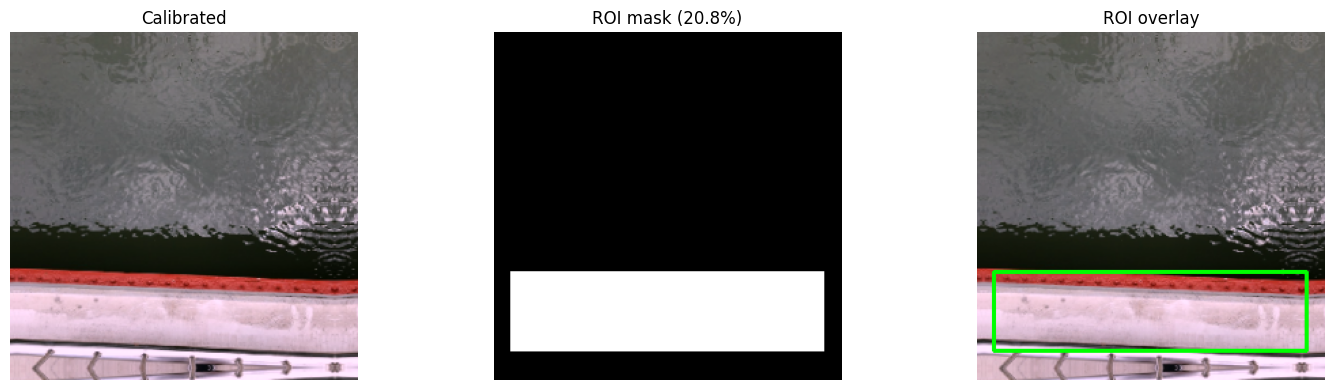

In [10]:

# CELL 10 — Water ROI preview
if preview_paths:
    p=preview_paths[0]
    img=cv2.imread(p)
    det=detect_ronacard(img)
    cal,_=calibrate_with_ronacard(img,det)
    roi=extract_water_roi(cal,det)
    overlay=cal.copy()
    contours,_=cv2.findContours(roi["roi_mask"],cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(overlay,contours,-1,(0,255,0),2)
    fig,ax=plt.subplots(1,3,figsize=(15,4))
    show_bgr(ax[0],cal,"Calibrated")
    ax[1].imshow(roi["roi_mask"],cmap="gray"); ax[1].set_title(f"ROI mask ({roi['coverage']:.1%})"); ax[1].axis("off")
    show_bgr(ax[2],overlay,"ROI overlay")
    plt.tight_layout(); plt.show()

In [11]:
# CELL 11 — OpenCV visual feature extraction (KEPT; now also carries the extended RGB/HSV/LAB block)
feature_csv=OUTPUT_DIR/"visual_features.csv"
features_df=build_visual_feature_table(inventory_df,quality_df,feature_csv)
if features_df.empty:
    raise RuntimeError("No visual features could be extracted. Check image paths/quality and inspect the first failing images.")

# Merge the validated/allowed label column only when scientifically permitted.
if features_label_source:
    label_map=inventory_df[["image_path",features_label_source]].drop_duplicates("image_path")
    features_df=features_df.merge(label_map,on="image_path",how="left")
    features_df.to_csv(feature_csv,index=False)

# ADD-ON: report the feature blocks that are now available
FEATURE_GROUPS=feature_columns_by_group(features_df)
print("Rows:",len(features_df)," Columns:",len(features_df.columns))
print("RGB block        :",len(FEATURE_GROUPS["A_rgb"]),"features")
print("HSV block        :",len(FEATURE_GROUPS["hsv"]),"features")
print("CIELAB block     :",len(FEATURE_GROUPS["lab"]),"features")
print("Histogram block  :",len(FEATURE_GROUPS["hist"]),"features")
print("Texture block    :",len(FEATURE_GROUPS["texture"]),"features")
print("RonaCard calibration applied on:",
      f'{float(features_df["ronacard_calibrated"].mean()):.1%}' if "ronacard_calibrated" in features_df else "Not available",
      "of images (fallback = uncalibrated original, documented as a limitation)")
print("Missing values per column (top 10 non-zero):")
na=features_df.isna().sum()
display(na[na>0].sort_values(ascending=False).head(10).to_frame("n_missing") if (na>0).any() else pd.DataFrame({"n_missing":[]}))
display(features_df[["image_path","rgb_mean_r","rgb_mean_g","rgb_mean_b","norm_g",
                     "hsv_h_deg_mean","lab_L_star_mean","lab_a_star_mean","visual_score"]].head())
print("Saved:",feature_csv)

/tmp/ipykernel_1469/996156569.py:334: RuntimeWarning: Mean of empty slice.
  "hsv_h_mean":float(hp[:,0].mean()),"hsv_h_median":float(np.median(hp[:,0])),"hsv_h_std":float(hp[:,0].std()),
/usr/local/lib/python3.13/dist-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/usr/local/lib/python3.13/dist-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.13/dist-packages/numpy/_core/_methods.py:227: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/local/lib/python3.13/dist-packages/numpy/_core/_methods.py:184: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/usr/local/lib/python3.13/dist-packages/numpy/_core/_methods.py:219: RuntimeWarning: invalid value encountered in scalar divide
  ret

Rows: 22379  Columns: 106
RGB block        : 29 features
HSV block        : 13 features
CIELAB block     : 14 features
Histogram block  : 32 features
Texture block    : 5 features
RonaCard calibration applied on: 66.2% of images (fallback = uncalibrated original, documented as a limitation)
Missing values per column (top 10 non-zero):


,n_missing
hsv_h_mean,4005
hsv_h_median,4005
hsv_h_std,4005
hsv_s_mean,4005
hsv_s_std,4005
hsv_v_mean,4005
hsv_v_std,4005
lab_l_mean,4005
lab_l_std,4005
lab_a_mean,4005


,image_path,rgb_mean_r,rgb_mean_g,rgb_mean_b,norm_g,hsv_h_deg_mean,lab_L_star_mean,lab_a_star_mean,visual_score
0,/content/RonaAir_CV/01_data/extracted/dataset_...,197.802032,153.725739,165.889420,0.296422,256.630567,67.830391,18.861178,5.25
1,/content/RonaAir_CV/01_data/extracted/dataset_...,197.145126,167.840698,166.984528,0.316359,190.738312,71.280367,10.799567,3.84
2,/content/RonaAir_CV/01_data/extracted/dataset_...,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,0.00
3,/content/RonaAir_CV/01_data/extracted/dataset_...,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,0.00
4,/content/RonaAir_CV/01_data/extracted/dataset_...,73.733376,110.950630,73.587372,0.477057,123.458975,42.953190,-20.541005,74.99


Saved: /content/RonaAir_CV/05_outputs/visual_features.csv


In [12]:

# CELL 12 — MobileNetV3-Small feature extraction (memory-safe memmap)
mobilenet_result={"status":"SKIPPED"}
feature_model=None

if RUN_MOBILENET:
    feature_model=create_mobilenet_feature_extractor()
    embed_paths=features_df["image_path"].tolist()
    if DEBUG_MODE:
        embed_paths=embed_paths[:DEBUG_SAMPLE_SIZE]
    mobilenet_result=extract_embeddings_memmap(embed_paths,feature_model,OUTPUT_DIR/"mobilenet_embeddings")
    print(mobilenet_result)
else:
    print("RUN_MOBILENET=False — embedding extraction skipped")

save_json(mobilenet_result,OUTPUT_DIR/"mobilenet_result.json")

4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
{'memmap': '/content/RonaAir_CV/05_outputs/mobilenet_embeddings/embeddings.float32.memmap', 'metadata_csv': '/content/RonaAir_CV/05_outputs/mobilenet_embeddings/embedding_metadata.csv', 'n': 22379, 'dim': 576}


In [13]:
# CELL 13 — Data split strategy (KEPT + EXTENDED: leakage-aware group split with safe fallback)
split_label_col=features_label_source if features_label_source else ""

# ADD-ON: group ids protect against the same scene/sample appearing in train and test.
features_df["group_id"]=assign_group_ids(features_df)
split_df,split_meta=create_group_aware_split(features_df,split_label_col,SEED,group_col="group_id")

# Safety net: if the group-aware split cannot produce val/test (too few groups),
# fall back to the baseline sample-level split and say so explicitly.
if len(features_df)>=20 and (split_meta.get("val",0)==0 or split_meta.get("test",0)==0):
    print("Group-aware split produced an empty val/test set -> falling back to the baseline sample-level split.")
    split_df,split_meta=create_data_split(features_df,split_label_col,SEED)
    split_meta["split_strategy"]=split_meta.get("split_strategy","")+"_fallback_from_group_split"
    if "group_id" not in split_df.columns:
        split_df["group_id"]=features_df["group_id"].values

split_df.to_csv(OUTPUT_DIR/"data_split.csv",index=False)
display(pd.DataFrame([split_meta]))
print("Split strategy:",split_meta.get("split_strategy"))
if "random_fallback_no_validated_label" in str(split_meta.get("split_strategy")):
    print("NOTE: This split is exploratory only because no validated labels were available.")
if split_label_col:
    print("\nClass distribution per split:")
    display(pd.crosstab(split_df[split_label_col].astype(str),split_df["split"]))

,split_strategy,train,val,test,n_groups
0,group_aware_stratified_split,15809,3303,3267,20344


Split strategy: group_aware_stratified_split

Class distribution per split:


split,test,train,val
rona_class,,,
Algbl_Bur”n_™vik_230813,0,3,0
Algbl_F„rnsvik_Kramfors_230822,0,3,0
Algbl_F„sk„r_Hudiksvall_230814,1,2,0
Algbl_Hummelviksstrand_230815,0,3,0
Algbl_Lingar”viken_230814,0,5,0
Algbl_L”v”udden_Ume†_230815,0,2,0
Algbl_L”v”udden_Ume†_230819,0,2,0
Algbl_M†viken_Kramfors_230821,1,3,1
Algbl_Strandpromenaden_Hudiksvall_230813,1,3,0


In [14]:
# CELL 13B — ADD-ON: data leakage check
leakage_report=check_split_leakage(split_df,group_col="group_id")
save_json(leakage_report,OUTPUT_DIR/"leakage_report.json")
print("=== DATA LEAKAGE CHECK ===")
print("Status                        :",leakage_report.get("status"))
print("Groups spanning >1 split      :",leakage_report.get("group_leaks","Not available"))
print("Identical images (sha256) in >1 split:",leakage_report.get("sha_leaks","Not available"))
if leakage_report.get("status")=="LEAKAGE_DETECTED":
    print("Examples of leaking groups:",leakage_report.get("leaking_groups",[])[:5])
    print("ACTION: results below must be read as optimistic; re-run with group-aware split enabled.")
else:
    print("No duplicate/same-scene image was found on both sides of the split.")
display(pd.DataFrame([{k:v for k,v in leakage_report.items() if not isinstance(v,list)}]))

=== DATA LEAKAGE CHECK ===
Status                        : OK
Groups spanning >1 split      : 0
Identical images (sha256) in >1 split: 0
No duplicate/same-scene image was found on both sides of the split.


,status,group_leaks,sha_leaks
0,OK,0,0


In [15]:
# CELL 13C — ADD-ON: class imbalance audit and class weights (audit BEFORE any resampling)
class_balance_report={"status":"NOT_AVAILABLE","reason":"No validated label source"}
CLASS_NAMES=[]
CLASS_WEIGHTS=None
if features_label_source and features_label_source in split_df.columns:
    labeled_all=split_df.dropna(subset=[features_label_source]).copy()
    labeled_all[features_label_source]=labeled_all[features_label_source].astype(str)
    CLASS_NAMES=sorted(labeled_all[features_label_source].unique().tolist())
    counts=labeled_all[features_label_source].value_counts().reindex(CLASS_NAMES).fillna(0).astype(int)
    train_counts=labeled_all[labeled_all.split=="train"][features_label_source].value_counts().reindex(CLASS_NAMES).fillna(0).astype(int)
    display(pd.DataFrame({"total":counts,"train":train_counts,
                          "share":(counts/max(int(counts.sum()),1)).round(4)}))
    y_train_int=labeled_all[labeled_all.split=="train"][features_label_source].map({c:i for i,c in enumerate(CLASS_NAMES)}).astype(int).values
    CLASS_WEIGHTS=compute_class_weights(y_train_int,len(CLASS_NAMES)) if USE_CLASS_WEIGHTS else None
    imb=float(counts.max()/max(int(counts.min()),1))
    class_balance_report={"status":"OK","classes":CLASS_NAMES,
                          "counts":{k:int(v) for k,v in counts.items()},
                          "imbalance_ratio":imb,
                          "strategy":"stratified split + class_weight" if USE_CLASS_WEIGHTS else "stratified split only",
                          "class_weights":{str(k):round(float(v),4) for k,v in (CLASS_WEIGHTS or {}).items()}}
    print("Imbalance ratio (max/min):",fmt_metric(imb,2))
    print("Class weights:",class_balance_report["class_weights"] or "disabled")
    print("No oversampling is applied: the audit above plus class_weight is the chosen mitigation.")
else:
    print("Class imbalance audit: Not available (no validated label source).")
save_json(class_balance_report,OUTPUT_DIR/"class_balance_report.json")

,total,train,share
rona_class,,,
Algbl_Bur”n_™vik_230813,3,3,0.0001
Algbl_F„rnsvik_Kramfors_230822,3,3,0.0001
Algbl_F„sk„r_Hudiksvall_230814,3,2,0.0001
Algbl_Hummelviksstrand_230815,3,3,0.0001
Algbl_Lingar”viken_230814,5,5,0.0002
Algbl_L”v”udden_Ume†_230815,2,2,0.0001
Algbl_L”v”udden_Ume†_230819,2,2,0.0001
Algbl_M†viken_Kramfors_230821,5,3,0.0002
Algbl_Strandpromenaden_Hudiksvall_230813,4,3,0.0002


Imbalance ratio (max/min): 7136.50
Class weights: {'0': 169.9892, '1': 169.9892, '2': 254.9839, '3': 169.9892, '4': 101.9935, '5': 254.9839, '6': 254.9839, '7': 169.9892, '8': 169.9892, '9': 169.9892, '10': 254.9839, '11': 254.9839, '12': 254.9839, '13': 84.9946, '14': 254.9839, '15': 169.9892, '16': 169.9892, '17': 169.9892, '18': 169.9892, '19': 101.9935, '20': 254.9839, '21': 169.9892, '22': 169.9892, '23': 254.9839, '24': 169.9892, '25': 127.4919, '26': 84.9946, '27': 14.1658, '28': 0.2014, '29': 0.1613, '30': 0.051}
No oversampling is applied: the audit above plus class_weight is the chosen mitigation.


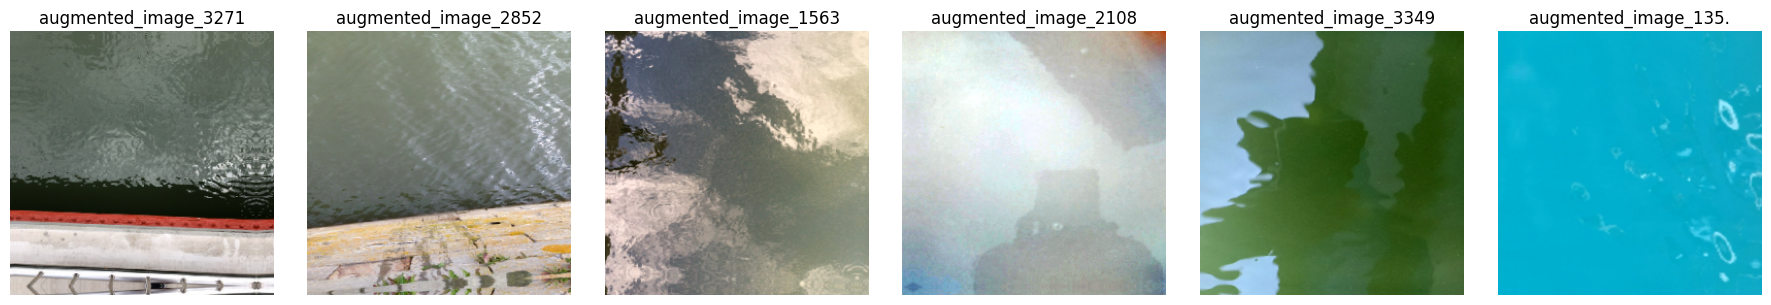

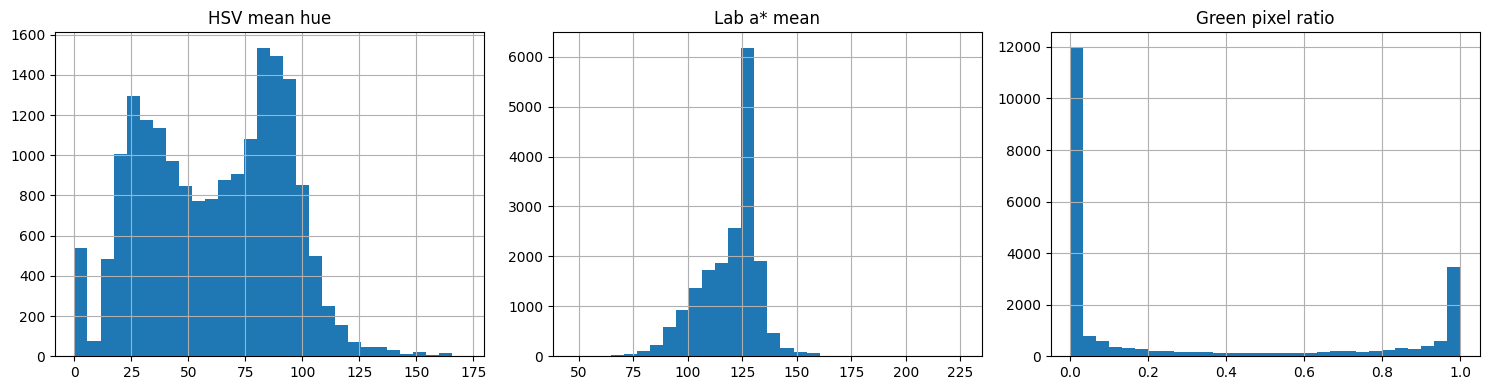

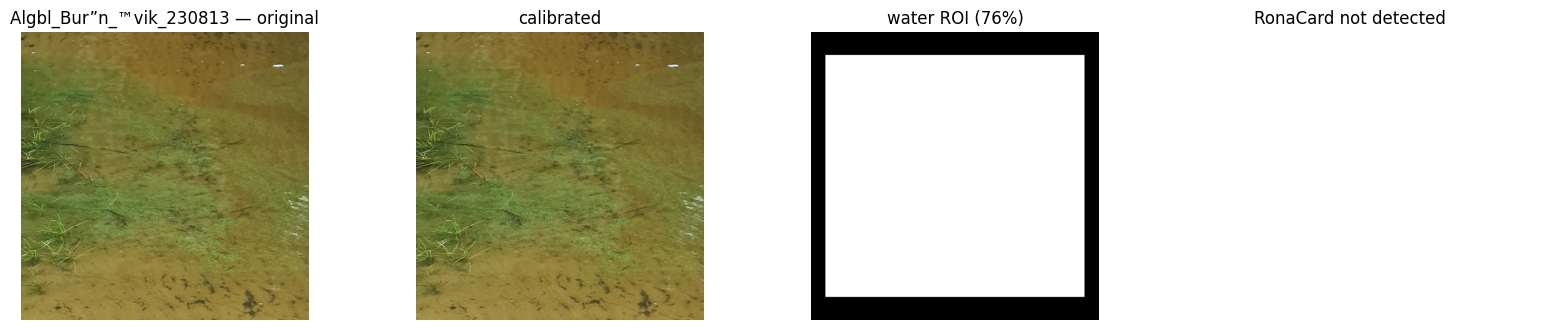

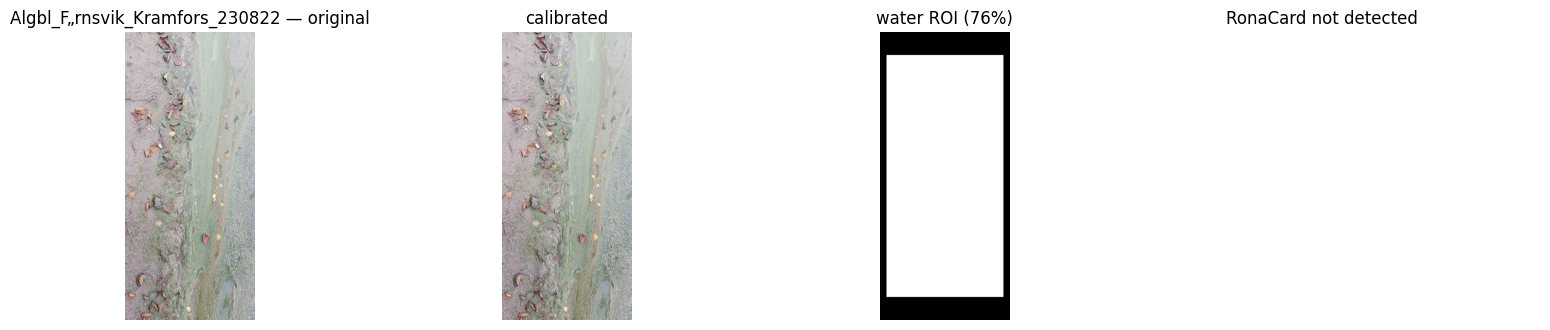

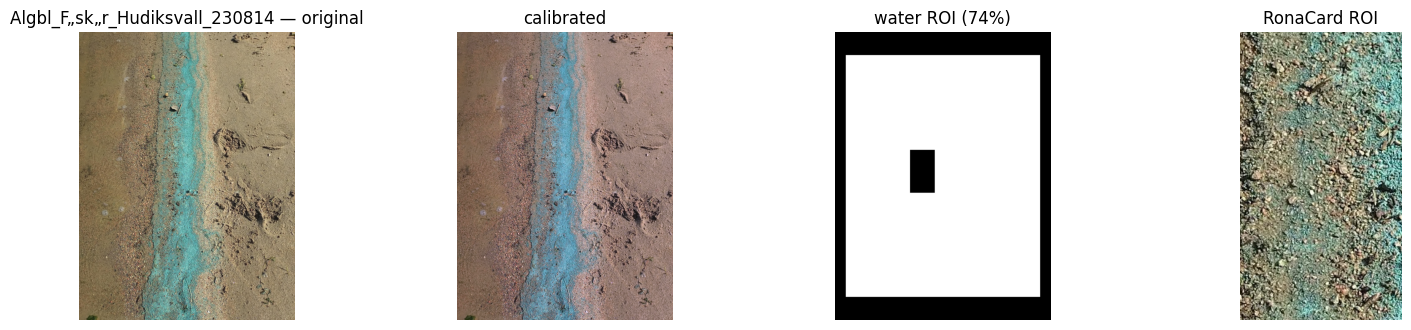

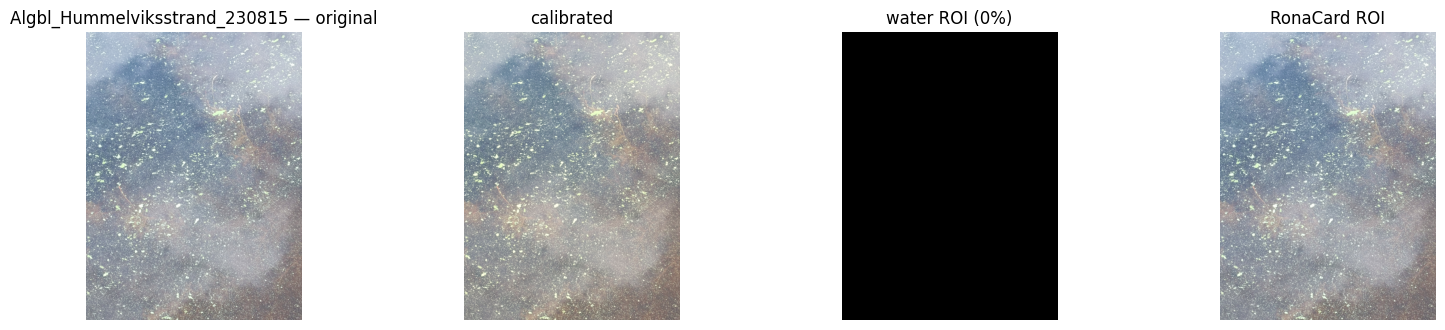

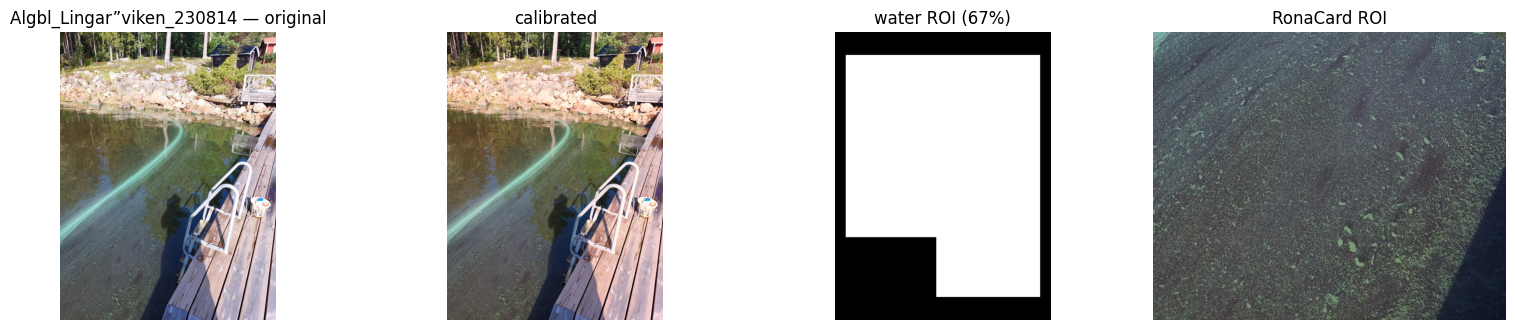

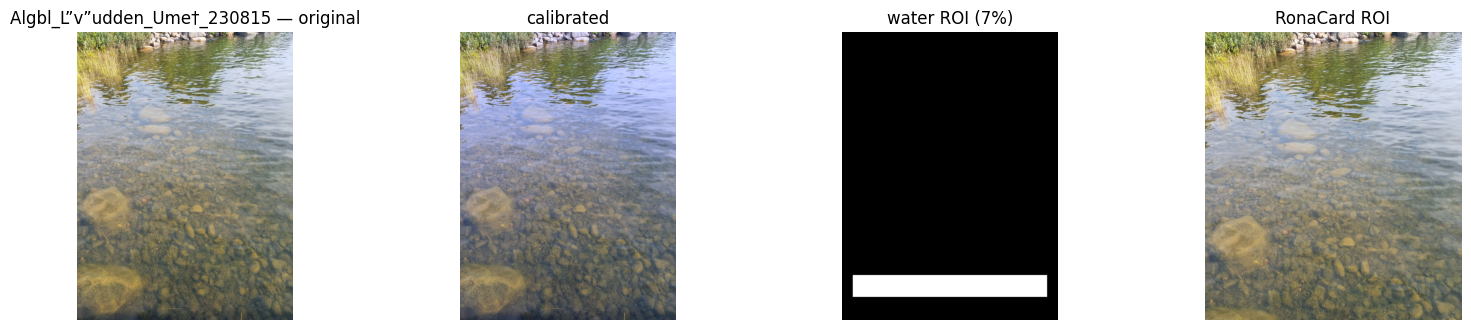

/tmp/ipykernel_1469/1114795137.py:61: UserWarning: Glyph 27293 (\N{CJK UNIFIED IDEOGRAPH-6A9D}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1469/1114795137.py:61: UserWarning: Glyph 27289 (\N{CJK UNIFIED IDEOGRAPH-6A99}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 27293 (\N{CJK UNIFIED IDEOGRAPH-6A9D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 27289 (\N{CJK UNIFIED IDEOGRAPH-6A99}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


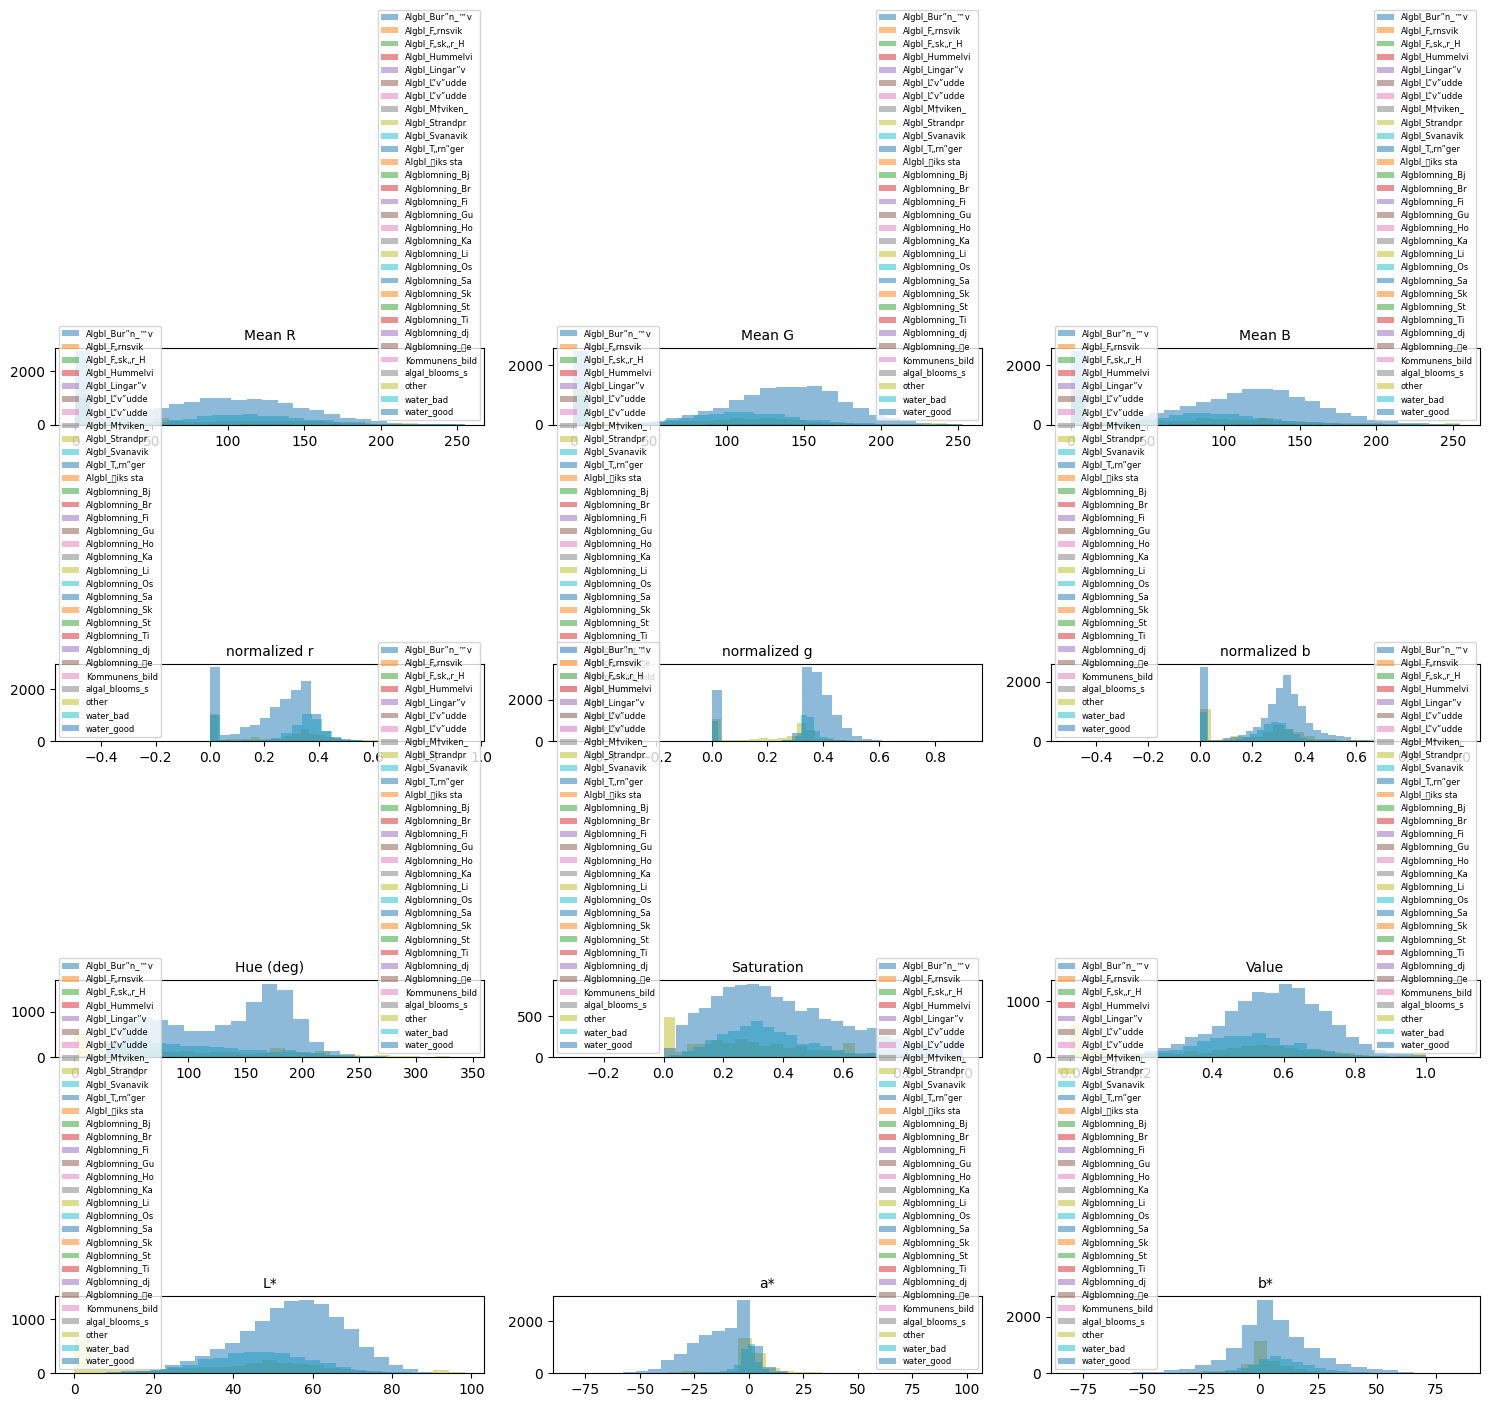

/tmp/ipykernel_1469/1114795137.py:73: UserWarning: Glyph 27293 (\N{CJK UNIFIED IDEOGRAPH-6A9D}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1469/1114795137.py:73: UserWarning: Glyph 27289 (\N{CJK UNIFIED IDEOGRAPH-6A99}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 27293 (\N{CJK UNIFIED IDEOGRAPH-6A9D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 27289 (\N{CJK UNIFIED IDEOGRAPH-6A99}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


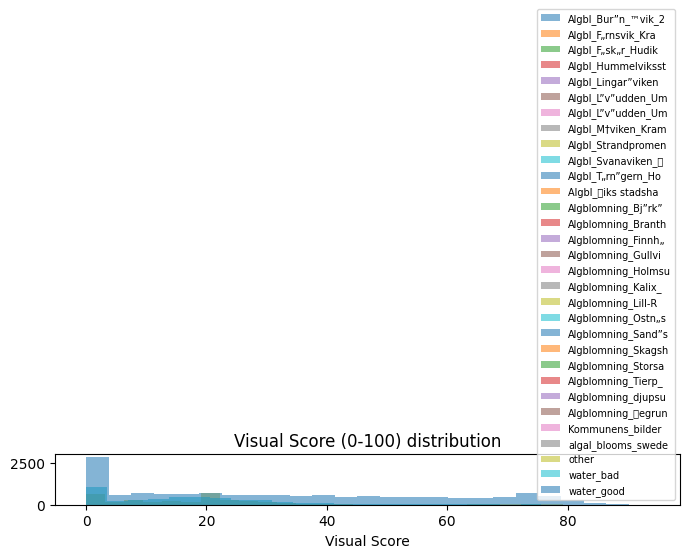

In [16]:
# CELL 14 — Visual analysis (KEPT + EXTENDED: per-class samples, RGB/HSV/CIELAB distributions)
sample_paths=features_df["image_path"].tolist()[:min(6,len(features_df))]
if sample_paths:
    fig,ax=plt.subplots(1,len(sample_paths),figsize=(3*len(sample_paths),3))
    if len(sample_paths)==1: ax=[ax]
    for a,p in zip(ax,sample_paths):
        img=cv2.imread(p); show_bgr(a,img,Path(p).name[:20])
    plt.tight_layout(); plt.show()

fig,ax=plt.subplots(1,3,figsize=(15,4))
if "hsv_h_mean" in features_df: features_df["hsv_h_mean"].hist(bins=30,ax=ax[0]); ax[0].set_title("HSV mean hue")
if "lab_a_mean" in features_df: features_df["lab_a_mean"].hist(bins=30,ax=ax[1]); ax[1].set_title("Lab a* mean")
if "green_pixel_ratio" in features_df: features_df["green_pixel_ratio"].hist(bins=30,ax=ax[2]); ax[2].set_title("Green pixel ratio")
plt.tight_layout(); plt.show()

# ---------------- ADD-ON: one sample image per class + ROI + RonaCard ROI ----------------
if features_label_source and features_label_source in features_df.columns:
    classes=sorted(features_df[features_label_source].dropna().astype(str).unique().tolist())
    for cls in classes[:6]:
        sub=features_df[features_df[features_label_source].astype(str)==cls]
        if sub.empty: continue
        p=sub["image_path"].iloc[0]
        img=cv2.imread(p)
        if img is None: continue
        det=detect_ronacard(img); cal,_=calibrate_with_ronacard(img,det); roi=extract_water_roi(cal,det)
        fig,ax=plt.subplots(1,4,figsize=(16,3.4))
        show_bgr(ax[0],img,f"{cls} — original")
        show_bgr(ax[1],cal,"calibrated")
        ax[2].imshow(roi["roi_mask"],cmap="gray"); ax[2].set_title(f"water ROI ({roi['coverage']:.0%})"); ax[2].axis("off")
        if det.get("detected",False):
            x,y,w,h=det["bbox"]; show_bgr(ax[3],img[y:y+h,x:x+w],"RonaCard ROI")
        else:
            ax[3].axis("off"); ax[3].set_title("RonaCard not detected")
        plt.tight_layout(); plt.show()

# ADD-ON: labelled view used by the per-class histograms below
labeled_view=None
if features_label_source and features_label_source in features_df.columns:
    labeled_view=features_df.dropna(subset=[features_label_source]).copy()
    labeled_view["_cls_"]=labeled_view[features_label_source].astype(str)

# ---------------- ADD-ON: RGB / normalized RGB / HSV / CIELAB distributions ----------------
dist_cols=[("rgb_mean_r","Mean R"),("rgb_mean_g","Mean G"),("rgb_mean_b","Mean B"),
           ("norm_r","normalized r"),("norm_g","normalized g"),("norm_b","normalized b"),
           ("hsv_h_deg_mean","Hue (deg)"),("hsv_s_norm_mean","Saturation"),("hsv_v_norm_mean","Value"),
           ("lab_L_star_mean","L*"),("lab_a_star_mean","a*"),("lab_b_star_mean","b*")]
dist_cols=[(c,t) for c,t in dist_cols if c in features_df.columns]
if dist_cols:
    ncol=3; nrow=int(math.ceil(len(dist_cols)/ncol))
    fig,axes=plt.subplots(nrow,ncol,figsize=(15,3.2*nrow))
    axes=np.array(axes).reshape(-1)
    for a,(c,t) in zip(axes,dist_cols):
        if labeled_view is not None:
            for cls,g in labeled_view.groupby("_cls_"):
                a.hist(pd.to_numeric(g[c],errors="coerce").dropna(),bins=25,alpha=0.5,label=str(cls)[:14])
            a.legend(fontsize=6)
        else:
            a.hist(pd.to_numeric(features_df[c],errors="coerce").dropna(),bins=30)
        a.set_title(t,fontsize=10)
    for a in axes[len(dist_cols):]: a.axis("off")
    plt.tight_layout(); plt.show()

# ---------------- ADD-ON: Visual Score distribution ----------------
if "visual_score" in features_df.columns:
    fig,ax=plt.subplots(figsize=(7,3.5))
    if labeled_view is not None:
        for cls,g in labeled_view.groupby("_cls_"):
            ax.hist(g["visual_score"],bins=25,alpha=0.55,label=str(cls)[:18])
        ax.legend(fontsize=7)
    else:
        ax.hist(features_df["visual_score"],bins=30)
    ax.set_title("Visual Score (0-100) distribution"); ax.set_xlabel("Visual Score")
    plt.tight_layout(); plt.show()

In [17]:
# CELL 14B — ADD-ON: actual RGB / HSV / CIELAB profile per class (no invented numbers)
rgb_profile=pd.DataFrame()
if features_label_source and features_label_source in features_df.columns:
    rgb_profile=rgb_class_profile_table(features_df.dropna(subset=[features_label_source]),features_label_source)
    display(rgb_profile)
    rgb_profile.to_csv(OUTPUT_DIR/"rgb_class_profile.csv",index=False)
    print("Saved:",OUTPUT_DIR/"rgb_class_profile.csv")
    print("Columns are ROI-only means computed from the actual images "
          "(Mean R/G/B 0-255, r/g/b normalized chromaticity, Hue in degrees, Saturation 0-1, L* 0-100, a*/b* -128..127).")
else:
    print("Per-class RGB profile: Not available (no validated label source).")

,Class,n,Mean R,Mean G,Mean B,r,g,b,Hue(deg),Saturation,Value,L*,a*,b*,Visual Score
0,Algbl_Bur”n_™vik_230813,3,120.8664,117.2859,64.4539,0.4004,0.3947,0.2049,60.2623,0.5133,0.5025,48.1656,-6.3913,29.2881,40.4733
1,Algbl_F„rnsvik_Kramfors_230822,3,134.1771,134.2956,125.8148,0.3480,0.3436,0.3083,121.3610,0.1990,0.5625,55.3072,-1.2112,4.8391,12.4833
2,Algbl_F„sk„r_Hudiksvall_230814,3,137.0103,123.2678,116.3424,0.3709,0.3294,0.2997,73.7205,0.2739,0.5665,52.4525,4.7329,6.2831,9.2767
3,Algbl_Hummelviksstrand_230815,3,35.4208,38.9634,41.9032,0.1062,0.1120,0.1151,143.2461,0.2719,0.5226,47.9906,-1.0947,-5.4596,4.4333
4,Algbl_Lingar”viken_230814,5,138.2505,136.7330,131.7683,0.3292,0.3439,0.3270,153.6211,0.3149,0.6201,56.8873,0.9846,3.8632,18.7400
5,Algbl_L”v”udden_Ume†_230815,2,132.2073,124.0652,94.3971,0.3729,0.3553,0.2718,80.9389,0.2876,0.5263,51.7523,-1.4360,16.9561,18.1850
6,Algbl_L”v”udden_Ume†_230819,2,105.8134,127.7877,148.9685,0.2954,0.3371,0.3674,162.6913,0.4161,0.6393,52.3613,0.0651,-12.4550,15.4800
7,Algbl_M†viken_Kramfors_230821,5,141.0933,141.8161,122.3400,0.3531,0.3469,0.2999,128.6911,0.2125,0.5836,58.2028,-3.4346,10.4242,15.9760
8,Algbl_Strandpromenaden_Hudiksvall_230813,4,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,0.0000
9,Algbl_Svanaviken_檝ik_230814,3,120.2414,139.8466,147.7097,0.2771,0.3463,0.3686,171.7821,0.4511,0.6592,56.7224,-2.0108,-6.1453,17.5200


Saved: /content/RonaAir_CV/05_outputs/rgb_class_profile.csv
Columns are ROI-only means computed from the actual images (Mean R/G/B 0-255, r/g/b normalized chromaticity, Hue in degrees, Saturation 0-1, L* 0-100, a*/b* -128..127).


In [18]:

# CELL 15 — Unsupervised visual grouping when labels are uncertain
feature_groups=feature_columns_by_group(features_df)
cluster_report={"status":"SKIPPED"}
cluster_csv=OUTPUT_DIR/"unsupervised_clusters.csv"
if not features_label_source:
    cluster_cols=feature_groups["B_color_texture"]
    cluster_report=clustering_report(features_df,cluster_cols,cluster_csv,n_clusters=3)
    if cluster_csv.exists():
        cluster_df=pd.read_csv(cluster_csv)
        reps=cluster_df.groupby("cluster").head(1)
        if not reps.empty:
            fig,ax=plt.subplots(1,len(reps),figsize=(4*len(reps),4))
            if len(reps)==1: ax=[ax]
            for a,(_,r) in zip(ax,reps.iterrows()):
                show_bgr(a,cv2.imread(r["image_path"]),f"Cluster {r['cluster']}")
            plt.tight_layout(); plt.show()
else:
    cluster_report={"status":"SKIPPED","reason":"Validated label path available; unsupervised grouping not primary experiment"}
save_json(cluster_report,OUTPUT_DIR/"unsupervised_report.json")
display(pd.DataFrame([cluster_report]))

,status,reason
0,SKIPPED,Validated label path available; unsupervised g...


=== COLOR FEATURE SEPARATION (Silhouette Score, NOT accuracy) ===
Silhouette — RGB/HSV/LAB features vs class             : -0.3381  -> negatif: banyak sampel lebih dekat ke cluster lain  (n=4000)
Silhouette — MobileNetV3 embedding vs class            : -0.0869  -> negatif: banyak sampel lebih dekat ke cluster lain  (n=4000)
Silhouette — KMeans on color features (unsupervised)   : 0.2163  -> cluster saling overlap  (n=4000)


/tmp/ipykernel_1469/462883525.py:81: UserWarning: Glyph 27293 (\N{CJK UNIFIED IDEOGRAPH-6A9D}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1469/462883525.py:81: UserWarning: Glyph 27289 (\N{CJK UNIFIED IDEOGRAPH-6A99}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 27293 (\N{CJK UNIFIED IDEOGRAPH-6A9D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 27289 (\N{CJK UNIFIED IDEOGRAPH-6A99}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


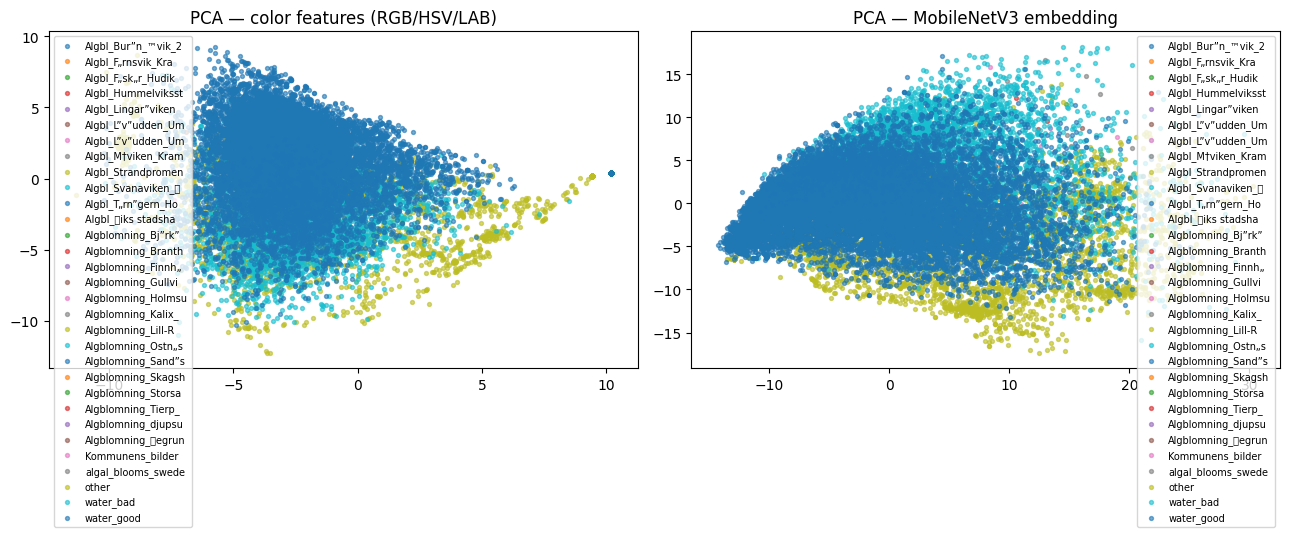

In [19]:
# CELL 15B — ADD-ON: SILHOUETTE ANALYSIS (COLOR FEATURE SEPARATION — NOT AN ACCURACY)
# Silhouette Score measures how compact/separated the groups are in feature space.
#   +1 -> compact and well separated | 0 -> overlapping | negative -> samples closer to another group
# It is reported SEPARATELY from Accuracy/F1 and is never converted into a percentage accuracy.
silhouette_report={"rgb_features":{"status":"NOT_AVAILABLE"},
                   "embedding":{"status":"NOT_AVAILABLE"},
                   "kmeans_rgb":{"status":"NOT_AVAILABLE"}}

rgb_cols=[c for c in FEATURE_GROUPS["A_rgb"]+FEATURE_GROUPS["hsv"]+FEATURE_GROUPS["lab"] if c in features_df.columns]
label_series=features_df[features_label_source].astype(str) if (features_label_source and features_label_source in features_df.columns) else None

# ---- 1. Silhouette on explicit color features, grouped by class label ----
if label_series is not None and rgb_cols:
    valid=features_df[label_series.notna() & (label_series!="nan")]
    silhouette_report["rgb_features"]=silhouette_from_matrix(
        valid[rgb_cols].replace([np.inf,-np.inf],np.nan).astype(float).values,
        valid[features_label_source].astype(str).values, seed=SEED)
else:
    silhouette_report["rgb_features"]={"status":"NOT_AVAILABLE","reason":"No validated label source or no color features"}

# ---- 2. Silhouette on MobileNetV3-Small embeddings, grouped by class label ----
EMB_PATHS,EMB_MATRIX=load_embedding_matrix(mobilenet_result)
EMB_INDEX={p:i for i,p in enumerate(EMB_PATHS)} if EMB_PATHS else {}
if EMB_MATRIX is not None and label_series is not None:
    sub=features_df[features_df["image_path"].astype(str).isin(EMB_INDEX.keys())].dropna(subset=[features_label_source])
    if len(sub)>=10:
        idx=[EMB_INDEX[p] for p in sub["image_path"].astype(str)]
        silhouette_report["embedding"]=silhouette_from_matrix(EMB_MATRIX[idx],
                                                             sub[features_label_source].astype(str).values,seed=SEED)
    else:
        silhouette_report["embedding"]={"status":"NOT_AVAILABLE","reason":"Fewer than 10 labelled embeddings"}
else:
    silhouette_report["embedding"]={"status":"NOT_AVAILABLE","reason":"No embeddings or no labels"}

# ---- 3. Unsupervised KMeans silhouette on color features (label-free reference) ----
if rgb_cols:
    Xc=features_df[rgb_cols].replace([np.inf,-np.inf],np.nan).dropna()
    if len(Xc)>=30:
        k=min(4,max(2,int(features_df[features_label_source].nunique()) if features_label_source else 4))
        Z=StandardScaler().fit_transform(Xc.values)
        if len(Z)>4000:
            rs=np.random.RandomState(SEED); Z=Z[rs.choice(len(Z),4000,replace=False)]
        km=KMeans(n_clusters=k,random_state=SEED,n_init=10).fit(Z)
        silhouette_report["kmeans_rgb"]={"status":"OK","k":int(k),
                                         "silhouette_score":float(silhouette_score(Z,km.labels_)),
                                         "n_samples":int(len(Z))}

print("=== COLOR FEATURE SEPARATION (Silhouette Score, NOT accuracy) ===")
for key,title in [("rgb_features","Silhouette — RGB/HSV/LAB features vs class"),
                  ("embedding","Silhouette — MobileNetV3 embedding vs class"),
                  ("kmeans_rgb","Silhouette — KMeans on color features (unsupervised)")]:
    r=silhouette_report.get(key,{})
    if r.get("status")=="OK":
        s=r.get("silhouette_score")
        print(f"{title:55s}: {fmt_metric(s)}  -> {interpret_silhouette(s)}  (n={r.get('n_samples')})")
    else:
        print(f"{title:55s}: Not available ({r.get('reason','')})")
save_json(silhouette_report,OUTPUT_DIR/"silhouette_report.json")

# ---- 4. PCA / 2D embedding visualisation ----
try:
    if label_series is not None and rgb_cols:
        valid=features_df.dropna(subset=[features_label_source])
        Xp=StandardScaler().fit_transform(valid[rgb_cols].replace([np.inf,-np.inf],np.nan).fillna(0).values)
        P=pca_2d(Xp)
        fig,axs=plt.subplots(1,2 if EMB_MATRIX is not None else 1,figsize=(13 if EMB_MATRIX is not None else 6.5,5))
        axs=np.atleast_1d(axs)
        for cls in sorted(valid[features_label_source].astype(str).unique()):
            m=(valid[features_label_source].astype(str)==cls).values
            axs[0].scatter(P[m,0],P[m,1],s=8,alpha=0.6,label=str(cls)[:18])
        axs[0].set_title("PCA — color features (RGB/HSV/LAB)"); axs[0].legend(fontsize=7)
        if EMB_MATRIX is not None:
            sub=valid[valid["image_path"].astype(str).isin(EMB_INDEX.keys())]
            if len(sub)>=10:
                idx=[EMB_INDEX[p] for p in sub["image_path"].astype(str)]
                Pe=pca_2d(StandardScaler().fit_transform(EMB_MATRIX[idx]))
                for cls in sorted(sub[features_label_source].astype(str).unique()):
                    m=(sub[features_label_source].astype(str)==cls).values
                    axs[1].scatter(Pe[m,0],Pe[m,1],s=8,alpha=0.6,label=str(cls)[:18])
                axs[1].set_title("PCA — MobileNetV3 embedding"); axs[1].legend(fontsize=7)
        plt.tight_layout(); plt.show()
except Exception as e:
    print("PCA visualisation skipped:",repr(e))

In [20]:

# CELL 16 — Classical feature baselines (only when labels are validated)
classical_report={"status":"SKIPPED"}
if features_label_source:
    cols=feature_columns_by_group(features_df)["B_color_texture"]
    classical_report=classical_experiments(split_df,features_label_source,cols,OUTPUT_DIR/"classical_visual_model_comparison.csv")
print(classical_report)
save_json(classical_report,OUTPUT_DIR/"classical_report.json")

{'status': 'OK', 'results': [{'model': 'logistic', 'accuracy': 0.7609427609427609, 'macro_precision': 0.16529947070949266, 'macro_recall': 0.13668690073970904, 'macro_f1': 0.14492806744619374}, {'model': 'random_forest', 'accuracy': 0.7346189164370982, 'macro_precision': 0.20546878004782895, 'macro_recall': 0.2412694661296989, 'macro_f1': 0.18246323589537802}]}


Class weights (train split): {'Algbl_Bur”n_™vik_230813': 169.989, 'Algbl_F„rnsvik_Kramfors_230822': 169.989, 'Algbl_F„sk„r_Hudiksvall_230814': 254.984, 'Algbl_Hummelviksstrand_230815': 169.989, 'Algbl_Lingar”viken_230814': 101.994, 'Algbl_L”v”udden_Ume†_230815': 254.984, 'Algbl_L”v”udden_Ume†_230819': 254.984, 'Algbl_M†viken_Kramfors_230821': 169.989, 'Algbl_Strandpromenaden_Hudiksvall_230813': 169.989, 'Algbl_Svanaviken_檝ik_230814': 169.989, 'Algbl_T„rn”gern_Holmsund_230815': 254.984, 'Algbl_檝iks stadshamn_230814': 254.984, 'Algblomning_Bj”rk”fj„rden_Sundsvall_230724': 254.984, 'Algblomning_Branth„ll_S”dehamn_20230903': 84.995, 'Algblomning_Finnh„llan_K†gn„sudden_230726': 254.984, 'Algblomning_Gullvik_20230620': 169.989, 'Algblomning_Holmsund_20230828': 169.989, 'Algblomning_Kalix_Stor派amn_230712': 169.989, 'Algblomning_Lill-Renholmsgrundet_Lule†_230714': 169.989, 'Algblomning_Ostn„sudden_20230628': 101.994, 'Algblomning_Sand”skatan_Lule†_20230712': 254.984, 'Algblomning_Skagshamn_™rn

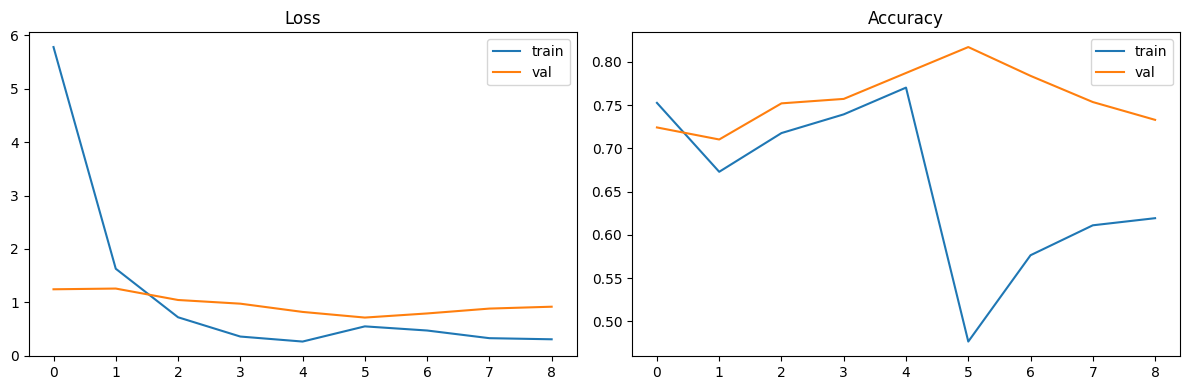

{'status': 'OK', 'classes': ['Algbl_Bur”n_™vik_230813', 'Algbl_F„rnsvik_Kramfors_230822', 'Algbl_F„sk„r_Hudiksvall_230814', 'Algbl_Hummelviksstrand_230815', 'Algbl_Lingar”viken_230814', 'Algbl_L”v”udden_Ume†_230815', 'Algbl_L”v”udden_Ume†_230819', 'Algbl_M†viken_Kramfors_230821', 'Algbl_Strandpromenaden_Hudiksvall_230813', 'Algbl_Svanaviken_檝ik_230814', 'Algbl_T„rn”gern_Holmsund_230815', 'Algbl_檝iks stadshamn_230814', 'Algblomning_Bj”rk”fj„rden_Sundsvall_230724', 'Algblomning_Branth„ll_S”dehamn_20230903', 'Algblomning_Finnh„llan_K†gn„sudden_230726', 'Algblomning_Gullvik_20230620', 'Algblomning_Holmsund_20230828', 'Algblomning_Kalix_Stor派amn_230712', 'Algblomning_Lill-Renholmsgrundet_Lule†_230714', 'Algblomning_Ostn„sudden_20230628', 'Algblomning_Sand”skatan_Lule†_20230712', 'Algblomning_Skagshamn_™rnsk”ldsvik_20230828', 'Algblomning_Storsand_20230629', 'Algblomning_Tierp_20230908', 'Algblomning_djupsundsviken_Holmsund_20230908', 'Algblomning_檙egrund_20230721', 'Kommunens_bilder', 'alga

In [21]:
# CELL 17 — MobileNetV3-Small supervised transfer learning (KEPT; EXTENDED with class weights)
# The main deep-learning model is unchanged: MobileNetV3-Small + ImageNet weights,
# frozen head training followed by a limited fine-tuning of the last 30 layers.
TRAINED_KERAS_MODEL=None
tf_training_report={"status":"SKIPPED"}

if RUN_TF_SUPERVISED and features_label_source:
    # Remove empty labels and ensure at least two classes.
    labeled=split_df.dropna(subset=[features_label_source]).copy()
    labeled[features_label_source]=labeled[features_label_source].astype(str)
    class_names=sorted(labeled[features_label_source].unique().tolist())
    if len(class_names)<2:
        tf_training_report={"status":"SKIPPED","reason":"Less than two classes"}
    elif labeled["split"].value_counts().get("train",0)<2 or labeled["split"].value_counts().get("val",0)<1:
        tf_training_report={"status":"SKIPPED","reason":"Insufficient train/validation samples"}
    else:
        train_part=labeled[labeled.split=="train"].copy()
        val_part=labeled[labeled.split=="val"].copy()
        test_part=labeled[labeled.split=="test"].copy()
        model,base=build_classifier(len(class_names))
        model.compile(optimizer=tf.keras.optimizers.Adam(LEARNING_RATE_HEAD),loss="sparse_categorical_crossentropy",metrics=["accuracy"])
        callbacks=[
            tf.keras.callbacks.EarlyStopping(monitor="val_loss",patience=3,restore_best_weights=True),
            tf.keras.callbacks.ModelCheckpoint(str(MODEL_DIR/"best_head.keras"),monitor="val_loss",save_best_only=True),
        ]
        tr_ds=supervised_ds(train_part,features_label_source,class_names,True,True,BATCH_SIZE)
        va_ds=supervised_ds(val_part,features_label_source,class_names,False,False,BATCH_SIZE)
        te_ds=supervised_ds(test_part,features_label_source,class_names,False,False,BATCH_SIZE) if len(test_part) else None
        # ADD-ON: class weights from the TRAIN split only (imbalance mitigation without oversampling)
        cw=None
        if USE_CLASS_WEIGHTS:
            y_tr=train_part[features_label_source].map({c:i for i,c in enumerate(class_names)}).astype(int).values
            cw=compute_class_weights(y_tr,len(class_names))
            print("Class weights (train split):",{class_names[k]:round(v,3) for k,v in cw.items()})
        history_head=model.fit(tr_ds,validation_data=va_ds,epochs=FREEZE_EPOCHS,callbacks=callbacks,class_weight=cw,verbose=1)
        # Fine-tune only a limited tail of the backbone.
        base.trainable=True
        for layer in base.layers[:-30]:
            layer.trainable=False
        model.compile(optimizer=tf.keras.optimizers.Adam(LEARNING_RATE_FINE),loss="sparse_categorical_crossentropy",metrics=["accuracy"])
        callbacks2=[
            tf.keras.callbacks.EarlyStopping(monitor="val_loss",patience=3,restore_best_weights=True),
            tf.keras.callbacks.ModelCheckpoint(str(MODEL_DIR/"best_finetuned.keras"),monitor="val_loss",save_best_only=True),
        ]
        history_ft=model.fit(tr_ds,validation_data=va_ds,epochs=FINE_TUNE_EPOCHS,callbacks=callbacks2,class_weight=cw,verbose=1)
        TRAINED_KERAS_MODEL=model
        pd.DataFrame(history_head.history).assign(stage="head").to_csv(OUTPUT_DIR/"training_history_head.csv",index=False)
        pd.DataFrame(history_ft.history).assign(stage="fine_tune").to_csv(OUTPUT_DIR/"training_history_finetune.csv",index=False)
        tf_training_report={"status":"OK","classes":class_names,"train":len(train_part),"val":len(val_part),"test":len(test_part),
                            "freeze_epochs":FREEZE_EPOCHS,"fine_tune_epochs":FINE_TUNE_EPOCHS,
                            "class_weights":{class_names[k]:round(float(v),4) for k,v in (cw or {}).items()},
                            "final_train_accuracy":float(history_ft.history.get("accuracy",[float("nan")])[-1]),
                            "final_val_accuracy":float(history_ft.history.get("val_accuracy",[float("nan")])[-1])}
        # ADD-ON: training curves
        try:
            hist=pd.concat([pd.DataFrame(history_head.history).assign(stage="head"),
                            pd.DataFrame(history_ft.history).assign(stage="fine_tune")],ignore_index=True)
            fig,ax=plt.subplots(1,2,figsize=(12,4))
            ax[0].plot(hist["loss"],label="train"); ax[0].plot(hist["val_loss"],label="val"); ax[0].set_title("Loss"); ax[0].legend()
            ax[1].plot(hist["accuracy"],label="train"); ax[1].plot(hist["val_accuracy"],label="val"); ax[1].set_title("Accuracy"); ax[1].legend()
            plt.tight_layout(); plt.show()
        except Exception as e:
            print("Training curve plot skipped:",repr(e))
else:
    tf_training_report={"status":"SKIPPED","reason":"RUN_TF_SUPERVISED=False or no validated label source"}

print(tf_training_report)
save_json(tf_training_report,OUTPUT_DIR/"tf_training_report.json")

=== CLASSIFICATION PERFORMANCE (Accuracy / Precision / Recall / F1) ===
Accuracy        : 0.8053
Macro Precision : 0.1387
Macro Recall    : 0.2226
Macro F1        : 0.1521
Weighted F1     : 0.8384
Test samples    : 3267

Classification report:


,precision,recall,f1-score,support
Algbl_Bur”n_™vik_230813,0.0000,0.0000,0.0000,0.0000
Algbl_F„rnsvik_Kramfors_230822,0.0000,0.0000,0.0000,0.0000
Algbl_F„sk„r_Hudiksvall_230814,0.5000,1.0000,0.6667,1.0000
Algbl_Hummelviksstrand_230815,0.0000,0.0000,0.0000,0.0000
Algbl_Lingar”viken_230814,0.0000,0.0000,0.0000,0.0000
Algbl_L”v”udden_Ume†_230815,0.0000,0.0000,0.0000,0.0000
Algbl_L”v”udden_Ume†_230819,0.0000,0.0000,0.0000,0.0000
Algbl_M†viken_Kramfors_230821,1.0000,1.0000,1.0000,1.0000
Algbl_Strandpromenaden_Hudiksvall_230813,0.0000,0.0000,0.0000,1.0000
Algbl_Svanaviken_檝ik_230814,0.0000,0.0000,0.0000,0.0000


/tmp/ipykernel_1469/996156569.py:1149: UserWarning: Glyph 27293 (\N{CJK UNIFIED IDEOGRAPH-6A9D}) missing from font(s) DejaVu Sans.
  fig.colorbar(im,ax=ax); plt.tight_layout(); plt.show()
/tmp/ipykernel_1469/996156569.py:1149: UserWarning: Glyph 27966 (\N{CJK UNIFIED IDEOGRAPH-6D3E}) missing from font(s) DejaVu Sans.
  fig.colorbar(im,ax=ax); plt.tight_layout(); plt.show()
/tmp/ipykernel_1469/996156569.py:1149: UserWarning: Glyph 27289 (\N{CJK UNIFIED IDEOGRAPH-6A99}) missing from font(s) DejaVu Sans.
  fig.colorbar(im,ax=ax); plt.tight_layout(); plt.show()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 27293 (\N{CJK UNIFIED IDEOGRAPH-6A9D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 27966 (\N{CJK UNIFIED IDEOGRAPH-6D3E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.1

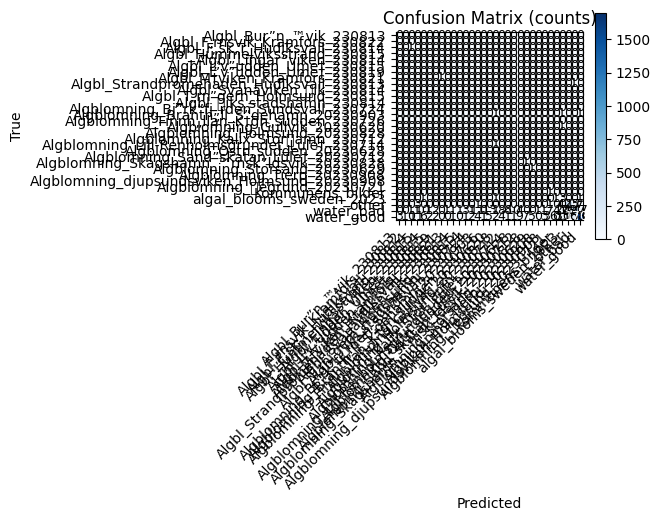

/tmp/ipykernel_1469/996156569.py:1149: UserWarning: Glyph 27293 (\N{CJK UNIFIED IDEOGRAPH-6A9D}) missing from font(s) DejaVu Sans.
  fig.colorbar(im,ax=ax); plt.tight_layout(); plt.show()
/tmp/ipykernel_1469/996156569.py:1149: UserWarning: Glyph 27966 (\N{CJK UNIFIED IDEOGRAPH-6D3E}) missing from font(s) DejaVu Sans.
  fig.colorbar(im,ax=ax); plt.tight_layout(); plt.show()
/tmp/ipykernel_1469/996156569.py:1149: UserWarning: Glyph 27289 (\N{CJK UNIFIED IDEOGRAPH-6A99}) missing from font(s) DejaVu Sans.
  fig.colorbar(im,ax=ax); plt.tight_layout(); plt.show()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 27293 (\N{CJK UNIFIED IDEOGRAPH-6A9D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 27966 (\N{CJK UNIFIED IDEOGRAPH-6D3E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.1

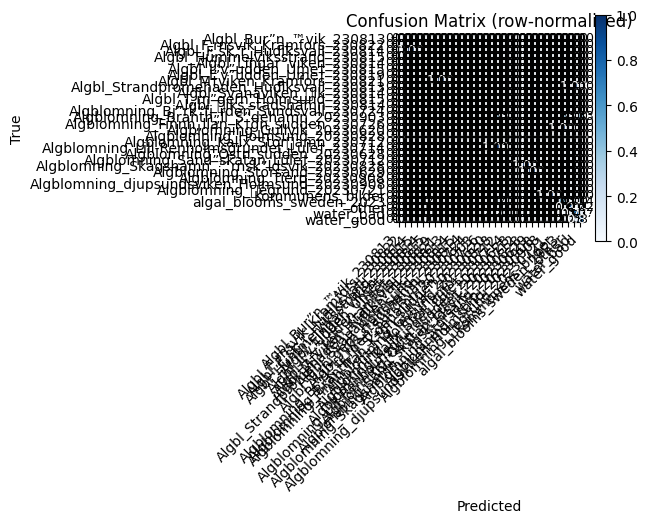

Saved per-image predictions: /content/RonaAir_CV/05_outputs/test_predictions.csv


In [22]:
# CELL 18 — Supervised evaluation (KEPT + EXTENDED: full classification metrics + per-image predictions)
supervised_eval={"status":"SKIPPED"}
test_predictions_df=pd.DataFrame()
CLASSIFICATION_REPORT={}
CONFUSION=None

if TRAINED_KERAS_MODEL is not None and features_label_source:
    labeled=split_df.dropna(subset=[features_label_source]).copy()
    labeled[features_label_source]=labeled[features_label_source].astype(str)
    class_names=sorted(labeled[features_label_source].unique().tolist())
    test_part=labeled[labeled.split=="test"].copy()
    if len(test_part):
        y_true=[]; y_pred=[]; confidences=[]; probas=[]
        ds=supervised_ds(test_part,features_label_source,class_names,False,False,BATCH_SIZE)
        for xb,yb in ds:
            p=TRAINED_KERAS_MODEL.predict(xb,verbose=0)
            pred=np.argmax(p,axis=1)
            y_true.extend(yb.numpy().tolist()); y_pred.extend(pred.tolist())
            confidences.extend(np.max(p,axis=1).tolist()); probas.extend(p.tolist())
        metrics,cm,report=full_classification_metrics(y_true,y_pred,class_names)
        supervised_eval={**metrics,"classes":class_names}
        CLASSIFICATION_REPORT=report; CONFUSION=cm

        print("=== CLASSIFICATION PERFORMANCE (Accuracy / Precision / Recall / F1) ===")
        print("Accuracy        :",fmt_metric(metrics["accuracy"]))
        print("Macro Precision :",fmt_metric(metrics["macro_precision"]))
        print("Macro Recall    :",fmt_metric(metrics["macro_recall"]))
        print("Macro F1        :",fmt_metric(metrics["macro_f1"]))
        print("Weighted F1     :",fmt_metric(metrics["weighted_f1"]))
        print("Test samples    :",metrics["n_test"])
        print("\nClassification report:")
        display(pd.DataFrame(report).transpose().round(4))
        pd.DataFrame(report).transpose().to_csv(OUTPUT_DIR/"classification_report.csv")
        pd.DataFrame(cm,index=class_names,columns=class_names).to_csv(OUTPUT_DIR/"confusion_matrix.csv")
        plot_confusion_matrix(cm,class_names,"Confusion Matrix (counts)",normalize=False)
        plot_confusion_matrix(cm,class_names,"Confusion Matrix (row-normalized)",normalize=True)

        # Per-image predictions (order of supervised_ds == order of test_part, shuffle=False)
        test_predictions_df=test_part.copy().reset_index(drop=True)
        n=min(len(test_predictions_df),len(y_pred))
        test_predictions_df=test_predictions_df.iloc[:n].copy()
        test_predictions_df["true_class"]=[class_names[i] for i in y_true[:n]]
        test_predictions_df["predicted_class"]=[class_names[i] for i in y_pred[:n]]
        test_predictions_df["confidence"]=confidences[:n]
        test_predictions_df["correct"]=test_predictions_df["true_class"]==test_predictions_df["predicted_class"]
        for i,c in enumerate(class_names):
            test_predictions_df[f"proba_{c}"]=[row[i] for row in probas[:n]]
        test_predictions_df.to_csv(OUTPUT_DIR/"test_predictions.csv",index=False)
        print("Saved per-image predictions:",OUTPUT_DIR/"test_predictions.csv")
    else:
        supervised_eval={"status":"SKIPPED","reason":"No test samples"}
else:
    supervised_eval={"status":"SKIPPED","reason":"No trained classifier (see CELL 17)"}
    print("CLASSIFICATION PERFORMANCE: Not available —",supervised_eval.get("reason"))

save_json(supervised_eval,OUTPUT_DIR/"supervised_evaluation.json")

In [23]:
# CELL 18B — ADD-ON: per-image RonaAir output (class + confidence + Visual Score + RGB/HSV/LAB)
per_image_output=pd.DataFrame()
out_cols=["image_path","predicted_class","confidence","visual_score",
          "rgb_mean_r","rgb_mean_g","rgb_mean_b","norm_r","norm_g","norm_b",
          "hsv_h_deg_mean","hsv_s_norm_mean","hsv_v_norm_mean",
          "lab_L_star_mean","lab_a_star_mean","lab_b_star_mean",
          "ronacard_detected","roi_coverage","true_class","correct"]
if not test_predictions_df.empty:
    per_image_output=test_predictions_df[[c for c in out_cols if c in test_predictions_df.columns]].copy()
elif not features_df.empty:
    # No classifier available: still emit the color-only output block.
    per_image_output=features_df[[c for c in out_cols if c in features_df.columns]].copy()
    print("Predicted class/confidence: Not available (classifier was not trained). "
          "Color features and Visual Score are still reported.")

if not per_image_output.empty:
    per_image_output=per_image_output.round(4)
    per_image_output.to_csv(OUTPUT_DIR/"per_image_output.csv",index=False)
    display(per_image_output.head(15))
    print("Rows:",len(per_image_output),"| Saved:",OUTPUT_DIR/"per_image_output.csv")
    print("\nVisual Score formula (deterministic, 0-100):")
    print("  VS = 100 * (0.35*green_chroma + 0.25*lab_green + 0.20*saturation + 0.20*density)")
    print("  green_chroma = clip((g_norm - 1/3)/0.12, 0, 1)   g_norm = G/(R+G+B) inside water ROI")
    print("  lab_green    = clip((-a*)/25, 0, 1)              a* < 0 means greener")
    print("  saturation   = clip(S, 0, 1)                     HSV saturation inside ROI")
    print("  density      = clip((60 - L*)/40, 0, 1)          darker/denser water")
    print("  VS is a visual descriptor, not a probability, not an accuracy, not a chemical measurement.")
    if "predicted_class" in per_image_output.columns and "visual_score" in per_image_output.columns:
        display(per_image_output.groupby("predicted_class")[["confidence","visual_score"]].mean().round(3))
else:
    print("Per-image output: Not available.")

,image_path,predicted_class,confidence,visual_score,rgb_mean_r,rgb_mean_g,rgb_mean_b,norm_r,norm_g,norm_b,hsv_h_deg_mean,hsv_s_norm_mean,hsv_v_norm_mean,lab_L_star_mean,lab_a_star_mean,lab_b_star_mean,ronacard_detected,roi_coverage,true_class,correct
0,/content/RonaAir_CV/01_data/extracted/dataset_...,other,0.8337,5.25,197.8020,153.7257,165.8894,0.4029,0.2964,0.3007,256.6306,0.2625,0.7763,67.8304,18.8612,1.6965,True,0.2080,water_good,False
1,/content/RonaAir_CV/01_data/extracted/dataset_...,other,0.7098,3.60,151.1260,145.5094,135.5031,0.3474,0.3366,0.3159,143.5047,0.1321,0.6036,59.9930,0.6352,5.8340,True,0.2341,water_good,False
2,/content/RonaAir_CV/01_data/extracted/dataset_...,water_good,0.7965,68.93,90.0851,132.0431,92.9361,0.2690,0.4521,0.2788,128.1565,0.3711,0.5184,51.2876,-22.4942,17.0690,True,0.7438,water_good,True
3,/content/RonaAir_CV/01_data/extracted/dataset_...,water_good,0.9196,78.56,16.0065,197.9037,162.1796,0.0298,0.5351,0.4351,164.9566,0.9282,0.7761,71.8732,-47.5651,6.9493,False,0.7578,water_good,True
4,/content/RonaAir_CV/01_data/extracted/dataset_...,Algbl_Svanaviken_檝ik_230814,0.2479,23.02,102.6316,97.2064,75.9431,0.3742,0.3546,0.2712,51.9824,0.2787,0.4040,40.7726,-1.6246,12.7894,True,0.7188,water_good,False
5,/content/RonaAir_CV/01_data/extracted/dataset_...,water_good,0.4113,56.91,19.7781,104.1798,139.0069,0.0665,0.3998,0.5336,197.3844,0.8715,0.5451,41.0450,-10.6136,-25.7312,False,0.7578,water_good,True
6,/content/RonaAir_CV/01_data/extracted/dataset_...,water_good,0.5360,68.14,80.1785,161.5287,130.8756,0.2045,0.4450,0.3506,157.3634,0.5291,0.6334,60.6140,-32.1745,8.6547,False,0.7578,water_good,True
7,/content/RonaAir_CV/01_data/extracted/dataset_...,Algblomning_Skagshamn_™rnsk”ldsvik_20230828,0.3291,0.00,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,True,0.0000,water_good,False
8,/content/RonaAir_CV/01_data/extracted/dataset_...,water_good,0.7881,56.63,66.1324,166.3345,182.4306,0.1537,0.4025,0.4438,188.3651,0.6487,0.7154,63.2763,-23.4885,-16.8715,False,0.7578,water_good,True
9,/content/RonaAir_CV/01_data/extracted/dataset_...,water_good,0.7003,30.56,104.6877,112.0431,102.3234,0.3231,0.3826,0.2943,142.5850,0.1996,0.4442,45.7942,-5.0904,4.9707,True,0.5653,water_good,True


Rows: 3267 | Saved: /content/RonaAir_CV/05_outputs/per_image_output.csv

Visual Score formula (deterministic, 0-100):
  VS = 100 * (0.35*green_chroma + 0.25*lab_green + 0.20*saturation + 0.20*density)
  green_chroma = clip((g_norm - 1/3)/0.12, 0, 1)   g_norm = G/(R+G+B) inside water ROI
  lab_green    = clip((-a*)/25, 0, 1)              a* < 0 means greener
  saturation   = clip(S, 0, 1)                     HSV saturation inside ROI
  density      = clip((60 - L*)/40, 0, 1)          darker/denser water
  VS is a visual descriptor, not a probability, not an accuracy, not a chemical measurement.


,confidence,visual_score
predicted_class,,
Algbl_Bur”n_™vik_230813,0.269,75.410
Algbl_F„rnsvik_Kramfors_230822,0.146,36.590
Algbl_F„sk„r_Hudiksvall_230814,0.572,4.375
Algbl_Hummelviksstrand_230815,0.288,17.879
Algbl_Lingar”viken_230814,0.387,22.754
Algbl_L”v”udden_Ume†_230815,0.297,0.000
Algbl_L”v”udden_Ume†_230819,0.312,16.267
Algbl_M†viken_Kramfors_230821,0.323,17.940
Algbl_Strandpromenaden_Hudiksvall_230813,0.217,10.880


Grad-CAM target conv layer: activation_35


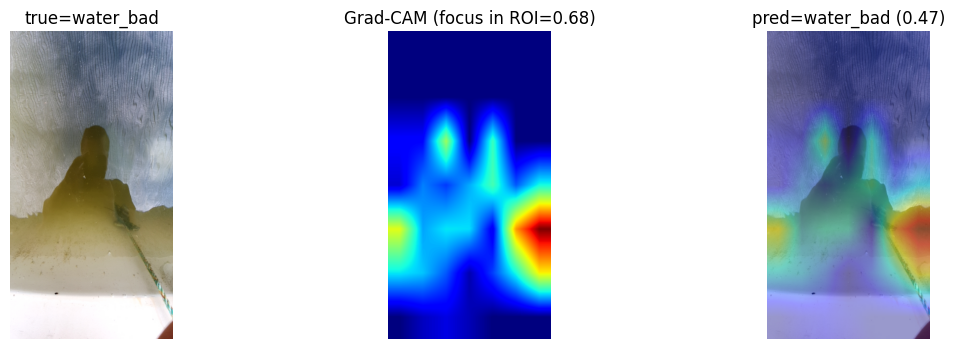

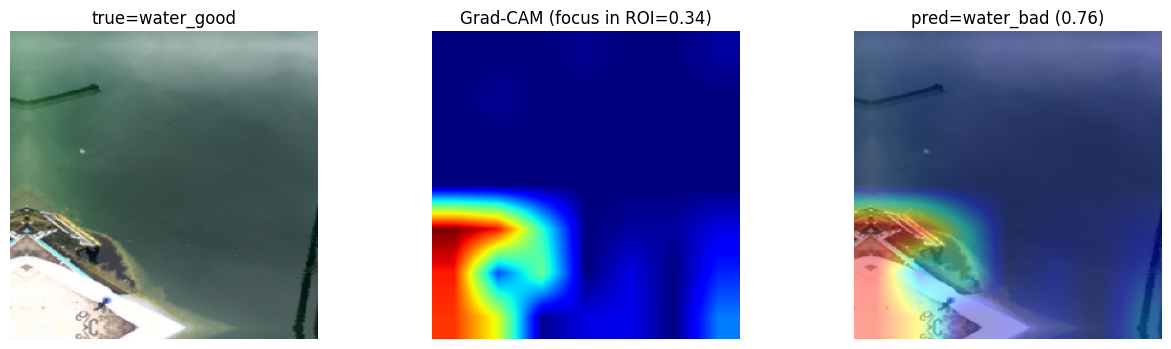

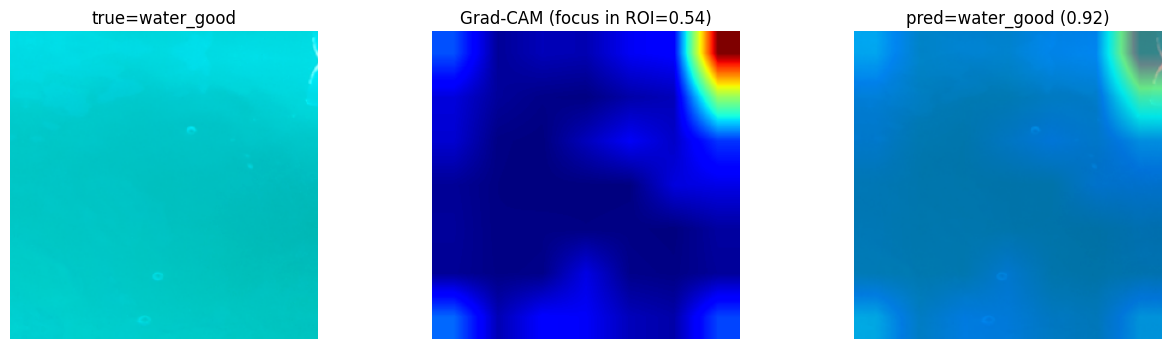

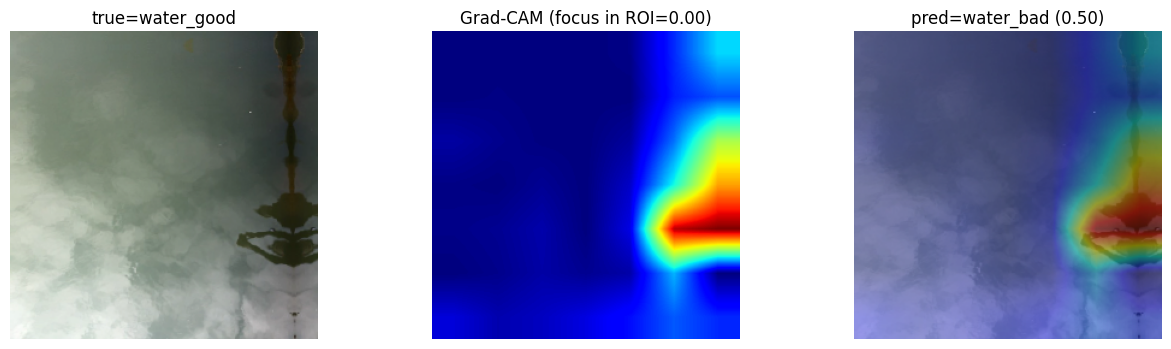

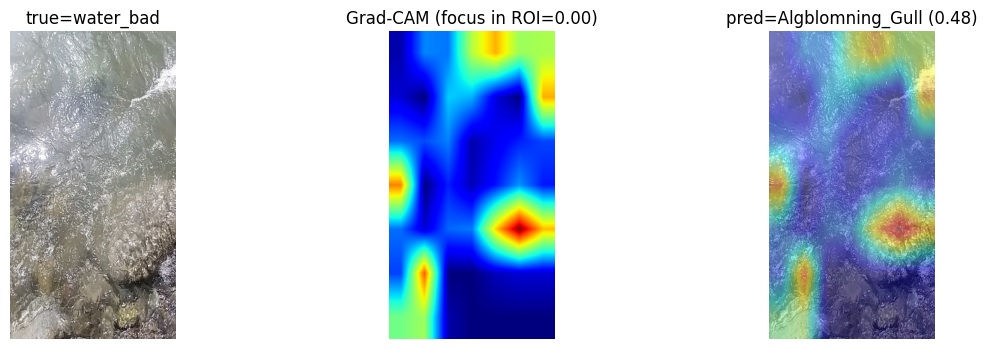

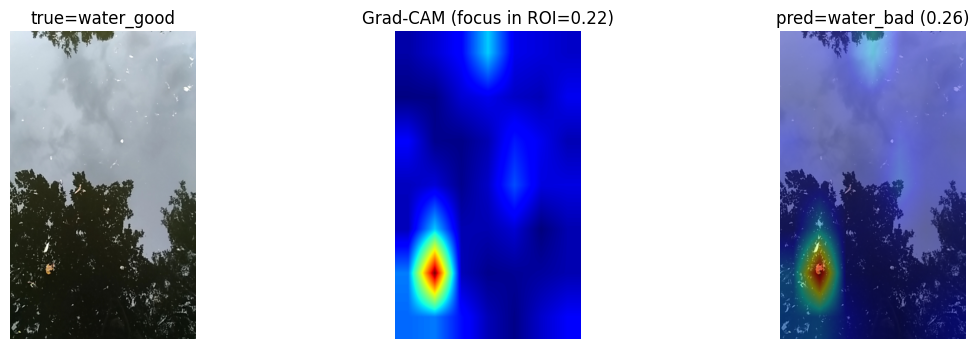

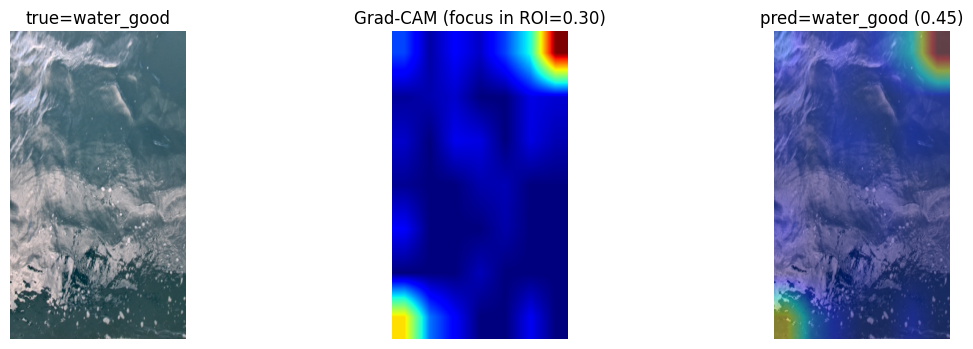

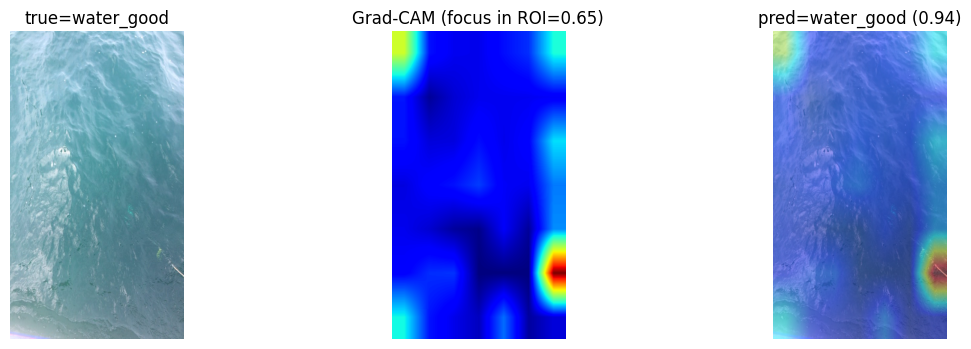

,image_path,true_class,predicted_class,confidence,gradcam_roi_focus,focus_ok
0,/content/RonaAir_CV/01_data/extracted/dataset_...,water_bad,water_bad,0.4708,0.6798,True
1,/content/RonaAir_CV/01_data/extracted/dataset_...,water_good,water_bad,0.7621,0.3383,False
2,/content/RonaAir_CV/01_data/extracted/dataset_...,water_good,water_good,0.9179,0.5380,False
3,/content/RonaAir_CV/01_data/extracted/dataset_...,water_good,water_bad,0.5048,0.0000,False
4,/content/RonaAir_CV/01_data/extracted/dataset_...,water_bad,Algblomning_Gullvik_20230620,0.4830,0.0000,False
5,/content/RonaAir_CV/01_data/extracted/dataset_...,water_good,water_bad,0.2630,0.2218,False
6,/content/RonaAir_CV/01_data/extracted/dataset_...,water_good,water_good,0.4482,0.2968,False
7,/content/RonaAir_CV/01_data/extracted/dataset_...,water_good,water_good,0.9360,0.6469,True


Mean Grad-CAM energy inside the water ROI: 0.340
6 sample(s) focus mostly OUTSIDE the water ROI (background/container/RonaCard/hand/text) -> forwarded to error analysis.


In [24]:
# CELL 18C — ADD-ON: Grad-CAM explainability + water-ROI focus check
gradcam_report={"status":"NOT_AVAILABLE","reason":"No trained classifier"}
gradcam_rows=[]
if TRAINED_KERAS_MODEL is not None and not test_predictions_df.empty:
    gradcam_model,gc_info=build_gradcam_model(TRAINED_KERAS_MODEL)
    if gradcam_model is None:
        gradcam_report={"status":"NOT_AVAILABLE","reason":f"Grad-CAM model could not be built: {gc_info}"}
        print(gradcam_report)
    else:
        print("Grad-CAM target conv layer:",gc_info)
        class_names=list(supervised_eval.get("classes",[]))
        sample=test_predictions_df.sample(min(GRADCAM_SAMPLES,len(test_predictions_df)),random_state=SEED)
        for _,r in sample.iterrows():
            img=cv2.imread(r["image_path"])
            if img is None: continue
            det=detect_ronacard(img); cal,_=calibrate_with_ronacard(img,det); roi=extract_water_roi(cal,det)
            hm,idx,conf=compute_gradcam(gradcam_model,img)
            if hm is None: continue
            focus=gradcam_roi_focus(hm,roi["roi_mask"])
            gradcam_rows.append({"image_path":r["image_path"],
                                 "true_class":r.get("true_class"),
                                 "predicted_class":r.get("predicted_class"),
                                 "confidence":float(r.get("confidence",np.nan)),
                                 "gradcam_roi_focus":focus,
                                 "focus_ok":bool(focus>=GRADCAM_ROI_FOCUS_MIN) if np.isfinite(focus) else False})
            fig,ax=plt.subplots(1,3,figsize=(13,3.6))
            show_bgr(ax[0],img,f"true={str(r.get('true_class'))[:16]}")
            ax[1].imshow(hm,cmap="jet"); ax[1].set_title(f"Grad-CAM (focus in ROI={focus:.2f})"); ax[1].axis("off")
            show_bgr(ax[2],overlay_heatmap(img,hm),f"pred={str(r.get('predicted_class'))[:16]} ({float(r.get('confidence',0)):.2f})")
            plt.tight_layout(); plt.show()
        if gradcam_rows:
            gc_df=pd.DataFrame(gradcam_rows)
            gc_df.to_csv(OUTPUT_DIR/"gradcam_roi_focus.csv",index=False)
            display(gc_df.round(4))
            mean_focus=float(gc_df["gradcam_roi_focus"].mean())
            off_roi=gc_df[~gc_df["focus_ok"]]
            gradcam_report={"status":"OK","n_samples":int(len(gc_df)),
                            "mean_roi_focus":mean_focus,
                            "threshold":GRADCAM_ROI_FOCUS_MIN,
                            "n_below_threshold":int(len(off_roi)),
                            "images_below_threshold":off_roi["image_path"].tolist()[:10]}
            print("Mean Grad-CAM energy inside the water ROI:",fmt_metric(mean_focus,3))
            if len(off_roi):
                print(f"{len(off_roi)} sample(s) focus mostly OUTSIDE the water ROI "
                      "(background/container/RonaCard/hand/text) -> forwarded to error analysis.")
            else:
                print("All inspected heatmaps concentrate on the water ROI.")
else:
    print("Grad-CAM: Not available (classifier was not trained).")
save_json(gradcam_report,OUTPUT_DIR/"gradcam_report.json")

=== ERROR ANALYSIS ===
Correct : 2631  | Wrong : 636

Most frequent confusions (true -> predicted):


n
true_class predicted_class                   
water_good water_bad                      168
           other                          105
water_bad  water_good                      47
water_good Algblomning_檙egrund_20230721    36
           algal_blooms_sweden_2023        33
water_bad  other                           28
           algal_blooms_sweden_2023        20
other      water_bad                       17
water_bad  Algblomning_Gullvik_20230620    13
water_good Algbl_Hummelviksstrand_230815   11


Mean confidence — correct vs wrong:


,mean_confidence,n
correct,0.7085,2631
wrong,0.4378,636



Color-feature comparison, correct vs misclassified:


,visual_score,norm_g,lab_a_star_mean,hsv_s_norm_mean,roi_coverage,ronacard_score
correct,,,,,,
False,22.0789,0.2802,-4.6292,0.3635,0.4230,0.2893
True,29.0926,0.3071,-8.9850,0.3944,0.4996,0.2192


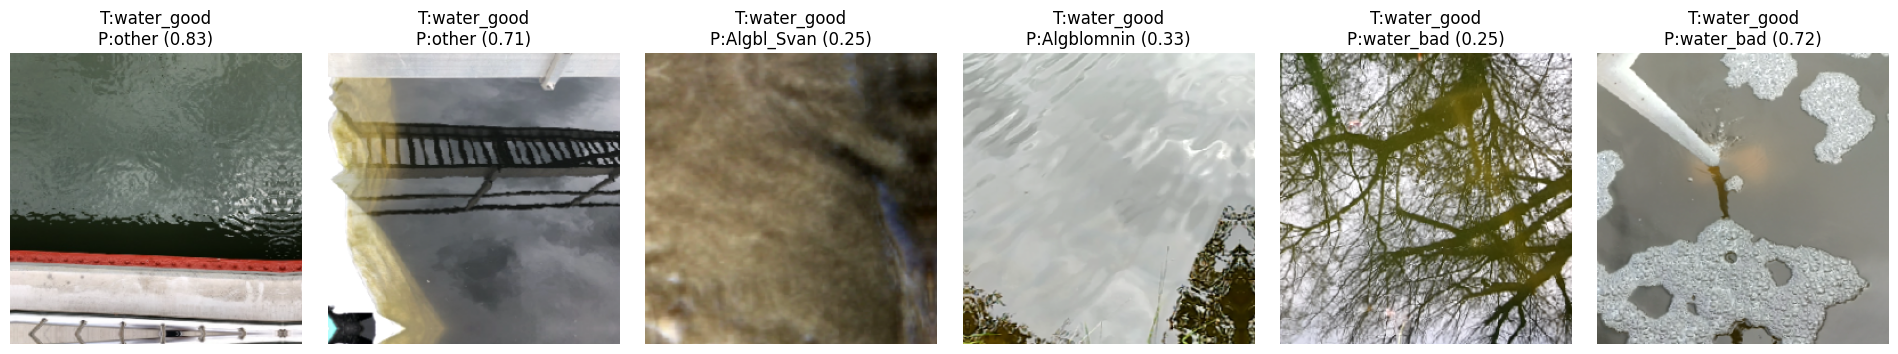

In [25]:
# CELL 18D — ADD-ON: error analysis
error_analysis={"status":"NOT_AVAILABLE","reason":"No test predictions"}
if not test_predictions_df.empty and "correct" in test_predictions_df.columns:
    wrong=test_predictions_df[~test_predictions_df["correct"]].copy()
    right=test_predictions_df[test_predictions_df["correct"]].copy()
    print("=== ERROR ANALYSIS ===")
    print("Correct :",len(right)," | Wrong :",len(wrong))
    if len(wrong):
        print("\nMost frequent confusions (true -> predicted):")
        display(wrong.groupby(["true_class","predicted_class"]).size().sort_values(ascending=False).head(10).to_frame("n"))
        print("\nMean confidence — correct vs wrong:")
        display(pd.DataFrame({"mean_confidence":[right["confidence"].mean() if len(right) else np.nan,
                                                 wrong["confidence"].mean() if len(wrong) else np.nan],
                              "n":[len(right),len(wrong)]},index=["correct","wrong"]).round(4))
        cmp_cols=[c for c in ["visual_score","norm_g","lab_a_star_mean","hsv_s_norm_mean","roi_coverage","ronacard_score"] if c in test_predictions_df.columns]
        if cmp_cols:
            print("\nColor-feature comparison, correct vs misclassified:")
            display(test_predictions_df.groupby("correct")[cmp_cols].mean().round(4))
        show=wrong.head(min(6,len(wrong)))
        fig,ax=plt.subplots(1,len(show),figsize=(3.2*len(show),3.4))
        ax=np.atleast_1d(ax)
        for a,(_,r) in zip(ax,show.iterrows()):
            show_bgr(a,cv2.imread(r["image_path"]),f"T:{str(r['true_class'])[:10]}\nP:{str(r['predicted_class'])[:10]} ({r['confidence']:.2f})")
        plt.tight_layout(); plt.show()
        wrong.to_csv(OUTPUT_DIR/"misclassified_samples.csv",index=False)
    error_analysis={"status":"OK","n_correct":int(len(right)),"n_wrong":int(len(wrong)),
                    "error_rate":float(len(wrong)/max(len(test_predictions_df),1)),
                    "mean_confidence_correct":float(right["confidence"].mean()) if len(right) else float("nan"),
                    "mean_confidence_wrong":float(wrong["confidence"].mean()) if len(wrong) else float("nan"),
                    "gradcam_off_roi_samples":gradcam_report.get("n_below_threshold","Not available"),
                    "low_quality_in_test":int((test_predictions_df.get("roi_coverage",pd.Series(dtype=float))<0.5).sum())}
else:
    print("Error analysis: Not available (no test predictions).")
save_json(error_analysis,OUTPUT_DIR/"error_analysis.json")

In [26]:
# CELL 18E — ADD-ON: ablation study (only when the dataset supports it)
# A. Image CNN (MobileNetV3 embedding) | B. RGB features | C. CNN + RGB | D. CNN + RGB + HSV + LAB
ablation_results=[]
ablation_status="NOT_AVAILABLE"
if RUN_ABLATION and features_label_source and features_label_source in split_df.columns:
    rgb_only=[c for c in FEATURE_GROUPS["A_rgb"] if c in split_df.columns]
    all_color=[c for c in FEATURE_GROUPS["D_rgb_hsv_lab"] if c in split_df.columns]
    blocks=[]
    if EMB_MATRIX is not None:
        blocks.append(("A_image_cnn",[],EMB_MATRIX,EMB_INDEX))
    blocks.append(("B_rgb_features",rgb_only,None,None))
    if EMB_MATRIX is not None:
        blocks.append(("C_cnn_plus_rgb",rgb_only,EMB_MATRIX,EMB_INDEX))
        blocks.append(("D_cnn_rgb_hsv_lab",all_color,EMB_MATRIX,EMB_INDEX))
    else:
        blocks.append(("D_rgb_hsv_lab_only",all_color,None,None))
        print("MobileNet embeddings unavailable -> CNN-based ablation arms are reported as Not available.")
    for name,cols,mat,idx in blocks:
        res=sklearn_block_experiment(split_df,features_label_source,cols,extra_matrix=mat,extra_index=idx,name=name)
        ablation_results.append(res)
    abl_df=pd.DataFrame(ablation_results)
    display(abl_df)
    abl_df.to_csv(OUTPUT_DIR/"ablation_results.csv",index=False)
    ablation_status="OK" if (abl_df["status"]=="OK").any() else "NOT_AVAILABLE"
    print("\nNote: the ablation uses a linear probe (logistic regression, class-balanced) on frozen features "
          "so that the four feature blocks are compared under identical conditions. "
          "The main deployed model remains the fine-tuned MobileNetV3-Small of CELL 17.")
    print("Silhouette Score in this table describes FEATURE SEPARATION, not accuracy.")
else:
    print("Ablation: Not available (RUN_ABLATION=False or no validated label source).")
save_json({"status":ablation_status,"results":ablation_results},OUTPUT_DIR/"ablation_report.json")

,block,status,n_features,accuracy,macro_f1,weighted_f1,silhouette_score
0,A_image_cnn,OK,576,0.929293,0.413368,0.929628,-0.110424
1,B_rgb_features,OK,29,0.303949,0.033904,0.434035,-0.572448
2,C_cnn_plus_rgb,OK,605,0.931742,0.517135,0.932120,-0.112017
3,D_cnn_rgb_hsv_lab,OK,634,0.933272,0.517523,0.933476,-0.109084



Note: the ablation uses a linear probe (logistic regression, class-balanced) on frozen features so that the four feature blocks are compared under identical conditions. The main deployed model remains the fine-tuned MobileNetV3-Small of CELL 17.
Silhouette Score in this table describes FEATURE SEPARATION, not accuracy.


In [27]:
# CELL 19 — Model export (KEPT + EXTENDED: INT8 quantization for offline Android deployment)
export_results=[]
INT8_CLASSIFIER_PATH=None

# Feature extractor export is independent of labels and is the deployable visual backbone.
if feature_model is not None:
    feature_model_path=MODEL_DIR/"ronair_mobilenetv3_small_feature_extractor.keras"
    feature_model.save(feature_model_path)
    try:
        res=export_tflite(feature_model,MODEL_DIR/"ronair_mobilenetv3_small_feature_extractor.tflite",quantize="dynamic")
        export_results.append({"artifact":"feature_extractor_tflite","status":"OK",**res})
    except Exception as e:
        export_results.append({"artifact":"feature_extractor_tflite","status":"FAILED","error":repr(e)})

if TRAINED_KERAS_MODEL is not None:
    classifier_path=MODEL_DIR/"ronair_cv_classifier.keras"
    TRAINED_KERAS_MODEL.save(classifier_path)
    try:
        res=export_tflite(TRAINED_KERAS_MODEL,MODEL_DIR/"ronair_cv_classifier.tflite",quantize="dynamic")
        export_results.append({"artifact":"classifier_tflite","status":"OK",**res})
    except Exception as e:
        export_results.append({"artifact":"classifier_tflite","status":"FAILED","error":repr(e)})

    # ADD-ON: full INT8 quantization (target: MobileNetV3-Small -> INT8 TFLite -> offline Android)
    if RUN_INT8_QUANTIZATION:
        rep_paths=split_df[split_df.split=="train"]["image_path"].astype(str).tolist()[:REPRESENTATIVE_SAMPLES]
        if not rep_paths:
            rep_paths=features_df["image_path"].astype(str).tolist()[:REPRESENTATIVE_SAMPLES]
        try:
            int8_path=MODEL_DIR/"ronair_cv_classifier_int8.tflite"
            res=export_tflite(TRAINED_KERAS_MODEL,int8_path,quantize="int8",
                              representative_paths=rep_paths,int8_io=INT8_IO)
            INT8_CLASSIFIER_PATH=int8_path if res.get("quantization")=="int8" else None
            export_results.append({"artifact":"classifier_tflite_int8","status":"OK",
                                   "representative_samples":len(rep_paths),**res})
        except Exception as e:
            export_results.append({"artifact":"classifier_tflite_int8","status":"FAILED","error":repr(e)})
else:
    print("Classifier export: Not available (no trained classifier).")

export_df=pd.DataFrame(export_results)
display(export_df)
export_df.to_csv(OUTPUT_DIR/"export_results.csv",index=False)

Saved artifact at '/tmp/tmp_keqzw9o'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='image')
Output Type:
  TensorSpec(shape=(None, 576), dtype=tf.float32, name=None)
Captures:
  137481995021840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137481995022416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137481995022224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137481995026256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137481995021648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137481995022032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137479094393296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137479094391952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137481995026064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137481995016080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137479094400784: Te

/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


,artifact,status,path,bytes,quantization,int8_io,converter_source,n_failed_attempts,representative_samples
0,feature_extractor_tflite,OK,/content/RonaAir_CV/04_models/ronair_mobilenet...,1111376,dynamic,False,keras,0,NaN
1,classifier_tflite,OK,/content/RonaAir_CV/04_models/ronair_cv_classi...,1128880,dynamic,False,keras,0,NaN
2,classifier_tflite_int8,OK,/content/RonaAir_CV/04_models/ronair_cv_classi...,1237360,int8,False,keras,0,100.0


In [28]:
# CELL 19B — ADD-ON: deployment readiness (input size, model size, inference time, INT8 status, offline)
deployment_readiness={"input_size":[1,IMAGE_SIZE[0],IMAGE_SIZE[1],3],
                      "backbone":"MobileNetV3-Small (ImageNet weights, fine-tuned tail)",
                      "preprocessing":"tf.keras.applications.mobilenet_v3.preprocess_input (inside the graph)",
                      "offline_capable":True,
                      "offline_note":"TFLite runs fully on-device; no network call is needed at inference time."}

def _size_mb(p):
    p=Path(p)
    return round(p.stat().st_size/1024**2,3) if p.exists() else None

artifacts={
    "keras_classifier":MODEL_DIR/"ronair_cv_classifier.keras",
    "tflite_classifier_dynamic":MODEL_DIR/"ronair_cv_classifier.tflite",
    "tflite_classifier_int8":MODEL_DIR/"ronair_cv_classifier_int8.tflite",
    "tflite_feature_extractor":MODEL_DIR/"ronair_mobilenetv3_small_feature_extractor.tflite",
}
sizes={k:_size_mb(v) for k,v in artifacts.items()}
deployment_readiness["model_size_mb"]={k:(v if v is not None else "Not available") for k,v in sizes.items()}

bench={}
for key in ["tflite_classifier_int8","tflite_classifier_dynamic","tflite_feature_extractor"]:
    p=artifacts[key]
    bench[key]=benchmark_tflite(p) if Path(p).exists() else {"status":"NOT_AVAILABLE","reason":"artifact missing"}
deployment_readiness["inference_benchmark"]=bench
int8_row=[r for r in export_results if r.get("artifact")=="classifier_tflite_int8"]
deployment_readiness["int8_status"]=(int8_row[0].get("quantization") if int8_row else "Not available")
deployment_readiness["quantization_pipeline"]="MobileNetV3-Small -> TFLite -> INT8 -> offline Android"

print("=== DEPLOYMENT READINESS ===")
print("Input size            :",deployment_readiness["input_size"])
print("Backbone              :",deployment_readiness["backbone"])
for k,v in deployment_readiness["model_size_mb"].items():
    print(f"Model size {k:28s}: {v if v!='Not available' else 'Not available'} MB")
for k,v in bench.items():
    if v.get("status")=="OK":
        print(f"Inference {k:29s}: {v['mean_ms']:.2f} ms/image (median {v['median_ms']:.2f} ms, dtype {v['input_dtype']})")
    else:
        print(f"Inference {k:29s}: Not available ({v.get('reason','')[:80]})")
print("INT8 TFLite status    :",deployment_readiness["int8_status"])
print("Offline capability    :","YES — on-device TFLite inference, no server required")
print("NOTE: latency measured on this Colab CPU/GPU runtime, not on a target Android device.")
save_json(deployment_readiness,OUTPUT_DIR/"deployment_readiness.json")
display(pd.DataFrame([{ "input_size":str(deployment_readiness["input_size"]),
                        "int8_status":deployment_readiness["int8_status"],
                        "offline_capable":deployment_readiness["offline_capable"]}]))

/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


=== DEPLOYMENT READINESS ===
Input size            : [1, 224, 224, 3]
Backbone              : MobileNetV3-Small (ImageNet weights, fine-tuned tail)
Model size keras_classifier            : 8.727 MB
Model size tflite_classifier_dynamic   : 1.077 MB
Model size tflite_classifier_int8      : 1.18 MB
Model size tflite_feature_extractor    : 1.06 MB
Inference tflite_classifier_int8       : Not available (RuntimeError('failed to create XNNPACK runtimeNode number 119 (TfLiteXNNPackDele)
Inference tflite_classifier_dynamic    : 5.01 ms/image (median 4.96 ms, dtype float32)
Inference tflite_feature_extractor     : 4.93 ms/image (median 4.78 ms, dtype float32)
INT8 TFLite status    : int8
Offline capability    : YES — on-device TFLite inference, no server required
NOTE: latency measured on this Colab CPU/GPU runtime, not on a target Android device.


,input_size,int8_status,offline_capable
0,"[1, 224, 224, 3]",int8,True


In [29]:
# CELL 20 — Reproducibility metadata + Android runtime configuration (KEPT + EXTENDED)
metadata={
    "project":"RonaAir",
    "module":"Computer Vision — Non-Contact Visual Screening System",
    "dataset_sources":[{"name":s["name"],"url":s["url"]} for s in DATASET_SPECS],
    "download_manifest":DOWNLOADS,
    "n_images_inventory":int(len(inventory_df)),
    "n_feature_rows":int(len(features_df)),
    "label_audit":label_audit,
    "class_balance_report":class_balance_report,
    "leakage_report":leakage_report,
    "split_meta":split_meta,
    "mobilenet_result":mobilenet_result,
    "classical_report":classical_report,
    "tf_training_report":tf_training_report,
    "supervised_evaluation":supervised_eval,
    "silhouette_report":silhouette_report,
    "gradcam_report":gradcam_report,
    "error_analysis":error_analysis,
    "ablation":{"status":ablation_status,"results":ablation_results},
    "deployment_readiness":deployment_readiness,
    "visual_score_definition":{"range":[0,100],"weights":VISUAL_SCORE_WEIGHTS,
                               "components":["green chromaticity excess","CIELAB greenness","HSV saturation","L* based density"],
                               "note":"deterministic color descriptor, not a probability or chemical measurement"},
    "export_results":export_results,
    "runtime":{
        "python":platform.python_version(),
        "tensorflow":tf.__version__,
        "opencv":cv2.__version__,
        "gpu_available":GPU_AVAILABLE,
    },
    "decision_fusion_interface":{
        "cv_outputs":["color_class","confidence","visual_score_0_100","mean_rgb","normalized_rgb","hsv","cielab"],
        "sensor_inputs_expected":["suhu","pH","TDS","DO_est"],
        "note":"Computer Vision does not stand alone; it is one input of the RonaAir Decision Fusion layer."
    },
    "scientific_limitations":[
        "smartphone image is not a direct chemical measurement",
        "color features are visual indicators, not direct cyanobacteria/cyanotoxin/chlorophyll-a/DO/turbidity measurements",
        "the model performs visual screening of water color and density, it does not identify algal species or toxins",
        "RonaCard heuristic is a conservative fallback and does not eliminate all camera/lighting variation",
        "folder names are not treated as ground truth unless independently validated by the user",
        "external validation is required before field performance claims"
    ]
}
save_json(metadata,OUTPUT_DIR/"model_metadata.json")
save_json(metadata,MODEL_DIR/"model_metadata.json")

android_config={
    "model_type":"MobileNetV3-Small",
    "feature_extractor_tflite":str(MODEL_DIR/"ronair_mobilenetv3_small_feature_extractor.tflite"),
    "classifier_tflite":str(MODEL_DIR/"ronair_cv_classifier.tflite") if TRAINED_KERAS_MODEL is not None else None,
    "classifier_tflite_int8":str(INT8_CLASSIFIER_PATH) if INT8_CLASSIFIER_PATH else None,
    "class_names":supervised_eval.get("classes","Not available"),
    "input_shape":[1,224,224,3],
    "preprocessing":"tf.keras.applications.mobilenet_v3.preprocess_input",
    "color_calibration":"RonaCard when detected; unchanged fallback otherwise",
    "post_processing":["color_class","confidence","visual_score_0_100","rgb/hsv/lab block"],
    "scientific_status":"prototype/research artifact; not a diagnostic tool"
}
save_json(android_config,CONFIG_DIR/"android_deployment_runtime.json")
display(pd.DataFrame([{k:(str(v)[:60] if v is not None else "None") for k,v in android_config.items()}]))

,model_type,feature_extractor_tflite,classifier_tflite,classifier_tflite_int8,class_names,input_shape,preprocessing,color_calibration,post_processing,scientific_status
0,MobileNetV3-Small,/content/RonaAir_CV/04_models/ronair_mobilenet...,/content/RonaAir_CV/04_models/ronair_cv_classi...,/content/RonaAir_CV/04_models/ronair_cv_classi...,"['Algbl_Bur”n_™vik_230813', 'Algbl_F„rnsvik_Kr...","[1, 224, 224, 3]",tf.keras.applications.mobilenet_v3.preprocess_...,RonaCard when detected; unchanged fallback oth...,"['color_class', 'confidence', 'visual_score_0_...",prototype/research artifact; not a diagnostic ...


In [30]:
# CELL 21 — Final integrity check (KEPT + EXTENDED with the new add-on artifacts)
checks=[]
required=[
    OUTPUT_DIR/"download_manifest.csv",
    OUTPUT_DIR/"dataset_inventory.csv",
    OUTPUT_DIR/"quality_report.csv",
    OUTPUT_DIR/"visual_features.csv",
    OUTPUT_DIR/"data_split.csv",
    OUTPUT_DIR/"label_mapping_table.csv",
    OUTPUT_DIR/"leakage_report.json",
    OUTPUT_DIR/"silhouette_report.json",
    OUTPUT_DIR/"per_image_output.csv",
    OUTPUT_DIR/"deployment_readiness.json",
    OUTPUT_DIR/"model_metadata.json",
]
for p in required:
    checks.append({"artifact":str(p),"exists":p.exists(),"size_bytes":p.stat().st_size if p.exists() else 0})
if feature_model is not None:
    for p in [MODEL_DIR/"ronair_mobilenetv3_small_feature_extractor.keras", MODEL_DIR/"ronair_mobilenetv3_small_feature_extractor.tflite"]:
        checks.append({"artifact":str(p),"exists":p.exists(),"size_bytes":p.stat().st_size if p.exists() else 0})
if TRAINED_KERAS_MODEL is not None:
    for p in [MODEL_DIR/"ronair_cv_classifier.keras", MODEL_DIR/"ronair_cv_classifier.tflite"]:
        checks.append({"artifact":str(p),"exists":p.exists(),"size_bytes":p.stat().st_size if p.exists() else 0})
    # optional artifacts are reported but never fail the run
    for p in [MODEL_DIR/"ronair_cv_classifier_int8.tflite", OUTPUT_DIR/"confusion_matrix.csv", OUTPUT_DIR/"classification_report.csv"]:
        print(f"[optional] {p.name}: {'present' if p.exists() else 'Not available'}")

check_df=pd.DataFrame(checks)
display(check_df)
if not bool(check_df["exists"].all()):
    missing=check_df.loc[~check_df["exists"],"artifact"].tolist()
    raise RuntimeError(f"Final integrity check failed. Missing artifacts: {missing}")

print("\nRonaAir CV pipeline completed successfully.")
print("Outputs:",OUTPUT_DIR)
print("Models:",MODEL_DIR)

[optional] ronair_cv_classifier_int8.tflite: present
[optional] confusion_matrix.csv: present
[optional] classification_report.csv: present


,artifact,exists,size_bytes
0,/content/RonaAir_CV/05_outputs/download_manife...,True,309
1,/content/RonaAir_CV/05_outputs/dataset_invento...,True,6539326
2,/content/RonaAir_CV/05_outputs/quality_report.csv,True,4066285
3,/content/RonaAir_CV/05_outputs/visual_features...,True,33465875
4,/content/RonaAir_CV/05_outputs/data_split.csv,True,33881218
5,/content/RonaAir_CV/05_outputs/label_mapping_t...,True,1409
6,/content/RonaAir_CV/05_outputs/leakage_report....,True,103
7,/content/RonaAir_CV/05_outputs/silhouette_repo...,True,384
8,/content/RonaAir_CV/05_outputs/per_image_outpu...,True,766794
9,/content/RonaAir_CV/05_outputs/deployment_read...,True,1456



RonaAir CV pipeline completed successfully.
Outputs: /content/RonaAir_CV/05_outputs
Models: /content/RonaAir_CV/04_models


In [31]:
# CELL 22 — ADD-ON: FINAL REPORT (1 Model Performance | 2 Color Analysis | 3 Error Analysis | 4 Explainability | 5 Deployment Readiness)
# Every number below is read back from the actual execution above. Anything that could
# not be computed is printed as "Not available" together with the reason.
line="="*78

print(line); print("RONAAIR — COMPUTER VISION FINAL REPORT"); print(line)

print("\n1. MODEL PERFORMANCE")
print("-"*78)
print("Main model            : MobileNetV3-Small (ImageNet) + Dropout + Dense softmax")
print("Training status       :",tf_training_report.get("status"),tf_training_report.get("reason",""))
print("Classes               :",supervised_eval.get("classes",tf_training_report.get("classes","Not available")))
print("Train/Val/Test images :",tf_training_report.get("train","Not available"),"/",
      tf_training_report.get("val","Not available"),"/",tf_training_report.get("test","Not available"))
if supervised_eval.get("status")=="OK":
    print("Accuracy              :",fmt_metric(supervised_eval.get("accuracy")))
    print("Macro Precision       :",fmt_metric(supervised_eval.get("macro_precision")))
    print("Macro Recall          :",fmt_metric(supervised_eval.get("macro_recall")))
    print("Macro F1              :",fmt_metric(supervised_eval.get("macro_f1")))
    print("Weighted F1           :",fmt_metric(supervised_eval.get("weighted_f1")))
    print("Confusion matrix      : saved to",OUTPUT_DIR/"confusion_matrix.csv")
else:
    print("Classification metrics: Not available —",supervised_eval.get("reason","classifier not trained"))
if ablation_status=="OK":
    print("\nAblation (linear probe on frozen features):")
    display(pd.DataFrame(ablation_results)[["block","status","n_features","accuracy","macro_f1","weighted_f1","silhouette_score"]].round(4))
else:
    print("Ablation              : Not available")

print("\n2. COLOR ANALYSIS")
print("-"*78)
if not rgb_profile.empty:
    print("Per-class ROI color profile (actual means):")
    display(rgb_profile)
else:
    print("Per-class color profile: Not available (no validated labels).")
print("COLOR FEATURE SEPARATION — Silhouette Score (NOT accuracy):")
for key,title in [("rgb_features","RGB/HSV/LAB features vs class"),
                  ("embedding","MobileNetV3 embedding vs class"),
                  ("kmeans_rgb","KMeans on color features")]:
    r=silhouette_report.get(key,{})
    if r.get("status")=="OK":
        s=r.get("silhouette_score")
        print(f"  {title:38s}: {fmt_metric(s)}  ({interpret_silhouette(s)})")
    else:
        print(f"  {title:38s}: Not available ({r.get('reason','')[:60]})")
print("Visual Score          : 0-100, deterministic weighted color descriptor (see CELL 18B).")
if "visual_score" in features_df.columns:
    print("  dataset mean VS     :",fmt_metric(features_df['visual_score'].mean(),2),
          "| min",fmt_metric(features_df['visual_score'].min(),2),
          "| max",fmt_metric(features_df['visual_score'].max(),2))

print("\n3. ERROR ANALYSIS")
print("-"*78)
if error_analysis.get("status")=="OK":
    print("Correct / Wrong       :",error_analysis["n_correct"],"/",error_analysis["n_wrong"])
    print("Error rate            :",fmt_metric(error_analysis["error_rate"]))
    print("Mean confidence correct/wrong:",fmt_metric(error_analysis["mean_confidence_correct"],3),"/",
          fmt_metric(error_analysis["mean_confidence_wrong"],3))
    print("Grad-CAM off-ROI cases:",error_analysis.get("gradcam_off_roi_samples","Not available"))
    print("Data leakage status   :",leakage_report.get("status"))
else:
    print("Error analysis        : Not available —",error_analysis.get("reason",""))

print("\n4. EXPLAINABILITY")
print("-"*78)
if gradcam_report.get("status")=="OK":
    print("Grad-CAM samples      :",gradcam_report["n_samples"])
    print("Mean energy in water ROI:",fmt_metric(gradcam_report["mean_roi_focus"],3),
          f"(threshold {gradcam_report['threshold']})")
    print("Samples focusing outside the water ROI:",gradcam_report["n_below_threshold"])
    print("Interpretation        : a high ROI-focus means the network reacts to the water surface, "
          "not to the container, hand, RonaCard, text or watermark.")
else:
    print("Grad-CAM              : Not available —",gradcam_report.get("reason",""))

print("\n5. DEPLOYMENT READINESS")
print("-"*78)
print("Input size            :",deployment_readiness["input_size"])
print("Model sizes (MB)      :",deployment_readiness["model_size_mb"])
for k,v in deployment_readiness["inference_benchmark"].items():
    print(f"  latency {k:28s}:",f"{v['mean_ms']:.2f} ms" if v.get("status")=="OK" else "Not available")
print("INT8 TFLite status    :",deployment_readiness["int8_status"])
print("Offline capability    : YES (on-device TFLite)")
print("Pipeline              :",deployment_readiness["quantization_pipeline"])

print("\n"+line)
print("SCIENTIFIC FRAMING")
print(line)
print("AI melakukan SKRINING VISUAL terhadap karakteristik warna dan kepekatan air.")
print("AI TIDAK mendeteksi spesies alga dan TIDAK membuktikan keberadaan toksin.")
print("Perubahan warna adalah indikator visual awal untuk sistem peringatan dini dan perlu")
print("dikonfirmasi dengan parameter sensor (suhu, pH, TDS, DO_est) atau uji laboratorium.")
print("Output CV (Color Class + Confidence + Visual Score + RGB/HSV/LAB) adalah SALAH SATU")
print("input Decision Fusion RonaAir, bukan keputusan akhir yang berdiri sendiri.")
print(line)

RONAAIR — COMPUTER VISION FINAL REPORT

1. MODEL PERFORMANCE
------------------------------------------------------------------------------
Main model            : MobileNetV3-Small (ImageNet) + Dropout + Dense softmax
Training status       : OK 
Classes               : ['Algbl_Bur”n_™vik_230813', 'Algbl_F„rnsvik_Kramfors_230822', 'Algbl_F„sk„r_Hudiksvall_230814', 'Algbl_Hummelviksstrand_230815', 'Algbl_Lingar”viken_230814', 'Algbl_L”v”udden_Ume†_230815', 'Algbl_L”v”udden_Ume†_230819', 'Algbl_M†viken_Kramfors_230821', 'Algbl_Strandpromenaden_Hudiksvall_230813', 'Algbl_Svanaviken_檝ik_230814', 'Algbl_T„rn”gern_Holmsund_230815', 'Algbl_檝iks stadshamn_230814', 'Algblomning_Bj”rk”fj„rden_Sundsvall_230724', 'Algblomning_Branth„ll_S”dehamn_20230903', 'Algblomning_Finnh„llan_K†gn„sudden_230726', 'Algblomning_Gullvik_20230620', 'Algblomning_Holmsund_20230828', 'Algblomning_Kalix_Stor派amn_230712', 'Algblomning_Lill-Renholmsgrundet_Lule†_230714', 'Algblomning_Ostn„sudden_20230628', 'Algblomning_S

,block,status,n_features,accuracy,macro_f1,weighted_f1,silhouette_score
0,A_image_cnn,OK,576,0.9293,0.4134,0.9296,-0.1104
1,B_rgb_features,OK,29,0.3039,0.0339,0.4340,-0.5724
2,C_cnn_plus_rgb,OK,605,0.9317,0.5171,0.9321,-0.1120
3,D_cnn_rgb_hsv_lab,OK,634,0.9333,0.5175,0.9335,-0.1091



2. COLOR ANALYSIS
------------------------------------------------------------------------------
Per-class ROI color profile (actual means):


,Class,n,Mean R,Mean G,Mean B,r,g,b,Hue(deg),Saturation,Value,L*,a*,b*,Visual Score
0,Algbl_Bur”n_™vik_230813,3,120.8664,117.2859,64.4539,0.4004,0.3947,0.2049,60.2623,0.5133,0.5025,48.1656,-6.3913,29.2881,40.4733
1,Algbl_F„rnsvik_Kramfors_230822,3,134.1771,134.2956,125.8148,0.3480,0.3436,0.3083,121.3610,0.1990,0.5625,55.3072,-1.2112,4.8391,12.4833
2,Algbl_F„sk„r_Hudiksvall_230814,3,137.0103,123.2678,116.3424,0.3709,0.3294,0.2997,73.7205,0.2739,0.5665,52.4525,4.7329,6.2831,9.2767
3,Algbl_Hummelviksstrand_230815,3,35.4208,38.9634,41.9032,0.1062,0.1120,0.1151,143.2461,0.2719,0.5226,47.9906,-1.0947,-5.4596,4.4333
4,Algbl_Lingar”viken_230814,5,138.2505,136.7330,131.7683,0.3292,0.3439,0.3270,153.6211,0.3149,0.6201,56.8873,0.9846,3.8632,18.7400
5,Algbl_L”v”udden_Ume†_230815,2,132.2073,124.0652,94.3971,0.3729,0.3553,0.2718,80.9389,0.2876,0.5263,51.7523,-1.4360,16.9561,18.1850
6,Algbl_L”v”udden_Ume†_230819,2,105.8134,127.7877,148.9685,0.2954,0.3371,0.3674,162.6913,0.4161,0.6393,52.3613,0.0651,-12.4550,15.4800
7,Algbl_M†viken_Kramfors_230821,5,141.0933,141.8161,122.3400,0.3531,0.3469,0.2999,128.6911,0.2125,0.5836,58.2028,-3.4346,10.4242,15.9760
8,Algbl_Strandpromenaden_Hudiksvall_230813,4,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,0.0000
9,Algbl_Svanaviken_檝ik_230814,3,120.2414,139.8466,147.7097,0.2771,0.3463,0.3686,171.7821,0.4511,0.6592,56.7224,-2.0108,-6.1453,17.5200


COLOR FEATURE SEPARATION — Silhouette Score (NOT accuracy):
  RGB/HSV/LAB features vs class         : -0.3381  (negatif: banyak sampel lebih dekat ke cluster lain)
  MobileNetV3 embedding vs class        : -0.0869  (negatif: banyak sampel lebih dekat ke cluster lain)
  KMeans on color features              : 0.2163  (cluster saling overlap)
Visual Score          : 0-100, deterministic weighted color descriptor (see CELL 18B).
  dataset mean VS     : 27.40 | min 0.00 | max 93.95

3. ERROR ANALYSIS
------------------------------------------------------------------------------
Correct / Wrong       : 2631 / 636
Error rate            : 0.1947
Mean confidence correct/wrong: 0.709 / 0.438
Grad-CAM off-ROI cases: 6
Data leakage status   : OK

4. EXPLAINABILITY
------------------------------------------------------------------------------
Grad-CAM samples      : 8
Mean energy in water ROI: 0.340 (threshold 0.6)
Samples focusing outside the water ROI: 6
Interpretation        : a high ROI-focus 

# CELL 23 — Interpretasi ilmiah dan batasan

1. **Feature extractor output** adalah model visual lightweight yang dapat digunakan sebagai backbone/embedding untuk modul Android.
2. **Classifier TFLite** dihasilkan ketika `LABEL_VALIDATED=True` dan audit label pada CELL 7 menghasilkan minimal dua kelas. Gate ini tetap ada agar model tidak dilatih pada label folder yang belum pernah diperiksa; keputusan validasi tetap berada di tangan pengguna dan tercatat di `label_audit.json`.
3. Jika kedua ZIP tidak menyediakan label yang dapat dipakai, notebook tetap selesai dan menghasilkan **visual features + MobileNet embeddings + unsupervised clustering + feature-extractor TFLite**; seluruh metrik klasifikasi dilaporkan sebagai **"Not available"**, bukan angka karangan.
4. **Computer Vision RonaAir = Non-Contact Visual Screening System.** Modul ini menganalisis warna dan kepekatan air, bukan taksonomi alga dan bukan kadar toksin. Kalimat yang benar: *"AI melakukan skrining visual terhadap karakteristik warna dan kepekatan air"*. Kalimat yang salah: *"AI mendeteksi spesies alga"*.
5. Perubahan warna adalah **indikator visual awal** yang dapat menjadi bagian dari sistem peringatan dini dan **perlu dikonfirmasi** dengan parameter sensor atau pemeriksaan laboratorium bila diperlukan.
6. **RonaCard** hanya dipakai sebagai referensi kalibrasi warna, bukan fitur klasifikasi. ROI RonaCard di-*mask out* sebelum ekstraksi fitur air. Asumsi yang dipakai: kartu bersifat netral (low saturation), pencahayaan relatif seragam dalam satu foto, dan koreksi dilakukan dengan penskalaan kanal berbasis median patch. Variasi kamera smartphone (white balance otomatis, HDR, exposure, refleksi permukaan) **tidak sepenuhnya hilang** dan tetap menjadi limitasi.
7. **Silhouette Score bukan accuracy.** Nilai tersebut hanya menggambarkan kualitas separasi kelompok pada ruang fitur warna atau embedding: mendekati +1 berarti cluster kompak dan terpisah, sekitar 0 berarti overlap, negatif berarti banyak sampel lebih dekat ke cluster lain. Metrik klasifikasi tetap Accuracy/Precision/Recall/F1/Confusion Matrix.
8. **Visual Score (0–100)** adalah deskriptor warna deterministik dengan bobot tetap yang dicetak di CELL 18B — bukan probabilitas, bukan accuracy, dan bukan hasil pengukuran kimia.
9. Model final RonaAir tetap harus dipadukan dengan cabang sensor (suhu, pH, EC/TDS, dan estimasi DO) melalui **Decision Fusion**. Foto saja bukan dasar yang cukup untuk diagnosis cyanobacteria/cyanotoxin.

# CELL 24 — Ringkasan perubahan cell-by-cell (DIPERTAHANKAN vs DITAMBAHKAN)

| Cell | Status | Keterangan |
|---|---|---|
| CELL 1 (markdown) | **DIPERTAHANKAN + catatan** | Deskripsi pipeline; ditambah ringkasan add-on. |
| CELL 2 (core) | **DIPERTAHANKAN + EXTEND** | Semua import, konfigurasi, `sha256_file`, `safe_extract_zip`, `image_paths`, `build_dataset_inventory`, `audit_quality_for_paths`, `detect_ronacard`, `calibrate_with_ronacard`, `extract_water_roi`, `create_mobilenet_feature_extractor`, `build_classifier`, `supervised_ds`, `create_data_split`, `classical_experiments`, `clustering_report` **tidak diubah**. `extract_visual_features` diperluas (semua key lama tetap ada + blok RGB/normalized RGB/HSV derajat/CIELAB L\*a\*b\*/percentile/histogram/Visual Score). Ditambahkan: `compute_visual_score`, `assign_group_ids`, `create_group_aware_split`, `check_split_leakage`, `compute_class_weights`, `silhouette_from_matrix`, `load_embedding_matrix`, `pca_2d`, `build_gradcam_model`, `compute_gradcam`, `gradcam_roi_focus`, `overlay_heatmap`, `benchmark_tflite`, `rgb_class_profile_table`, `full_classification_metrics`, `plot_confusion_matrix`, `sklearn_block_experiment`, mapping kelas RonaAir. `feature_columns_by_group` dan `export_tflite` **didefinisikan ulang di bagian ADD-ON** (versi lama tetap tercetak di atasnya) agar mendukung blok fitur baru dan kuantisasi INT8. |
| CELL 3 (config) | **DIPERTAHANKAN + EXTEND** | URL dataset & flag lama tetap. Ditambah: `LABEL_MAPPING_MODE`, `MIN_MAPPED_FRACTION`, `DROP_UNMAPPED`, `RUN_INT8_QUANTIZATION`, `INT8_IO`, `RUN_ABLATION`, `GRADCAM_SAMPLES`, `GRADCAM_ROI_FOCUS_MIN`, `USE_CLASS_WEIGHTS`. `LABEL_VALIDATED`/`ALLOW_VERIFIED_FOLDER_LABELS` di-set `True` agar training benar-benar berjalan (gate tetap ada dan dapat dikembalikan ke `False`). |
| CELL 4 — download ZIP | **DIPERTAHANKAN** | Tidak diubah. |
| CELL 5 — safe extraction | **DIPERTAHANKAN** | Tidak diubah. |
| CELL 6 — inventory | **DIPERTAHANKAN** | Tidak diubah (sudah memuat duplicate & corrupt check). |
| CELL 7 — label audit | **DIPERTAHANKAN + EXTEND** | Audit label lama tetap; ditambah audit kolom label, unique class, distribusi kelas, missing label, duplikat, imbalance ratio, dan **tabel mapping eksplisit** raw folder → 4 kelas RonaAir dengan fallback ke label mentah bila mapping gagal. |
| CELL 8 — image quality | **DIPERTAHANKAN** | Tidak diubah. |
| CELL 9 — RonaCard preview | **DIPERTAHANKAN** | Tidak diubah. |
| CELL 10 — water ROI preview | **DIPERTAHANKAN** | Tidak diubah. |
| CELL 11 — visual features | **DIPERTAHANKAN + EXTEND** | Pemanggilan fungsi sama; ditambah ringkasan blok fitur, status kalibrasi RonaCard, cek missing value, dan preview kolom RGB/HSV/LAB. |
| CELL 12 — MobileNet embeddings | **DIPERTAHANKAN** | Tidak diubah. |
| CELL 13 — split | **DIPERTAHANKAN + EXTEND** | Menggunakan split **group-aware** (anti-leakage) dengan fallback otomatis ke `create_data_split` baseline bila val/test kosong. |
| CELL 13B — leakage check | **DITAMBAHKAN** | Cek group/sha256 yang muncul di lebih dari satu split. |
| CELL 13C — class imbalance | **DITAMBAHKAN** | Distribusi kelas per split, imbalance ratio, class weight (tanpa oversampling buta). |
| CELL 14 — visual analysis | **DIPERTAHANKAN + EXTEND** | Plot lama tetap; ditambah sample per kelas, ROI air, ROI RonaCard, distribusi RGB/normalized RGB/HSV/CIELAB, dan distribusi Visual Score. |
| CELL 14B — RGB per kelas | **DITAMBAHKAN** | Tabel aktual `Class / Mean R / Mean G / Mean B / r / g / b / Hue / Saturation / L* / a* / b* / Visual Score`. |
| CELL 15 — unsupervised clustering | **DIPERTAHANKAN** | Tidak diubah. |
| CELL 15B — silhouette analysis | **DITAMBAHKAN** | Silhouette pada fitur RGB/HSV/LAB, pada embedding MobileNet, dan KMeans; plus PCA 2D. Dinyatakan tegas sebagai metrik separasi, bukan accuracy. |
| CELL 16 — classical baselines | **DIPERTAHANKAN** | Tidak diubah. |
| CELL 17 — training MobileNetV3-Small | **DIPERTAHANKAN + EXTEND** | Arsitektur, freeze→fine-tune, callback, dan learning rate tidak diubah. Ditambah `class_weight` dan kurva training. |
| CELL 18 — evaluation | **DIPERTAHANKAN + EXTEND** | Ditambah Precision/Recall/Macro F1/Weighted F1/classification report/confusion matrix ternormalisasi dan tabel prediksi per gambar. |
| CELL 18B — output per gambar | **DITAMBAHKAN** | Predicted class, confidence, Visual Score, Mean RGB, normalized RGB, HSV, CIELAB. |
| CELL 18C — Grad-CAM | **DITAMBAHKAN/DIPERTAHANKAN** | Grad-CAM untuk MobileNetV3-Small + pengukuran fokus heatmap di dalam ROI air. |
| CELL 18D — error analysis | **DITAMBAHKAN** | Confusion pairs, confidence benar vs salah, perbandingan fitur warna, contoh gambar salah. |
| CELL 18E — ablation | **DITAMBAHKAN** | A: CNN embedding, B: RGB, C: CNN+RGB, D: CNN+RGB+HSV+LAB (linear probe, kondisi identik). |
| CELL 19 — export | **DIPERTAHANKAN + EXTEND** | Export keras + TFLite dynamic tetap; ditambah **INT8 full quantization** dengan representative dataset dan fallback bertingkat. |
| CELL 19B — deployment readiness | **DITAMBAHKAN** | Input size, model size, inference time terukur, status INT8, offline capability. |
| CELL 20 — metadata | **DIPERTAHANKAN + EXTEND** | Ditambah laporan leakage, imbalance, silhouette, Grad-CAM, ablation, deployment, dan interface Decision Fusion. |
| CELL 21 — integrity check | **DIPERTAHANKAN + EXTEND** | Ditambah artefak baru sebagai required; artefak opsional dilaporkan tanpa menggagalkan run. |
| CELL 22 — final report | **DITAMBAHKAN** | 1 Model Performance, 2 Color Analysis, 3 Error Analysis, 4 Explainability, 5 Deployment Readiness. |
| CELL 23 — interpretasi ilmiah | **DIPERTAHANKAN + EXTEND** | Guardrail lama tetap; ditambah penegasan Silhouette ≠ accuracy, definisi Visual Score, dan asumsi kalibrasi RonaCard. |

**Dependency/variable-order check (dilakukan sebelum finalisasi):** setiap variabel dipakai setelah dibuat — `save_json`/`fmt_metric`/helper (CELL 2) → `DATASET_SPECS` (3) → `DOWNLOADS` (4) → `DATASET_ROOTS` (5) → `inventory_df`,`VALID_IMAGE_PATHS` (6) → `features_label_source`,`label_audit`,`inventory_df["rona_class"]` (7) → `quality_df` (8) → `show_bgr`,`preview_paths` (9) → (10) → `features_df`,`FEATURE_GROUPS` (11) → `mobilenet_result`,`feature_model` (12) → `split_df`,`split_meta` (13) → `leakage_report` (13B) → `class_balance_report`,`CLASS_NAMES`,`CLASS_WEIGHTS` (13C) → (14) → `rgb_profile` (14B) → `cluster_report` (15) → `silhouette_report`,`EMB_MATRIX`,`EMB_INDEX` (15B) → `classical_report` (16) → `TRAINED_KERAS_MODEL`,`tf_training_report` (17) → `supervised_eval`,`test_predictions_df` (18) → `per_image_output` (18B) → `gradcam_report` (18C) → `error_analysis` (18D) → `ablation_results`,`ablation_status` (18E) → `export_results`,`INT8_CLASSIFIER_PATH` (19) → `deployment_readiness` (19B) → `metadata` (20) → `check_df` (21) → laporan akhir (22).